# **Proyecto final de Modelos Econométricos**

## Análisis econométrico de mortalidad, hospitalización y dinámica temporal por COVID-19 en México

## Cómo usar este notebook

1. Ejecuta las celdas en orden.
2. Coloca el ZIP o CSV oficial en `data/raw/`.
3. Si la computadora se satura, cambia `SAMPLE_MAX` en la celda de configuración. Si se deja en `None`, se usa toda la base.
4. Las tablas se guardan por etapa en carpetas `resultados_etapa_*`.
5. Antes de entregar, valida que los códigos de clasificación COVID coincidan con el diccionario oficial de la base utilizada.

> Nota metodológica: el notebook está construido para que cada modelo se pueda comprender. Por eso se separa la preparación de datos, la estadística descriptiva, los modelos, los diagnósticos y las series de tiempo.

## **Etapa 1: Estadística descriptiva**

In [1]:
# ============================================================
# ETAPA 1. ESTADÍSTICA DESCRIPTIVA
# Proyecto: Modelos Econométricos - COVID-19 en México
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import warnings
from pathlib import Path
from IPython.display import display

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. Configuración general
# ------------------------------------------------------------
# Coloca el archivo oficial en data/raw/.
# Puede ser .csv o .zip. Si cambias el nombre, actualiza DATA_PATH.
DATA_PATH = Path("data/raw/COVID19MEXICO.csv")

# Si DATA_PATH no existe, se intenta buscar un CSV o ZIP en data/raw/.
if not DATA_PATH.exists():
    raw_dir = Path("data/raw")
    candidatos = []
    if raw_dir.exists():
        candidatos = list(raw_dir.glob("*.csv")) + list(raw_dir.glob("*.zip"))

    if len(candidatos) == 1:
        DATA_PATH = candidatos[0]
        print(f"Archivo identificado en data/raw: {DATA_PATH}")
    else:
        raise FileNotFoundError(
            "No se encontró el archivo de datos. Coloca el CSV/ZIP oficial en data/raw/ "
            "o actualiza la variable DATA_PATH."
        )

# Si tu equipo se satura, usa por ejemplo SAMPLE_MAX = 200000.
# Para usar toda la base, deja SAMPLE_MAX = None.
SAMPLE_MAX = None
RANDOM_STATE = 42

# Códigos metodológicos usados para identificar casos COVID.
# IMPORTANTE: valida estos códigos con el diccionario oficial de la base que descargues.
CODIGOS_CONFIRMADOS_CLASIFICACION = [1, 2, 3]
CODIGO_PCR_SARS_COV_2 = 34

# Carpeta para guardar gráficas y tablas de la etapa 1
OUT_DIR = Path("resultados_etapa_1")
OUT_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 2. Funciones para cargar el archivo
# ------------------------------------------------------------

def obtener_csv_desde_zip(path):
    """
    Si el archivo es .zip, identifica el primer CSV dentro del comprimido.
    """
    with zipfile.ZipFile(path, "r") as z:
        csv_files = [f for f in z.namelist() if f.lower().endswith(".csv")]
        if not csv_files:
            raise ValueError("No se encontró ningún archivo CSV dentro del ZIP.")
        return csv_files[0]


def leer_encabezado(path):
    """
    Lee únicamente los nombres de columnas del archivo.
    """
    if str(path).lower().endswith(".zip"):
        csv_name = obtener_csv_desde_zip(path)
        with zipfile.ZipFile(path, "r") as z:
            with z.open(csv_name) as f:
                header = pd.read_csv(f, nrows=0)
    else:
        header = pd.read_csv(path, nrows=0)
    
    header.columns = header.columns.str.upper().str.strip()
    return header.columns.tolist()


def leer_datos_covid(path, columnas_necesarias):
    """
    Lee únicamente las columnas necesarias para no cargar toda la base.
    """
    columnas_disponibles = leer_encabezado(path)
    columnas_a_leer = [c for c in columnas_necesarias if c in columnas_disponibles]
    
    print("Columnas que sí se encontraron:")
    print(columnas_a_leer)
    
    faltantes = [c for c in columnas_necesarias if c not in columnas_disponibles]
    if faltantes:
        print("\nColumnas que NO se encontraron en la base:")
        print(faltantes)
    
    if str(path).lower().endswith(".zip"):
        csv_name = obtener_csv_desde_zip(path)
        with zipfile.ZipFile(path, "r") as z:
            with z.open(csv_name) as f:
                df = pd.read_csv(f, usecols=columnas_a_leer, dtype=str, low_memory=False)
    else:
        df = pd.read_csv(path, usecols=columnas_a_leer, dtype=str, low_memory=False)
    
    df.columns = df.columns.str.upper().str.strip()
    return df


# ------------------------------------------------------------
# 3. Columnas necesarias para esta etapa
# ------------------------------------------------------------

columnas_necesarias = [
    "FECHA_INGRESO",
    "FECHA_SINTOMAS",
    "FECHA_DEF",
    "SEXO",
    "TIPO_PACIENTE",
    "EDAD",
    "DIABETES",
    "HIPERTENSION",
    "OBESIDAD",
    "NEUMONIA",
    "INMUSUPR",
    "UCI",
    "ENTIDAD_RES",

    # Variables nuevas / actuales
    "CLASIFICACION_FINAL_COVID",
    "RESULTADO_PCR",
    "RESULTADO_PCR_COINFECCION",

    # Variables históricas, por si se usa una base anterior
    "CLASIFICACION_FINAL",
    "RESULTADO_LAB"
]

df = leer_datos_covid(DATA_PATH, columnas_necesarias)

print("\nDimensiones de la base cargada:")
print(df.shape)

display(df.head())

Columnas que sí se encontraron:
['FECHA_INGRESO', 'FECHA_SINTOMAS', 'FECHA_DEF', 'SEXO', 'TIPO_PACIENTE', 'EDAD', 'DIABETES', 'HIPERTENSION', 'OBESIDAD', 'NEUMONIA', 'INMUSUPR', 'UCI', 'ENTIDAD_RES', 'CLASIFICACION_FINAL_COVID', 'RESULTADO_PCR', 'RESULTADO_PCR_COINFECCION']

Columnas que NO se encontraron en la base:
['CLASIFICACION_FINAL', 'RESULTADO_LAB']

Dimensiones de la base cargada:
(223952, 16)


,SEXO,ENTIDAD_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,NEUMONIA,EDAD,DIABETES,INMUSUPR,HIPERTENSION,OBESIDAD,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,CLASIFICACION_FINAL_COVID,UCI
0,2,01,1,2025-04-21,2025-04-20,9999-99-99,2,8,2,2,2,2,997,997,6,97
1,2,09,1,2026-01-15,2026-01-12,9999-99-99,2,56,2,2,2,2,999,999,6,97
2,2,19,1,2025-01-02,2025-01-01,9999-99-99,2,25,2,2,2,2,997,997,6,97
3,1,21,1,2025-01-02,2025-01-01,9999-99-99,2,40,2,2,2,2,997,997,6,97
4,1,09,1,2025-01-02,2025-01-01,9999-99-99,2,54,2,2,2,2,5,5,7,97


In [2]:
# ------------------------------------------------------------
# 4. Limpieza y transformación de variables
# ------------------------------------------------------------

# Convertir nombres a minúsculas para trabajar más cómodo
df.columns = df.columns.str.lower().str.strip()

# Convertir edad a numérica
if "edad" in df.columns:
    df["edad"] = pd.to_numeric(df["edad"], errors="coerce")
else:
    raise ValueError("No se encontró la columna EDAD; es necesaria para el análisis descriptivo y los modelos.")

# Fechas
for col in ["fecha_ingreso", "fecha_sintomas", "fecha_def"]:
    if col in df.columns:
        df[col] = df[col].replace("9999-99-99", np.nan)
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Fecha principal del caso:
# Usamos fecha de síntomas si existe; si no, fecha de ingreso
if "fecha_sintomas" in df.columns and "fecha_ingreso" in df.columns:
    df["fecha_caso"] = df["fecha_sintomas"].fillna(df["fecha_ingreso"])
elif "fecha_ingreso" in df.columns:
    df["fecha_caso"] = df["fecha_ingreso"]
else:
    raise ValueError("No se encontró una fecha válida para construir la serie temporal.")

# Función para transformar variables Sí/No
# En la base oficial:
# 1 = Sí
# 2 = No
# 97, 98, 99 = No especificado / No aplica / Se ignora
def convertir_si_no(serie):
    serie_num = pd.to_numeric(serie, errors="coerce")
    return serie_num.map({1: 1, 2: 0})

# Sexo:
# 1 = Mujer, 2 = Hombre
if "sexo" in df.columns:
    df["sexo_masculino"] = pd.to_numeric(df["sexo"], errors="coerce").map({2: 1, 1: 0})

# Tipo de paciente:
# 1 = Ambulatorio, 2 = Hospitalizado
if "tipo_paciente" in df.columns:
    df["hospitalizado"] = pd.to_numeric(df["tipo_paciente"], errors="coerce").map({2: 1, 1: 0})

# Defunción:
# Si hay fecha de defunción válida, entonces defuncion = 1
if "fecha_def" in df.columns:
    df["defuncion"] = np.where(df["fecha_def"].notna(), 1, 0)

# Comorbilidades y condiciones clínicas
vars_binarias_originales = [
    "diabetes",
    "hipertension",
    "obesidad",
    "neumonia",
    "inmusupr",
    "uci"
]

for col in vars_binarias_originales:
    if col in df.columns:
        df[col] = convertir_si_no(df[col])

# Renombrar inmunosupresión para que sea más claro
if "inmusupr" in df.columns:
    df = df.rename(columns={"inmusupr": "inmunosupresion"})

# Número de comorbilidades principales
comorbilidades = ["diabetes", "hipertension", "obesidad", "neumonia", "inmunosupresion"]
comorbilidades_existentes = [c for c in comorbilidades if c in df.columns]

df["num_comorbilidades"] = df[comorbilidades_existentes].sum(axis=1, skipna=True)

display(df.head())


# ------------------------------------------------------------
# 5. Filtrar casos confirmados de COVID-19
# ------------------------------------------------------------

df["caso_confirmado"] = False

# ------------------------------------------------------------
# Criterio 1: Clasificación final COVID
# ------------------------------------------------------------

df["covid_por_clasificacion"] = False

if "clasificacion_final_covid" in df.columns:
    clasif_covid = pd.to_numeric(df["clasificacion_final_covid"], errors="coerce")
    
    # Generalmente 1, 2 y 3 corresponden a casos confirmados de COVID-19
    # según el catálogo de clasificación final COVID.
    df["covid_por_clasificacion"] = clasif_covid.isin(CODIGOS_CONFIRMADOS_CLASIFICACION)

elif "clasificacion_final" in df.columns:
    clasif = pd.to_numeric(df["clasificacion_final"], errors="coerce")
    df["covid_por_clasificacion"] = clasif.isin(CODIGOS_CONFIRMADOS_CLASIFICACION)


# ------------------------------------------------------------
# Criterio 2: Resultado PCR
# ------------------------------------------------------------

df["covid_por_pcr"] = False

if "resultado_pcr" in df.columns:
    resultado_pcr = pd.to_numeric(df["resultado_pcr"], errors="coerce")
    
    # Según el catálogo PCR:
    # 34 = SARS-CoV-2
    df["covid_por_pcr"] = resultado_pcr.eq(CODIGO_PCR_SARS_COV_2)

if "resultado_pcr_coinfeccion" in df.columns:
    resultado_pcr_coinf = pd.to_numeric(df["resultado_pcr_coinfeccion"], errors="coerce")
    
    # También se considera COVID si SARS-CoV-2 aparece como coinfección.
    df["covid_por_pcr"] = df["covid_por_pcr"] | resultado_pcr_coinf.eq(CODIGO_PCR_SARS_COV_2)


# ------------------------------------------------------------
# Criterio final
# ------------------------------------------------------------

# Recomendación metodológica:
# usar CLASIFICACION_FINAL_COVID como criterio principal.
# Si no existe clasificación final, usar PCR.
if "clasificacion_final_covid" in df.columns or "clasificacion_final" in df.columns:
    df["caso_confirmado"] = df["covid_por_clasificacion"]
else:
    df["caso_confirmado"] = df["covid_por_pcr"]


df_covid = df[df["caso_confirmado"] == True].copy()

# Muestreo opcional para equipos con poca memoria.
# Se conserva la aleatoriedad controlada para que los resultados sean reproducibles.
if SAMPLE_MAX is not None and len(df_covid) > SAMPLE_MAX:
    df_covid = df_covid.sample(n=SAMPLE_MAX, random_state=RANDOM_STATE).copy()
    print(f"Se aplicó muestreo reproducible. Registros usados: {len(df_covid)}")


print("Registros totales cargados:", len(df))
print("Casos COVID por clasificación final:", df["covid_por_clasificacion"].sum())
print("Casos COVID por PCR:", df["covid_por_pcr"].sum())
print("Registros considerados como casos confirmados de COVID-19:", len(df_covid))

display(df_covid.head())

,sexo,entidad_res,tipo_paciente,fecha_ingreso,fecha_sintomas,fecha_def,neumonia,edad,diabetes,inmunosupresion,...,obesidad,resultado_pcr,resultado_pcr_coinfeccion,clasificacion_final_covid,uci,fecha_caso,sexo_masculino,hospitalizado,defuncion,num_comorbilidades
0,2,01,1,2025-04-21,2025-04-20,NaT,0,8,0.0,0.0,...,0.0,997,997,6,NaN,2025-04-20,1,0,0,0.0
1,2,09,1,2026-01-15,2026-01-12,NaT,0,56,0.0,0.0,...,0.0,999,999,6,NaN,2026-01-12,1,0,0,0.0
2,2,19,1,2025-01-02,2025-01-01,NaT,0,25,0.0,0.0,...,0.0,997,997,6,NaN,2025-01-01,1,0,0,0.0
3,1,21,1,2025-01-02,2025-01-01,NaT,0,40,0.0,0.0,...,0.0,997,997,6,NaN,2025-01-01,0,0,0,0.0
4,1,09,1,2025-01-02,2025-01-01,NaT,0,54,0.0,0.0,...,0.0,5,5,7,NaN,2025-01-01,0,0,0,0.0


Registros totales cargados: 223952
Casos COVID por clasificación final: 7666
Casos COVID por PCR: 7666
Registros considerados como casos confirmados de COVID-19: 7666


,sexo,entidad_res,tipo_paciente,fecha_ingreso,fecha_sintomas,fecha_def,neumonia,edad,diabetes,inmunosupresion,...,clasificacion_final_covid,uci,fecha_caso,sexo_masculino,hospitalizado,defuncion,num_comorbilidades,caso_confirmado,covid_por_clasificacion,covid_por_pcr
104,1,15,1,2025-04-16,2025-04-13,NaT,0,26,0.0,0.0,...,3,NaN,2025-04-13,0,0,0,0.0,True,True,True
244,1,01,2,2025-01-03,2025-01-01,NaT,0,94,0.0,0.0,...,3,0.0,2025-01-01,0,1,0,1.0,True,True,True
380,1,26,2,2025-01-02,2025-01-01,NaT,0,1,0.0,0.0,...,3,0.0,2025-01-01,0,1,0,0.0,True,True,True
431,2,10,2,2025-01-03,2025-01-02,2025-01-06,1,68,NaN,NaN,...,3,0.0,2025-01-02,1,1,1,1.0,True,True,True
439,2,30,2,2025-01-03,2025-01-01,NaT,1,43,0.0,1.0,...,3,0.0,2025-01-01,1,1,0,2.0,True,True,True


In [3]:
# ------------------------------------------------------------
# Revisión de variables usadas para identificar COVID-19
# ------------------------------------------------------------

if "clasificacion_final_covid" in df.columns:
    print("Distribución de CLASIFICACION_FINAL_COVID:")
    print(
        pd.to_numeric(df["clasificacion_final_covid"], errors="coerce")
        .value_counts(dropna=False)
        .sort_index()
    )

if "resultado_pcr" in df.columns:
    print("\nDistribución de RESULTADO_PCR:")
    print(
        pd.to_numeric(df["resultado_pcr"], errors="coerce")
        .value_counts(dropna=False)
        .sort_index()
    )

if "resultado_pcr_coinfeccion" in df.columns:
    print("\nDistribución de RESULTADO_PCR_COINFECCION:")
    print(
        pd.to_numeric(df["resultado_pcr_coinfeccion"], errors="coerce")
        .value_counts(dropna=False)
        .sort_index()
    )


# ------------------------------------------------------------
# 6. Función para calcular estadística descriptiva
# ------------------------------------------------------------

def moda_segura(serie):
    """
    Calcula la moda evitando errores cuando no hay moda.
    """
    moda = serie.dropna().mode()
    if len(moda) == 0:
        return np.nan
    return moda.iloc[0]


def resumen_descriptivo(df_base, variables):
    """
    Calcula medidas de tendencia central, dispersión y forma.
    """
    resultados = []

    for var in variables:
        serie = pd.to_numeric(df_base[var], errors="coerce").dropna()
        
        if len(serie) == 0:
            continue
        
        media = serie.mean()
        desv = serie.std()
        
        resultados.append({
            "variable": var,
            "n": serie.count(),
            "media": media,
            "mediana": serie.median(),
            "moda": moda_segura(serie),
            "varianza": serie.var(),
            "desviacion_estandar": desv,
            "coeficiente_variacion": desv / media if media != 0 else np.nan,
            "asimetria": serie.skew(),
            "curtosis": serie.kurtosis(),
            "minimo": serie.min(),
            "maximo": serie.max()
        })

    return pd.DataFrame(resultados)


# ------------------------------------------------------------
# 7. Estadística descriptiva individual
# ------------------------------------------------------------

variables_individuales = [
    "edad",
    "sexo_masculino",
    "diabetes",
    "hipertension",
    "obesidad",
    "neumonia",
    "inmunosupresion",
    "num_comorbilidades",
    "hospitalizado",
    "defuncion"
]

variables_individuales = [v for v in variables_individuales if v in df_covid.columns]

resumen_individual = resumen_descriptivo(df_covid, variables_individuales)

print("Resumen descriptivo de variables individuales")
display(resumen_individual)


# ------------------------------------------------------------
# 8. Tabla de proporciones para variables dummy
# ------------------------------------------------------------

variables_dummy = [
    "sexo_masculino",
    "diabetes",
    "hipertension",
    "obesidad",
    "neumonia",
    "inmunosupresion",
    "hospitalizado",
    "defuncion"
]

variables_dummy = [v for v in variables_dummy if v in df_covid.columns]

tabla_dummies = []

for var in variables_dummy:
    conteos = df_covid[var].value_counts(dropna=False)
    porcentajes = df_covid[var].value_counts(normalize=True, dropna=False) * 100
    
    tabla_dummies.append({
        "variable": var,
        "conteo_0": conteos.get(0, 0),
        "conteo_1": conteos.get(1, 0),
        "porcentaje_1": porcentajes.get(1, 0),
        "valores_perdidos": df_covid[var].isna().sum()
    })

tabla_dummies = pd.DataFrame(tabla_dummies)

print("Tabla de proporciones de variables binarias")
display(tabla_dummies)

Distribución de CLASIFICACION_FINAL_COVID:
clasificacion_final_covid
3      7666
4        91
5      4486
6     83107
7    128602
Name: count, dtype: int64

Distribución de RESULTADO_PCR:
resultado_pcr
1       8649
2         86
3       8669
4       2130
5      96284
6         85
7        502
8        221
9        194
10       591
11      3770
13      1134
14         1
17      4486
20       157
21       153
22       178
23       318
25       179
26       191
27         5
28      3492
29      1373
32        48
33         1
34      7648
36         1
37       299
997    79937
999     3170
Name: count, dtype: int64

Distribución de RESULTADO_PCR_COINFECCION:
resultado_pcr_coinfeccion
1         72
2          5
3        100
4         33
5      96284
6         85
7        144
8         52
9         50
10       146
11       409
13        13
17      4486
20         4
21         8
22        40
23        51
25        37
26        47
27         5
28       812
29       108
32        21
33         1
3

,variable,n,media,mediana,moda,varianza,desviacion_estandar,coeficiente_variacion,asimetria,curtosis,minimo,maximo
0,edad,7666,40.556875,38.0,1.0,584.700026,24.180571,0.596214,0.140703,-0.721383,0.0,104.0
1,sexo_masculino,7666,0.399556,0.0,0.0,0.239942,0.489839,1.225957,0.410215,-1.832202,0.0,1.0
2,diabetes,7655,0.151796,0.0,0.0,0.128771,0.358847,2.364003,1.941190,1.768680,0.0,1.0
3,hipertension,7655,0.191117,0.0,0.0,0.154611,0.393207,2.057414,1.571509,0.469762,0.0,1.0
4,obesidad,7656,0.074190,0.0,0.0,0.068695,0.262097,3.532776,3.250100,8.565385,0.0,1.0
5,neumonia,7666,0.224759,0.0,0.0,0.174265,0.417451,1.857328,1.319022,-0.260250,0.0,1.0
6,inmunosupresion,7658,0.050797,0.0,0.0,0.048223,0.219596,4.323056,4.092243,14.750303,0.0,1.0
7,num_comorbilidades,7666,0.692017,0.0,0.0,0.897045,0.947125,1.368644,1.346098,1.203407,0.0,5.0
8,hospitalizado,7666,0.457083,0.0,0.0,0.248191,0.498187,1.089927,0.172337,-1.970814,0.0,1.0
9,defuncion,7666,0.057266,0.0,0.0,0.053994,0.232365,4.057655,3.811672,12.532114,0.0,1.0


Tabla de proporciones de variables binarias


,variable,conteo_0,conteo_1,porcentaje_1,valores_perdidos
0,sexo_masculino,4603,3063,39.955648,0
1,diabetes,6493,1162,15.157840,11
2,hipertension,6192,1463,19.084268,11
3,obesidad,7088,568,7.409340,10
4,neumonia,5943,1723,22.475867,0
5,inmunosupresion,7269,389,5.074354,8
6,hospitalizado,4162,3504,45.708322,0
7,defuncion,7227,439,5.726585,0


Serie temporal construida


,fecha,casos_diarios,hospitalizaciones_diarias,defunciones_diarias
0,2025-01-01,7.0,5.0,0.0
1,2025-01-02,2.0,2.0,0.0
2,2025-01-03,7.0,3.0,0.0
3,2025-01-04,7.0,5.0,0.0
4,2025-01-05,8.0,3.0,0.0


Últimos registros


,fecha,casos_diarios,hospitalizaciones_diarias,defunciones_diarias
516,2026-06-01,7.0,4.0,0.0
517,2026-06-02,4.0,1.0,0.0
518,2026-06-03,3.0,2.0,0.0
519,2026-06-04,4.0,1.0,0.0
520,2026-06-05,0.0,0.0,1.0


Resumen descriptivo de series temporales


,variable,n,media,mediana,moda,varianza,desviacion_estandar,coeficiente_variacion,asimetria,curtosis,minimo,maximo
0,casos_diarios,521,14.714012,8.0,1.0,273.893053,16.549715,1.124759,1.584751,1.896704,0.0,80.0
1,hospitalizaciones_diarias,521,6.725528,5.0,1.0,46.387982,6.810872,1.012690,1.487442,1.861176,0.0,36.0
2,defunciones_diarias,521,0.842610,0.0,0.0,1.498258,1.224033,1.452668,1.818882,3.960471,0.0,8.0


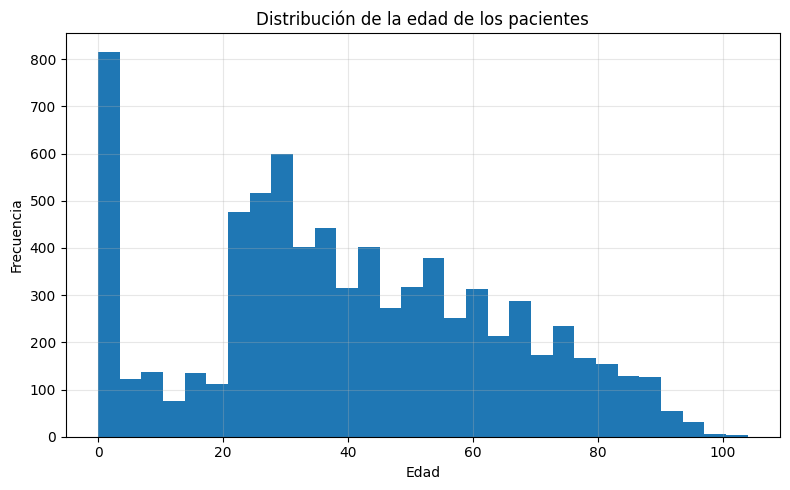

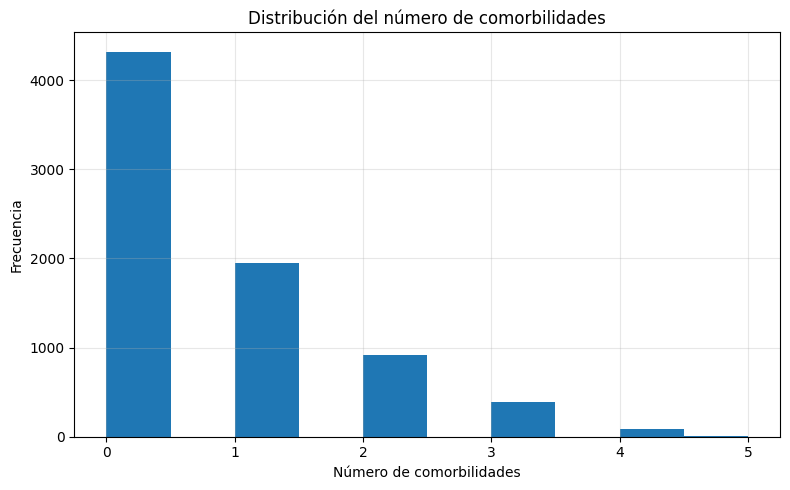

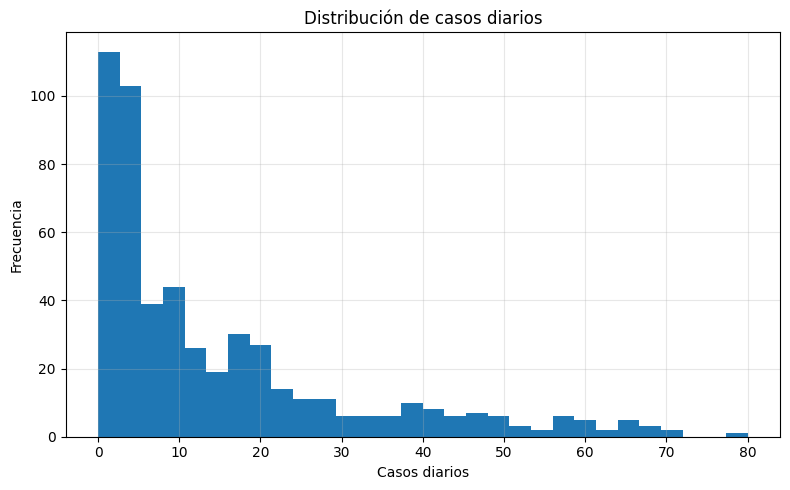

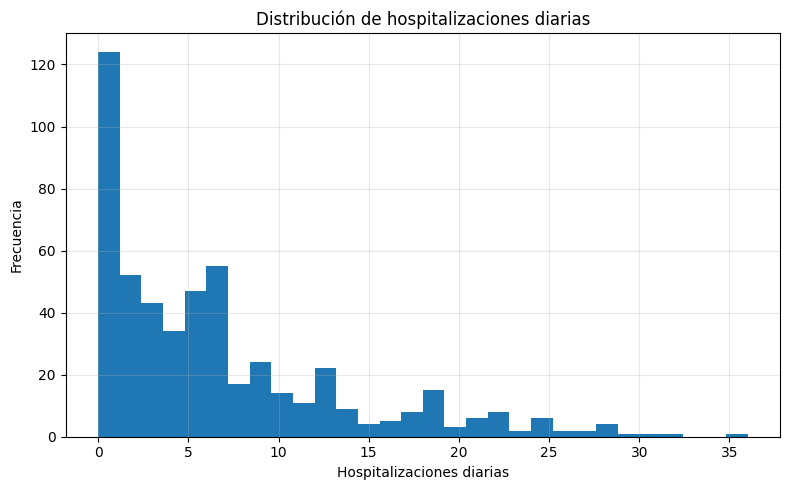

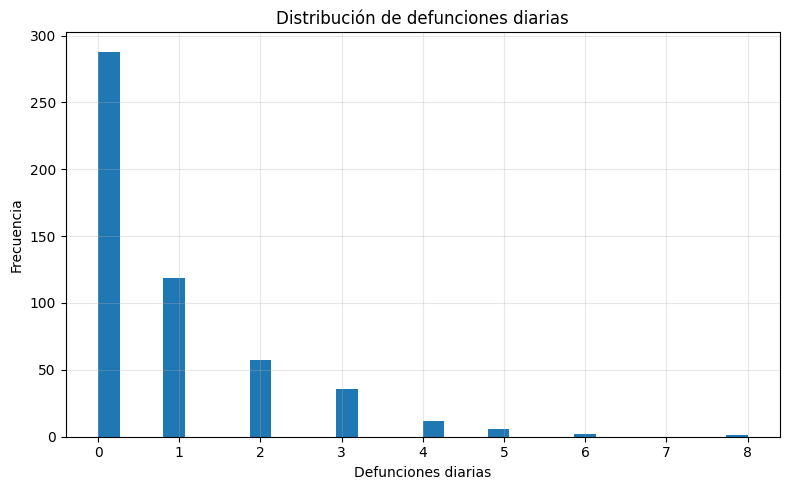

In [4]:
# ------------------------------------------------------------
# 9. Construcción de series temporales
# ------------------------------------------------------------

# Casos diarios
casos_diarios = (
    df_covid
    .dropna(subset=["fecha_caso"])
    .groupby("fecha_caso")
    .size()
    .rename("casos_diarios")
)

# Hospitalizaciones diarias
if "hospitalizado" in df_covid.columns:
    hospitalizaciones_diarias = (
        df_covid[df_covid["hospitalizado"] == 1]
        .dropna(subset=["fecha_caso"])
        .groupby("fecha_caso")
        .size()
        .rename("hospitalizaciones_diarias")
    )
else:
    hospitalizaciones_diarias = pd.Series(dtype="float64", name="hospitalizaciones_diarias")

# Defunciones diarias
if "fecha_def" in df_covid.columns:
    defunciones_diarias = (
        df_covid[df_covid["defuncion"] == 1]
        .dropna(subset=["fecha_def"])
        .groupby("fecha_def")
        .size()
        .rename("defunciones_diarias")
    )
else:
    defunciones_diarias = pd.Series(dtype="float64", name="defunciones_diarias")

# Unir series
fecha_min = min(
    casos_diarios.index.min(),
    hospitalizaciones_diarias.index.min() if len(hospitalizaciones_diarias) > 0 else casos_diarios.index.min(),
    defunciones_diarias.index.min() if len(defunciones_diarias) > 0 else casos_diarios.index.min()
)

fecha_max = max(
    casos_diarios.index.max(),
    hospitalizaciones_diarias.index.max() if len(hospitalizaciones_diarias) > 0 else casos_diarios.index.max(),
    defunciones_diarias.index.max() if len(defunciones_diarias) > 0 else casos_diarios.index.max()
)

fechas = pd.date_range(start=fecha_min, end=fecha_max, freq="D")

df_ts = pd.DataFrame(index=fechas)
df_ts = df_ts.join(casos_diarios)
df_ts = df_ts.join(hospitalizaciones_diarias)
df_ts = df_ts.join(defunciones_diarias)

df_ts = df_ts.fillna(0).reset_index().rename(columns={"index": "fecha"})

print("Serie temporal construida")
display(df_ts.head())

print("Últimos registros")
display(df_ts.tail())


# ------------------------------------------------------------
# 10. Estadística descriptiva de series temporales
# ------------------------------------------------------------

variables_temporales = [
    "casos_diarios",
    "hospitalizaciones_diarias",
    "defunciones_diarias"
]

resumen_temporal = resumen_descriptivo(df_ts, variables_temporales)

print("Resumen descriptivo de series temporales")
display(resumen_temporal)


# ------------------------------------------------------------
# 11. Histogramas obligatorios
# ------------------------------------------------------------

def guardar_histograma(data, variable, titulo, xlabel, bins=30):
    plt.figure(figsize=(8, 5))
    plt.hist(data[variable].dropna(), bins=bins)
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"histograma_{variable}.png", dpi=300)
    plt.show()


# Histograma 1: Edad
guardar_histograma(
    df_covid,
    "edad",
    "Distribución de la edad de los pacientes",
    "Edad",
    bins=30
)

# Histograma 2: Número de comorbilidades
guardar_histograma(
    df_covid,
    "num_comorbilidades",
    "Distribución del número de comorbilidades",
    "Número de comorbilidades",
    bins=10
)

# Histograma 3: Casos diarios
guardar_histograma(
    df_ts,
    "casos_diarios",
    "Distribución de casos diarios",
    "Casos diarios",
    bins=30
)

# Histograma 4: Hospitalizaciones diarias
guardar_histograma(
    df_ts,
    "hospitalizaciones_diarias",
    "Distribución de hospitalizaciones diarias",
    "Hospitalizaciones diarias",
    bins=30
)

# Histograma 5: Defunciones diarias
guardar_histograma(
    df_ts,
    "defunciones_diarias",
    "Distribución de defunciones diarias",
    "Defunciones diarias",
    bins=30
)

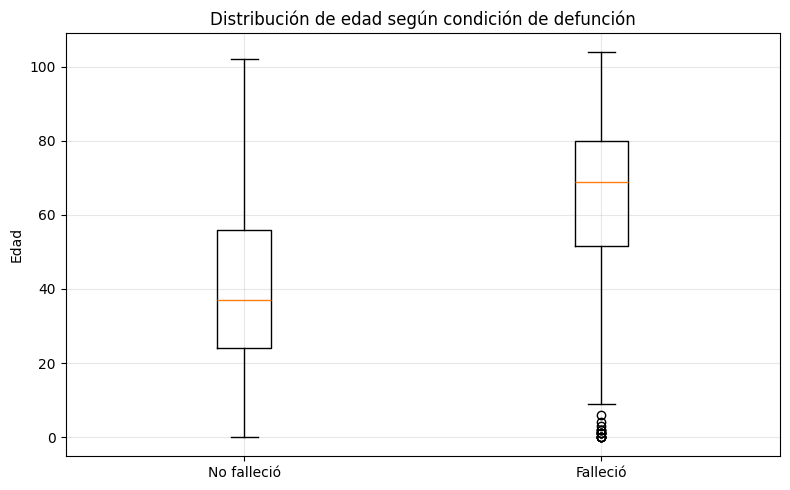

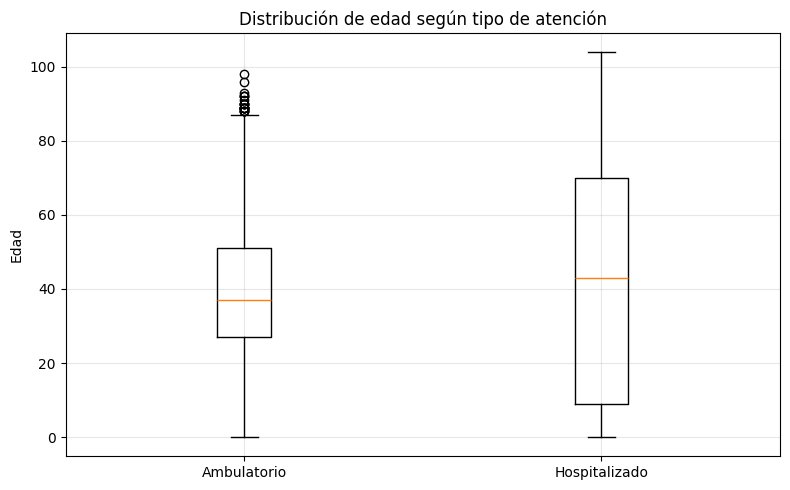

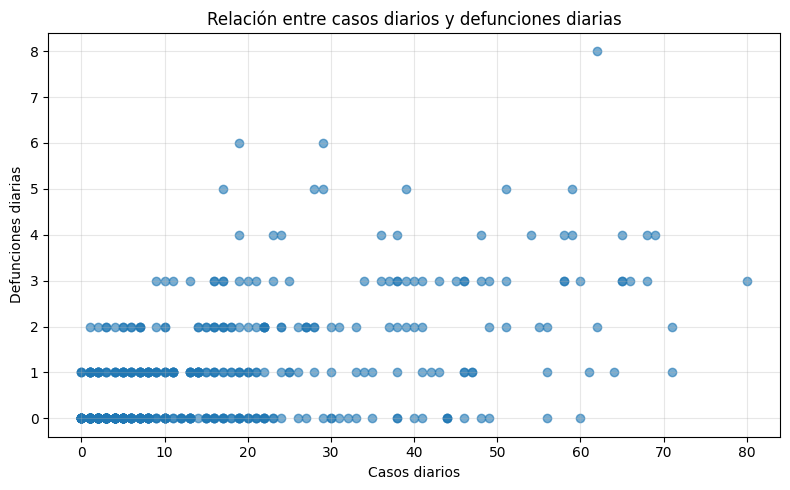

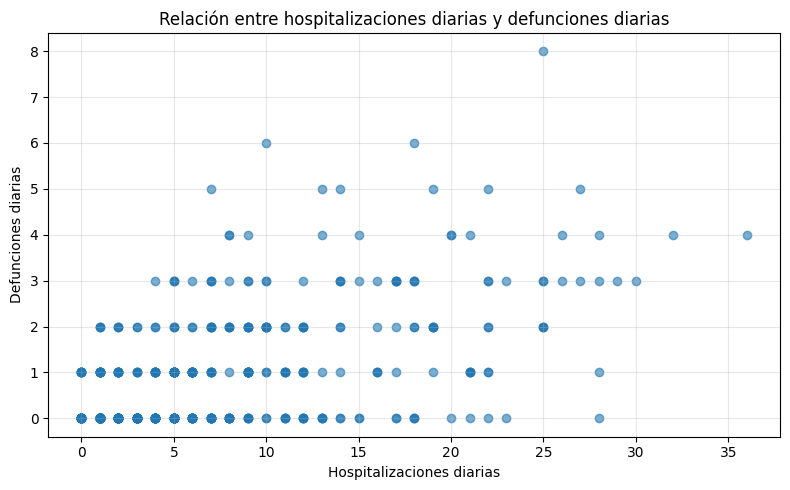

Matriz de correlación


,edad,sexo_masculino,diabetes,hipertension,obesidad,neumonia,inmunosupresion,num_comorbilidades,hospitalizado,defuncion
edad,1.000000,-0.039429,0.390982,0.475370,0.129638,0.068003,0.024483,0.416350,0.046198,0.232717
sexo_masculino,-0.039429,1.000000,0.012493,0.014498,-0.040574,0.097338,0.023814,0.047905,0.149668,0.067162
diabetes,0.390982,0.012493,1.000000,0.473966,0.157113,0.141228,0.018219,0.685224,0.182721,0.168526
hipertension,0.475370,0.014498,0.473966,1.000000,0.221823,0.142531,0.011936,0.721274,0.157721,0.167786
obesidad,0.129638,-0.040574,0.157113,0.221823,1.000000,0.021871,0.016384,0.441431,0.028572,0.037764
neumonia,0.068003,0.097338,0.141228,0.142531,0.021871,1.000000,0.074910,0.576675,0.530366,0.253299
inmunosupresion,0.024483,0.023814,0.018219,0.011936,0.016384,0.074910,1.000000,0.281163,0.107694,0.027693
num_comorbilidades,0.416350,0.047905,0.685224,0.721274,0.441431,0.576675,0.281163,1.000000,0.400966,0.261547
hospitalizado,0.046198,0.149668,0.182721,0.157721,0.028572,0.530366,0.107694,0.400966,1.000000,0.259594
defuncion,0.232717,0.067162,0.168526,0.167786,0.037764,0.253299,0.027693,0.261547,0.259594,1.000000


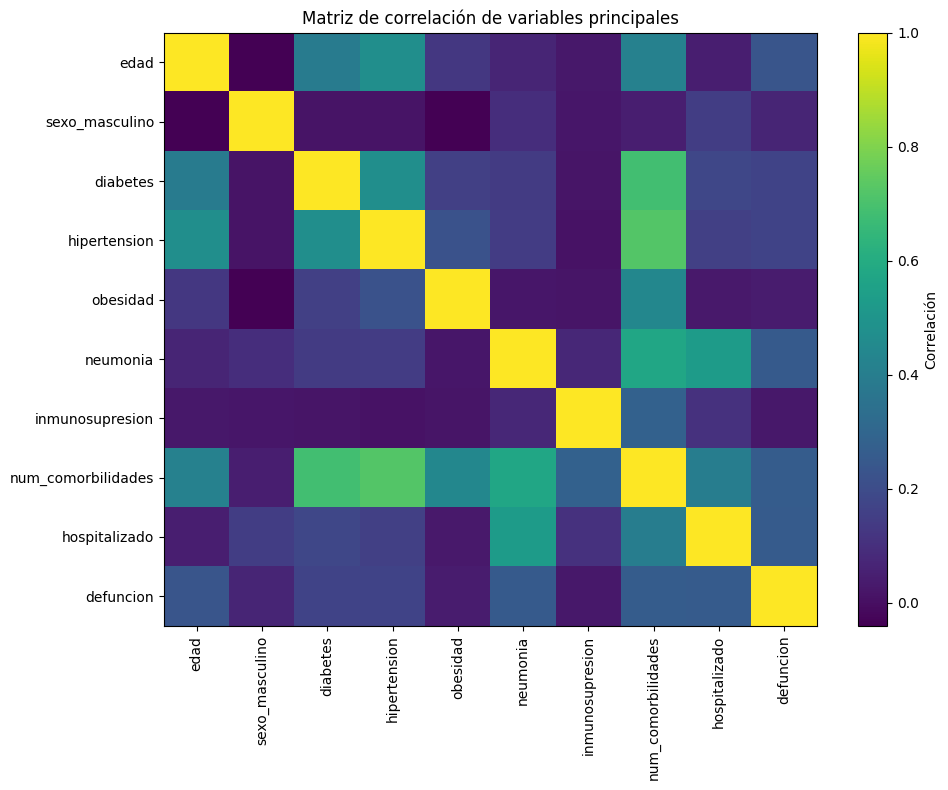

Tablas guardadas en: resultados_etapa_1\tablas_estadistica_descriptiva.xlsx
Gráficas guardadas en la carpeta: resultados_etapa_1


In [5]:
# ------------------------------------------------------------
# 12. Diagramas de caja obligatorios
# ------------------------------------------------------------

def boxplot_por_grupo(df_base, variable_numerica, variable_grupo, titulo, etiquetas):
    data_plot = df_base[[variable_numerica, variable_grupo]].dropna()
    
    grupos = [
        data_plot[data_plot[variable_grupo] == 0][variable_numerica],
        data_plot[data_plot[variable_grupo] == 1][variable_numerica]
    ]
    
    plt.figure(figsize=(8, 5))
    plt.boxplot(grupos, labels=etiquetas)
    plt.title(titulo)
    plt.ylabel(variable_numerica.capitalize())
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"boxplot_{variable_numerica}_por_{variable_grupo}.png", dpi=300)
    plt.show()


# Boxplot 1: Edad por defunción
boxplot_por_grupo(
    df_covid,
    "edad",
    "defuncion",
    "Distribución de edad según condición de defunción",
    ["No falleció", "Falleció"]
)

# Boxplot 2: Edad por hospitalización
boxplot_por_grupo(
    df_covid,
    "edad",
    "hospitalizado",
    "Distribución de edad según tipo de atención",
    ["Ambulatorio", "Hospitalizado"]
)


# ------------------------------------------------------------
# 13. Diagramas de dispersión obligatorios
# ------------------------------------------------------------

def guardar_dispersion(df_base, x, y, titulo, xlabel, ylabel):
    plt.figure(figsize=(8, 5))
    plt.scatter(df_base[x], df_base[y], alpha=0.6)
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"dispersion_{x}_vs_{y}.png", dpi=300)
    plt.show()


# Dispersión 1: Casos diarios vs defunciones diarias
guardar_dispersion(
    df_ts,
    "casos_diarios",
    "defunciones_diarias",
    "Relación entre casos diarios y defunciones diarias",
    "Casos diarios",
    "Defunciones diarias"
)

# Dispersión 2: Hospitalizaciones diarias vs defunciones diarias
guardar_dispersion(
    df_ts,
    "hospitalizaciones_diarias",
    "defunciones_diarias",
    "Relación entre hospitalizaciones diarias y defunciones diarias",
    "Hospitalizaciones diarias",
    "Defunciones diarias"
)


# ------------------------------------------------------------
# 14. Matriz de correlación
# ------------------------------------------------------------

variables_correlacion = [
    "edad",
    "sexo_masculino",
    "diabetes",
    "hipertension",
    "obesidad",
    "neumonia",
    "inmunosupresion",
    "num_comorbilidades",
    "hospitalizado",
    "defuncion"
]

variables_correlacion = [v for v in variables_correlacion if v in df_covid.columns]

matriz_corr = df_covid[variables_correlacion].corr()

print("Matriz de correlación")
display(matriz_corr)

plt.figure(figsize=(10, 8))
plt.imshow(matriz_corr, aspect="auto")
plt.colorbar(label="Correlación")
plt.xticks(range(len(matriz_corr.columns)), matriz_corr.columns, rotation=90)
plt.yticks(range(len(matriz_corr.index)), matriz_corr.index)
plt.title("Matriz de correlación de variables principales")
plt.tight_layout()
plt.savefig(OUT_DIR / "matriz_correlacion.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# 15. Guardar tablas de resultados
# ------------------------------------------------------------

ruta_excel = OUT_DIR / "tablas_estadistica_descriptiva.xlsx"

with pd.ExcelWriter(ruta_excel, engine="openpyxl") as writer:
    resumen_individual.to_excel(writer, sheet_name="resumen_individual", index=False)
    tabla_dummies.to_excel(writer, sheet_name="variables_dummy", index=False)
    resumen_temporal.to_excel(writer, sheet_name="resumen_temporal", index=False)
    matriz_corr.to_excel(writer, sheet_name="matriz_correlacion")
    df_ts.to_excel(writer, sheet_name="series_temporales", index=False)

print(f"Tablas guardadas en: {ruta_excel}")
print(f"Gráficas guardadas en la carpeta: {OUT_DIR}")

## **ETAPA 2. REGRESIÓN LINEAL SIMPLE**

In [6]:
# ============================================================
# ETAPA 2. REGRESIÓN LINEAL SIMPLE
# Modelo: Defunciones diarias en función de hospitalizaciones diarias
# ============================================================

import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

# Carpeta de salida para esta etapa
OUT_DIR_2 = Path("resultados_etapa_2")
OUT_DIR_2.mkdir(exist_ok=True)

# ------------------------------------------------------------
# 1. Preparar datos del modelo
# ------------------------------------------------------------

df_rls = df_ts[["defunciones_diarias", "hospitalizaciones_diarias"]].dropna().copy()

df_rls["defunciones_diarias"] = pd.to_numeric(df_rls["defunciones_diarias"], errors="coerce")
df_rls["hospitalizaciones_diarias"] = pd.to_numeric(df_rls["hospitalizaciones_diarias"], errors="coerce")

df_rls = df_rls.dropna()

print("Observaciones utilizadas en el modelo:", len(df_rls))
display(df_rls.head())


# ------------------------------------------------------------
# 2. Estimar regresión lineal simple
# ------------------------------------------------------------

Y = df_rls["defunciones_diarias"]
X = df_rls[["hospitalizaciones_diarias"]]
X = sm.add_constant(X)

modelo_rls = sm.OLS(Y, X).fit()

print(modelo_rls.summary())


# ------------------------------------------------------------
# 3. Tabla ordenada de resultados
# ------------------------------------------------------------

tabla_rls = pd.DataFrame({
    "coeficiente": modelo_rls.params,
    "error_estandar": modelo_rls.bse,
    "t": modelo_rls.tvalues,
    "p_valor": modelo_rls.pvalues,
    "IC_95_inf": modelo_rls.conf_int()[0],
    "IC_95_sup": modelo_rls.conf_int()[1]
})

display(tabla_rls)

print("R cuadrada:", modelo_rls.rsquared)
print("R cuadrada ajustada:", modelo_rls.rsquared_adj)


# ------------------------------------------------------------
# 5. Guardar resultados de la regresión lineal simple
# ------------------------------------------------------------

# La carpeta OUT_DIR_2 ya fue creada al inicio de la etapa.

# ------------------------------------------------------------
# 6.1. Crear tabla de métricas generales del modelo
# ------------------------------------------------------------

metricas_rls = pd.DataFrame({
    "indicador": [
        "Variable dependiente",
        "Variable explicativa",
        "Número de observaciones",
        "R cuadrada",
        "R cuadrada ajustada",
        "Estadístico F",
        "P-valor F",
        "AIC",
        "BIC"
    ],
    "valor": [
        "defunciones_diarias",
        "hospitalizaciones_diarias",
        int(modelo_rls.nobs),
        modelo_rls.rsquared,
        modelo_rls.rsquared_adj,
        modelo_rls.fvalue,
        modelo_rls.f_pvalue,
        modelo_rls.aic,
        modelo_rls.bic
    ]
})

display(metricas_rls)


# ------------------------------------------------------------
# 6.2. Crear tabla con predicciones y residuos
# ------------------------------------------------------------

df_resultados_rls = df_rls.copy()

df_resultados_rls["defunciones_predichas"] = modelo_rls.fittedvalues
df_resultados_rls["residuos"] = modelo_rls.resid

display(df_resultados_rls.head())


# ------------------------------------------------------------
# 6.3. Guardar tablas en Excel
# ------------------------------------------------------------

ruta_excel_rls = OUT_DIR_2 / "resultados_regresion_lineal_simple.xlsx"

with pd.ExcelWriter(ruta_excel_rls, engine="openpyxl") as writer:
    tabla_rls.to_excel(writer, sheet_name="coeficientes")
    metricas_rls.to_excel(writer, sheet_name="metricas_modelo", index=False)
    df_resultados_rls.to_excel(writer, sheet_name="predicciones_residuos", index=False)
    df_rls.to_excel(writer, sheet_name="datos_modelo", index=False)

print(f"Archivo Excel guardado en: {ruta_excel_rls}")


# ------------------------------------------------------------
# 6.4. Guardar resumen completo del modelo en TXT
# ------------------------------------------------------------

ruta_txt_rls = OUT_DIR_2 / "summary_regresion_lineal_simple.txt"

with open(ruta_txt_rls, "w", encoding="utf-8") as f:
    f.write(str(modelo_rls.summary()))

print(f"Resumen del modelo guardado en: {ruta_txt_rls}")

Observaciones utilizadas en el modelo: 521


,defunciones_diarias,hospitalizaciones_diarias
0,0.0,5.0
1,0.0,2.0
2,0.0,3.0
3,0.0,5.0
4,0.0,3.0


                             OLS Regression Results                            
Dep. Variable:     defunciones_diarias   R-squared:                       0.343
Model:                             OLS   Adj. R-squared:                  0.341
Method:                  Least Squares   F-statistic:                     270.5
Date:                 Wed, 17 Jun 2026   Prob (F-statistic):           3.15e-49
Time:                         22:31:41   Log-Likelihood:                -734.81
No. Observations:                  521   AIC:                             1474.
Df Residuals:                      519   BIC:                             1482.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup
const,0.135117,0.061193,2.208047,2.767748e-02,0.014901,0.255333
hospitalizaciones_diarias,0.105195,0.006396,16.446768,3.153216e-49,0.092630,0.117761


R cuadrada: 0.34261872454770503
R cuadrada ajustada: 0.341352093959165


,indicador,valor
0,Variable dependiente,defunciones_diarias
1,Variable explicativa,hospitalizaciones_diarias
2,Número de observaciones,521
3,R cuadrada,0.342619
4,R cuadrada ajustada,0.341352
5,Estadístico F,270.496171
6,P-valor F,0.0
7,AIC,1473.619969
8,BIC,1482.131469


,defunciones_diarias,hospitalizaciones_diarias,defunciones_predichas,residuos
0,0.0,5.0,0.661093,-0.661093
1,0.0,2.0,0.345507,-0.345507
2,0.0,3.0,0.450703,-0.450703
3,0.0,5.0,0.661093,-0.661093
4,0.0,3.0,0.450703,-0.450703


Archivo Excel guardado en: resultados_etapa_2\resultados_regresion_lineal_simple.xlsx
Resumen del modelo guardado en: resultados_etapa_2\summary_regresion_lineal_simple.txt


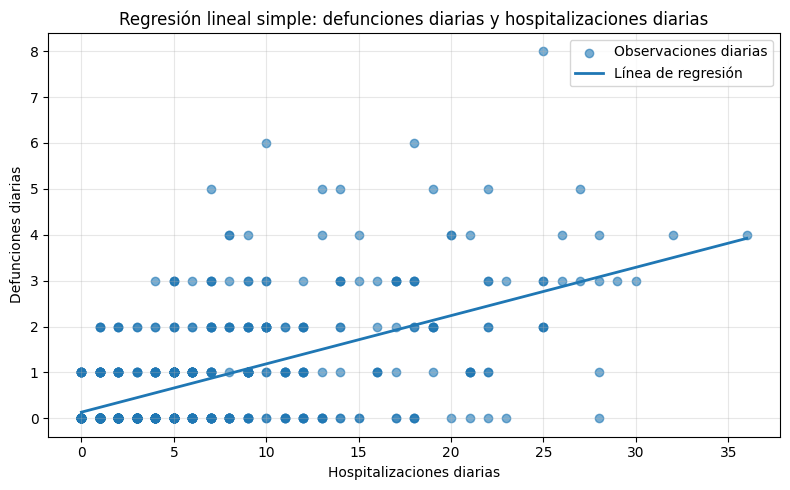

Gráfica guardada en: resultados_etapa_2\regresion_simple_defunciones_hospitalizaciones.png
Resumen para el reporte
---------------------------------------------
Coeficiente de hospitalizaciones diarias: 0.105195
P-valor: 0.000000
Intervalo de confianza 95%: [0.092630, 0.117761]
R cuadrada: 0.342619

Lectura técnica:
El coeficiente es estadísticamente significativo al 5%. Por cada hospitalización diaria adicional, las defunciones diarias cambian en promedio 0.1052 unidades.


In [7]:
# ------------------------------------------------------------
# 6.5. Guardar gráfica de regresión
# ------------------------------------------------------------

ruta_grafica_rls = OUT_DIR_2 / "regresion_simple_defunciones_hospitalizaciones.png"

plt.figure(figsize=(8, 5))

plt.scatter(
    df_rls["hospitalizaciones_diarias"],
    df_rls["defunciones_diarias"],
    alpha=0.6,
    label="Observaciones diarias"
)

x_grid = np.linspace(
    df_rls["hospitalizaciones_diarias"].min(),
    df_rls["hospitalizaciones_diarias"].max(),
    100
)

X_grid = sm.add_constant(pd.DataFrame({"hospitalizaciones_diarias": x_grid}))
predicciones = modelo_rls.predict(X_grid)

plt.plot(x_grid, predicciones, linewidth=2, label="Línea de regresión")

plt.title("Regresión lineal simple: defunciones diarias y hospitalizaciones diarias")
plt.xlabel("Hospitalizaciones diarias")
plt.ylabel("Defunciones diarias")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(ruta_grafica_rls, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_grafica_rls}")


# ------------------------------------------------------------
# 6.6. Resumen para interpretar en el reporte
# ------------------------------------------------------------

coef_hosp = modelo_rls.params["hospitalizaciones_diarias"]
p_hosp = modelo_rls.pvalues["hospitalizaciones_diarias"]
ic_inf = modelo_rls.conf_int().loc["hospitalizaciones_diarias", 0]
ic_sup = modelo_rls.conf_int().loc["hospitalizaciones_diarias", 1]
r2 = modelo_rls.rsquared

print("Resumen para el reporte")
print("---------------------------------------------")
print(f"Coeficiente de hospitalizaciones diarias: {coef_hosp:.6f}")
print(f"P-valor: {p_hosp:.6f}")
print(f"Intervalo de confianza 95%: [{ic_inf:.6f}, {ic_sup:.6f}]")
print(f"R cuadrada: {r2:.6f}")

if p_hosp < 0.05:
    print("\nLectura técnica:")
    print(
        f"El coeficiente es estadísticamente significativo al 5%. "
        f"Por cada hospitalización diaria adicional, las defunciones diarias "
        f"cambian en promedio {coef_hosp:.4f} unidades."
    )
else:
    print("\nLectura técnica:")
    print(
        f"El coeficiente no es estadísticamente significativo al 5%. "
        f"No se cuenta con evidencia suficiente para afirmar que las hospitalizaciones "
        f"diarias explican las defunciones diarias en este modelo simple."
    )

## **ETAPA 3. REGRESIÓN LINEAL MÚLTIPLE**

In [8]:
# ============================================================
# ETAPA 3. REGRESIÓN LINEAL MÚLTIPLE
# Modelo: Defunciones diarias en función de hospitalizaciones
# y casos diarios
# ============================================================

import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

# Carpeta de salida para esta etapa
OUT_DIR_3 = Path("resultados_etapa_3")
OUT_DIR_3.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 1. Preparar datos del modelo
# ------------------------------------------------------------

variables_rlm = [
    "defunciones_diarias",
    "hospitalizaciones_diarias",
    "casos_diarios"
]

df_rlm = df_ts[variables_rlm].copy()

for col in variables_rlm:
    df_rlm[col] = pd.to_numeric(df_rlm[col], errors="coerce")

df_rlm = df_rlm.dropna()

print("Observaciones utilizadas en el modelo:", len(df_rlm))
display(df_rlm.head())


# ------------------------------------------------------------
# 2. Estimar regresión lineal múltiple
# ------------------------------------------------------------

Y = df_rlm["defunciones_diarias"]

X = df_rlm[[
    "hospitalizaciones_diarias",
    "casos_diarios"
]]

X = sm.add_constant(X)

modelo_rlm = sm.OLS(Y, X).fit()

print(modelo_rlm.summary())


# ------------------------------------------------------------
# 3. Tabla ordenada de coeficientes
# ------------------------------------------------------------

tabla_rlm = pd.DataFrame({
    "coeficiente": modelo_rlm.params,
    "error_estandar": modelo_rlm.bse,
    "t": modelo_rlm.tvalues,
    "p_valor": modelo_rlm.pvalues,
    "IC_95_inf": modelo_rlm.conf_int()[0],
    "IC_95_sup": modelo_rlm.conf_int()[1]
})

print("Resultados de la regresión lineal múltiple")
display(tabla_rlm)


# ------------------------------------------------------------
# 4. Métricas generales del modelo
# ------------------------------------------------------------

metricas_rlm = pd.DataFrame({
    "indicador": [
        "Variable dependiente",
        "Variables explicativas",
        "Número de observaciones",
        "R cuadrada",
        "R cuadrada ajustada",
        "Estadístico F",
        "P-valor F",
        "AIC",
        "BIC"
    ],
    "valor": [
        "defunciones_diarias",
        "hospitalizaciones_diarias, casos_diarios",
        int(modelo_rlm.nobs),
        modelo_rlm.rsquared,
        modelo_rlm.rsquared_adj,
        modelo_rlm.fvalue,
        modelo_rlm.f_pvalue,
        modelo_rlm.aic,
        modelo_rlm.bic
    ]
})

print("Métricas generales del modelo")
display(metricas_rlm)


# ------------------------------------------------------------
# 5. Predicciones y residuos
# ------------------------------------------------------------

df_resultados_rlm = df_rlm.copy()
df_resultados_rlm["defunciones_predichas"] = modelo_rlm.fittedvalues
df_resultados_rlm["residuos"] = modelo_rlm.resid

display(df_resultados_rlm.head())


# ------------------------------------------------------------
# 6. Signos esperados y resultados observados
# ------------------------------------------------------------

signos_esperados = pd.DataFrame({
    "variable": [
        "hospitalizaciones_diarias",
        "casos_diarios"
    ],
    "signo_esperado": [
        "Positivo",
        "Positivo"
    ],
    "justificacion": [
        "Un mayor número de hospitalizaciones refleja mayor gravedad clínica y presión hospitalaria, por lo que se espera una asociación positiva con las defunciones.",
        "Un mayor número de casos confirmados puede anticipar o coincidir con mayor mortalidad, aunque su efecto puede observarse con rezago temporal."
    ],
    "coeficiente_estimado": [
        modelo_rlm.params.get("hospitalizaciones_diarias", np.nan),
        modelo_rlm.params.get("casos_diarios", np.nan)
    ],
    "signo_observado": [
        "Positivo" if modelo_rlm.params.get("hospitalizaciones_diarias", np.nan) > 0 else "Negativo",
        "Positivo" if modelo_rlm.params.get("casos_diarios", np.nan) > 0 else "Negativo"
    ],
    "p_valor": [
        modelo_rlm.pvalues.get("hospitalizaciones_diarias", np.nan),
        modelo_rlm.pvalues.get("casos_diarios", np.nan)
    ]
})

display(signos_esperados)

Observaciones utilizadas en el modelo: 521


,defunciones_diarias,hospitalizaciones_diarias,casos_diarios
0,0.0,5.0,7.0
1,0.0,2.0,2.0
2,0.0,3.0,7.0
3,0.0,5.0,7.0
4,0.0,3.0,8.0


                             OLS Regression Results                            
Dep. Variable:     defunciones_diarias   R-squared:                       0.350
Model:                             OLS   Adj. R-squared:                  0.347
Method:                  Least Squares   F-statistic:                     139.2
Date:                 Wed, 17 Jun 2026   Prob (F-statistic):           4.11e-49
Time:                         22:31:42   Log-Likelihood:                -732.03
No. Observations:                  521   AIC:                             1470.
Df Residuals:                      518   BIC:                             1483.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup
const,0.149019,0.061211,2.434517,0.015248,0.028767,0.269270
hospitalizaciones_diarias,0.061698,0.019519,3.160906,0.001665,0.023352,0.100044
casos_diarios,0.018937,0.008033,2.357470,0.018771,0.003156,0.034718


Métricas generales del modelo


,indicador,valor
0,Variable dependiente,defunciones_diarias
1,Variables explicativas,"hospitalizaciones_diarias, casos_diarios"
2,Número de observaciones,521
3,R cuadrada,0.349597
4,R cuadrada ajustada,0.347086
5,Estadístico F,139.214615
6,P-valor F,0.0
7,AIC,1470.059893
8,BIC,1482.827143


,defunciones_diarias,hospitalizaciones_diarias,casos_diarios,defunciones_predichas,residuos
0,0.0,5.0,7.0,0.590067,-0.590067
1,0.0,2.0,2.0,0.310288,-0.310288
2,0.0,3.0,7.0,0.466672,-0.466672
3,0.0,5.0,7.0,0.590067,-0.590067
4,0.0,3.0,8.0,0.485609,-0.485609


,variable,signo_esperado,justificacion,coeficiente_estimado,signo_observado,p_valor
0,hospitalizaciones_diarias,Positivo,Un mayor número de hospitalizaciones refleja m...,0.061698,Positivo,0.001665
1,casos_diarios,Positivo,Un mayor número de casos confirmados puede ant...,0.018937,Positivo,0.018771


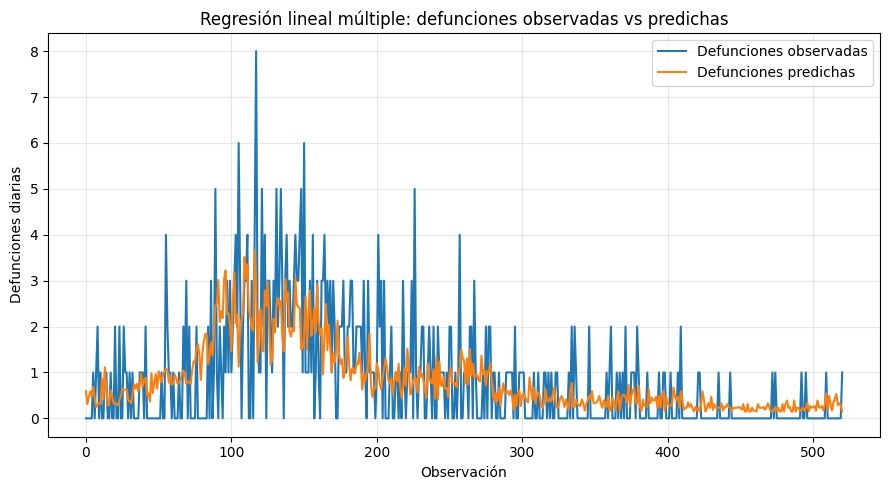

Gráfica guardada en: resultados_etapa_3\rlm_defunciones_observadas_vs_predichas.png


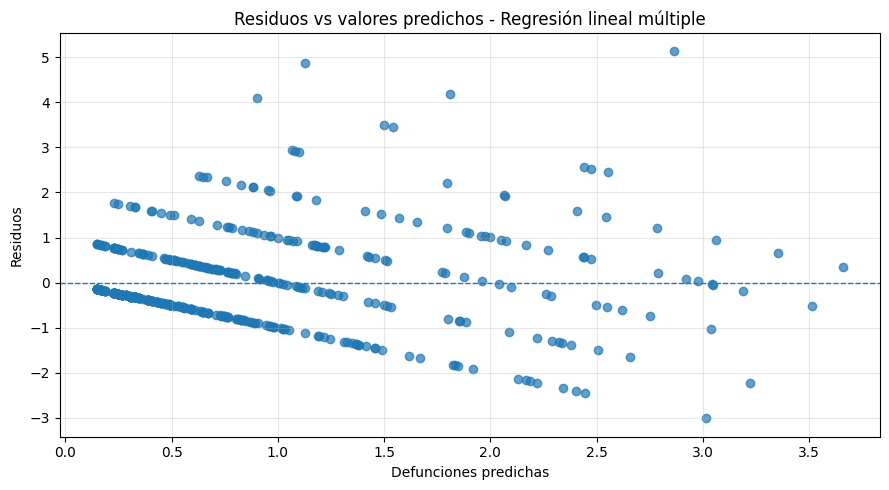

Gráfica guardada en: resultados_etapa_3\rlm_residuos_vs_predichos.png
Archivo Excel guardado en: resultados_etapa_3\resultados_regresion_lineal_multiple.xlsx
Resumen del modelo guardado en: resultados_etapa_3\summary_regresion_lineal_multiple.txt
Resumen para el reporte
---------------------------------------------

Variable: hospitalizaciones_diarias
Coeficiente: 0.061698
P-valor: 0.001665
Intervalo de confianza 95%: [0.023352, 0.100044]
Lectura técnica: estadísticamente significativa al 5%.

Variable: casos_diarios
Coeficiente: 0.018937
P-valor: 0.018771
Intervalo de confianza 95%: [0.003156, 0.034718]
Lectura técnica: estadísticamente significativa al 5%.

Bondad de ajuste
R cuadrada: 0.349597
R cuadrada ajustada: 0.347086
Estadístico F: 139.214615
P-valor F: 0.000000
El modelo es globalmente significativo al 5%.


In [9]:
# ------------------------------------------------------------
# 7. Gráfica: defunciones reales vs predichas
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    df_resultados_rlm.index,
    df_resultados_rlm["defunciones_diarias"],
    label="Defunciones observadas"
)

plt.plot(
    df_resultados_rlm.index,
    df_resultados_rlm["defunciones_predichas"],
    label="Defunciones predichas"
)

plt.title("Regresión lineal múltiple: defunciones observadas vs predichas")
plt.xlabel("Observación")
plt.ylabel("Defunciones diarias")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

ruta_grafica_pred = OUT_DIR_3 / "rlm_defunciones_observadas_vs_predichas.png"
plt.savefig(ruta_grafica_pred, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_grafica_pred}")


# ------------------------------------------------------------
# 8. Gráfica de residuos
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.scatter(
    df_resultados_rlm["defunciones_predichas"],
    df_resultados_rlm["residuos"],
    alpha=0.7
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Residuos vs valores predichos - Regresión lineal múltiple")
plt.xlabel("Defunciones predichas")
plt.ylabel("Residuos")
plt.grid(alpha=0.3)
plt.tight_layout()

ruta_grafica_residuos = OUT_DIR_3 / "rlm_residuos_vs_predichos.png"
plt.savefig(ruta_grafica_residuos, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_grafica_residuos}")


# ------------------------------------------------------------
# 9. Guardar resultados en Excel y TXT
# ------------------------------------------------------------

ruta_excel_rlm = OUT_DIR_3 / "resultados_regresion_lineal_multiple.xlsx"

with pd.ExcelWriter(ruta_excel_rlm, engine="openpyxl") as writer:
    tabla_rlm.to_excel(writer, sheet_name="coeficientes")
    metricas_rlm.to_excel(writer, sheet_name="metricas_modelo", index=False)
    signos_esperados.to_excel(writer, sheet_name="signos_esperados", index=False)
    df_resultados_rlm.to_excel(writer, sheet_name="predicciones_residuos", index=False)
    df_rlm.to_excel(writer, sheet_name="datos_modelo", index=False)

print(f"Archivo Excel guardado en: {ruta_excel_rlm}")


ruta_txt_rlm = OUT_DIR_3 / "summary_regresion_lineal_multiple.txt"

with open(ruta_txt_rlm, "w", encoding="utf-8") as f:
    f.write(str(modelo_rlm.summary()))

print(f"Resumen del modelo guardado en: {ruta_txt_rlm}")


# ------------------------------------------------------------
# 10. Síntesis de resultados para el reporte
# ------------------------------------------------------------

print("Resumen para el reporte")
print("---------------------------------------------")

for var in ["hospitalizaciones_diarias", "casos_diarios"]:
    coef = modelo_rlm.params[var]
    pvalor = modelo_rlm.pvalues[var]
    ic_inf = modelo_rlm.conf_int().loc[var, 0]
    ic_sup = modelo_rlm.conf_int().loc[var, 1]
    
    print(f"\nVariable: {var}")
    print(f"Coeficiente: {coef:.6f}")
    print(f"P-valor: {pvalor:.6f}")
    print(f"Intervalo de confianza 95%: [{ic_inf:.6f}, {ic_sup:.6f}]")
    
    if pvalor < 0.05:
        print("Lectura técnica: estadísticamente significativa al 5%.")
    else:
        print("Lectura técnica: no estadísticamente significativa al 5%.")

print("\nBondad de ajuste")
print(f"R cuadrada: {modelo_rlm.rsquared:.6f}")
print(f"R cuadrada ajustada: {modelo_rlm.rsquared_adj:.6f}")
print(f"Estadístico F: {modelo_rlm.fvalue:.6f}")
print(f"P-valor F: {modelo_rlm.f_pvalue:.6f}")

if modelo_rlm.f_pvalue < 0.05:
    print("El modelo es globalmente significativo al 5%.")
else:
    print("El modelo no es globalmente significativo al 5%.")

## **ETAPA 4. VARIABLES DUMMY**

In [10]:
# ============================================================
# ETAPA 4. VARIABLES DUMMY
# Proyecto: Modelos Econométricos - COVID-19 en México
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# Carpeta de salida para esta etapa
OUT_DIR_4 = Path("resultados_etapa_4")
OUT_DIR_4.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 1. Preparar base de trabajo
# ------------------------------------------------------------

df_dummy = df_covid.copy()

# Asegurar que edad sea numérica
if "edad" in df_dummy.columns:
    df_dummy["edad"] = pd.to_numeric(df_dummy["edad"], errors="coerce")

# Si alguna dummy no existe, se intenta reconstruir a partir de la variable original

# Sexo: normalmente 1 = Mujer, 2 = Hombre
if "sexo_masculino" not in df_dummy.columns and "sexo" in df_dummy.columns:
    df_dummy["sexo_masculino"] = pd.to_numeric(df_dummy["sexo"], errors="coerce").map({2: 1, 1: 0})

# Hospitalización: normalmente 1 = Ambulatorio, 2 = Hospitalizado
if "hospitalizado" not in df_dummy.columns and "tipo_paciente" in df_dummy.columns:
    df_dummy["hospitalizado"] = pd.to_numeric(df_dummy["tipo_paciente"], errors="coerce").map({2: 1, 1: 0})

# Defunción: si existe fecha de defunción válida, defuncion = 1
if "defuncion" not in df_dummy.columns and "fecha_def" in df_dummy.columns:
    df_dummy["defuncion"] = np.where(df_dummy["fecha_def"].notna(), 1, 0)

# Función para convertir variables Sí/No:
# 1 = Sí, 2 = No, otros valores se toman como NaN
def convertir_si_no(serie):
    serie_num = pd.to_numeric(serie, errors="coerce")
    return serie_num.map({1: 1, 2: 0})

# Variables clínicas
variables_clinicas = ["diabetes", "hipertension", "obesidad", "neumonia", "inmunosupresion"]

# Si inmunosupresión viene como inmusupr, renombrar
if "inmusupr" in df_dummy.columns and "inmunosupresion" not in df_dummy.columns:
    df_dummy = df_dummy.rename(columns={"inmusupr": "inmunosupresion"})

for col in variables_clinicas:
    if col in df_dummy.columns:
        # Si tiene valores distintos de 0/1, se convierte con catálogo 1/2
        valores = set(pd.to_numeric(df_dummy[col], errors="coerce").dropna().unique())
        if not valores.issubset({0, 1}):
            df_dummy[col] = convertir_si_no(df_dummy[col])

# Número de comorbilidades
comorbilidades_base = ["diabetes", "hipertension", "obesidad", "neumonia", "inmunosupresion"]
comorbilidades_existentes = [c for c in comorbilidades_base if c in df_dummy.columns]

df_dummy["num_comorbilidades"] = df_dummy[comorbilidades_existentes].sum(axis=1, skipna=True)

print("Dimensiones de la base para variables dummy:", df_dummy.shape)
display(df_dummy.head())


# ------------------------------------------------------------
# 2. Tabla de variables dummy
# ------------------------------------------------------------

dummies_obligatorias = [
    "sexo_masculino",
    "diabetes",
    "hipertension",
    "obesidad",
    "hospitalizado",
    "defuncion"
]

# Variables extra útiles para el proyecto y el punto 11
dummies_extra = [
    "neumonia",
    "inmunosupresion"
]

dummies_disponibles = [v for v in dummies_obligatorias + dummies_extra if v in df_dummy.columns]

tabla_dummies = []

for var in dummies_disponibles:
    serie = pd.to_numeric(df_dummy[var], errors="coerce")
    
    tabla_dummies.append({
        "variable_dummy": var,
        "categoria_0": int((serie == 0).sum()),
        "categoria_1": int((serie == 1).sum()),
        "valores_perdidos": int(serie.isna().sum()),
        "porcentaje_1": (serie.eq(1).mean() * 100)
    })

tabla_dummies_etapa4 = pd.DataFrame(tabla_dummies)

print("Tabla de distribución de variables dummy")
display(tabla_dummies_etapa4)


# ------------------------------------------------------------
# 3. Modelo A: Hospitalización explicada por dummies clínicas
# ------------------------------------------------------------

variables_modelo_hosp = [
    "sexo_masculino",
    "diabetes",
    "hipertension",
    "obesidad",
    "neumonia",
    "inmunosupresion"
]

variables_modelo_hosp = [v for v in variables_modelo_hosp if v in df_dummy.columns]

df_modelo_hosp = df_dummy[["hospitalizado"] + variables_modelo_hosp].dropna().copy()

Y_hosp = df_modelo_hosp["hospitalizado"]
X_hosp = df_modelo_hosp[variables_modelo_hosp]
X_hosp = sm.add_constant(X_hosp)

modelo_dummy_hosp = sm.OLS(Y_hosp, X_hosp).fit()

print(modelo_dummy_hosp.summary())


# ------------------------------------------------------------
# 4. Tabla de resultados del modelo A
# ------------------------------------------------------------

tabla_dummy_hosp = pd.DataFrame({
    "coeficiente": modelo_dummy_hosp.params,
    "error_estandar": modelo_dummy_hosp.bse,
    "t": modelo_dummy_hosp.tvalues,
    "p_valor": modelo_dummy_hosp.pvalues,
    "IC_95_inf": modelo_dummy_hosp.conf_int()[0],
    "IC_95_sup": modelo_dummy_hosp.conf_int()[1]
})

print("Modelo A: Hospitalización explicada por variables dummy")
display(tabla_dummy_hosp)

Dimensiones de la base para variables dummy: (7666, 24)


,sexo,entidad_res,tipo_paciente,fecha_ingreso,fecha_sintomas,fecha_def,neumonia,edad,diabetes,inmunosupresion,...,clasificacion_final_covid,uci,fecha_caso,sexo_masculino,hospitalizado,defuncion,num_comorbilidades,caso_confirmado,covid_por_clasificacion,covid_por_pcr
104,1,15,1,2025-04-16,2025-04-13,NaT,0,26,0.0,0.0,...,3,NaN,2025-04-13,0,0,0,0.0,True,True,True
244,1,01,2,2025-01-03,2025-01-01,NaT,0,94,0.0,0.0,...,3,0.0,2025-01-01,0,1,0,1.0,True,True,True
380,1,26,2,2025-01-02,2025-01-01,NaT,0,1,0.0,0.0,...,3,0.0,2025-01-01,0,1,0,0.0,True,True,True
431,2,10,2,2025-01-03,2025-01-02,2025-01-06,1,68,NaN,NaN,...,3,0.0,2025-01-02,1,1,1,1.0,True,True,True
439,2,30,2,2025-01-03,2025-01-01,NaT,1,43,0.0,1.0,...,3,0.0,2025-01-01,1,1,0,2.0,True,True,True


Tabla de distribución de variables dummy


,variable_dummy,categoria_0,categoria_1,valores_perdidos,porcentaje_1
0,sexo_masculino,4603,3063,0,39.955648
1,diabetes,6493,1162,11,15.157840
2,hipertension,6192,1463,11,19.084268
3,obesidad,7088,568,10,7.409340
4,hospitalizado,4162,3504,0,45.708322
5,defuncion,7227,439,0,5.726585
6,neumonia,5943,1723,0,22.475867
7,inmunosupresion,7269,389,8,5.074354


                            OLS Regression Results                            
Dep. Variable:          hospitalizado   R-squared:                       0.309
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     569.8
Date:                Wed, 17 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:31:43   Log-Likelihood:                -4108.2
No. Observations:                7648   AIC:                             8230.
Df Residuals:                    7641   BIC:                             8279.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.2472      0.007     

,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup
const,0.247198,0.006953,35.551325,2.524316e-256,0.233568,0.260829
sexo_masculino,0.099764,0.009726,10.257054,1.585781e-24,0.080698,0.118831
diabetes,0.126134,0.015072,8.368689,6.864891e-17,0.096589,0.155680
hipertension,0.053113,0.013939,3.810474,1.397891e-04,0.025789,0.080436
obesidad,-0.007169,0.018597,-0.385494,6.998822e-01,-0.043625,0.029286
neumonia,0.594122,0.011591,51.257102,0.000000e+00,0.571400,0.616843
inmunosupresion,0.149281,0.021680,6.885785,6.202740e-12,0.106783,0.191779


In [11]:
# ------------------------------------------------------------
# 5. Modelo B: Defunción explicada por dummies clínicas y hospitalización
# ------------------------------------------------------------

variables_modelo_def = [
    "sexo_masculino",
    "diabetes",
    "hipertension",
    "obesidad",
    "neumonia",
    "inmunosupresion",
    "hospitalizado"
]

variables_modelo_def = [v for v in variables_modelo_def if v in df_dummy.columns]

df_modelo_def = df_dummy[["defuncion"] + variables_modelo_def].dropna().copy()

Y_def = df_modelo_def["defuncion"]
X_def = df_modelo_def[variables_modelo_def]
X_def = sm.add_constant(X_def)

modelo_dummy_def = sm.OLS(Y_def, X_def).fit()

print(modelo_dummy_def.summary())


# ------------------------------------------------------------
# 6. Tabla de resultados del modelo B
# ------------------------------------------------------------

tabla_dummy_def = pd.DataFrame({
    "coeficiente": modelo_dummy_def.params,
    "error_estandar": modelo_dummy_def.bse,
    "t": modelo_dummy_def.tvalues,
    "p_valor": modelo_dummy_def.pvalues,
    "IC_95_inf": modelo_dummy_def.conf_int()[0],
    "IC_95_sup": modelo_dummy_def.conf_int()[1]
})

print("Modelo B: Defunción explicada por variables dummy")
display(tabla_dummy_def)


# ------------------------------------------------------------
# 7. Métricas generales de ambos modelos
# ------------------------------------------------------------

metricas_dummy = pd.DataFrame({
    "modelo": [
        "Modelo A: Hospitalización",
        "Modelo B: Defunción"
    ],
    "variable_dependiente": [
        "hospitalizado",
        "defuncion"
    ],
    "observaciones": [
        int(modelo_dummy_hosp.nobs),
        int(modelo_dummy_def.nobs)
    ],
    "r_cuadrada": [
        modelo_dummy_hosp.rsquared,
        modelo_dummy_def.rsquared
    ],
    "r_cuadrada_ajustada": [
        modelo_dummy_hosp.rsquared_adj,
        modelo_dummy_def.rsquared_adj
    ],
    "estadistico_f": [
        modelo_dummy_hosp.fvalue,
        modelo_dummy_def.fvalue
    ],
    "p_valor_f": [
        modelo_dummy_hosp.f_pvalue,
        modelo_dummy_def.f_pvalue
    ],
    "aic": [
        modelo_dummy_hosp.aic,
        modelo_dummy_def.aic
    ],
    "bic": [
        modelo_dummy_hosp.bic,
        modelo_dummy_def.bic
    ]
})

display(metricas_dummy)


# ------------------------------------------------------------
# 8. Síntesis técnica de coeficientes
# ------------------------------------------------------------

def construir_sintesis_coeficientes_dummy(tabla, nombre_modelo):
    sintesis = []
    
    for var in tabla.index:
        if var == "const":
            continue
        
        coef = tabla.loc[var, "coeficiente"]
        pvalor = tabla.loc[var, "p_valor"]
        ic_inf = tabla.loc[var, "IC_95_inf"]
        ic_sup = tabla.loc[var, "IC_95_sup"]
        
        sintesis.append({
            "modelo": nombre_modelo,
            "variable": var,
            "coeficiente": coef,
            "cambio_en_puntos_porcentuales": coef * 100,
            "p_valor": pvalor,
            "IC_95_inf": ic_inf,
            "IC_95_sup": ic_sup,
            "significativa_5": "Sí" if pvalor < 0.05 else "No",
            "lectura_tecnica": (
                f"Pasar de 0 a 1 en {var} se asocia con un cambio promedio de "
                f"{coef*100:.2f} puntos porcentuales en la variable dependiente."
            )
        })
    
    return pd.DataFrame(sintesis)

sintesis_hosp = construir_sintesis_coeficientes_dummy(
    tabla_dummy_hosp,
    "Modelo A: Hospitalización"
)

sintesis_def = construir_sintesis_coeficientes_dummy(
    tabla_dummy_def,
    "Modelo B: Defunción"
)

sintesis_dummy = pd.concat([sintesis_hosp, sintesis_def], ignore_index=True)

display(sintesis_dummy)

                            OLS Regression Results                            
Dep. Variable:              defuncion   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     128.1
Date:                Wed, 17 Jun 2026   Prob (F-statistic):          8.29e-179
Time:                        22:31:43   Log-Likelihood:                 742.54
No. Observations:                7648   AIC:                            -1469.
Df Residuals:                    7640   BIC:                            -1414.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0155      0.004     

,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup
const,-0.015451,0.003981,-3.881078,1.048693e-04,-0.023255,-0.007647
sexo_masculino,0.012891,0.005194,2.481996,1.308619e-02,0.002710,0.023073
diabetes,0.051094,0.008030,6.362565,2.098513e-10,0.035352,0.066836
hipertension,0.049950,0.007400,6.750273,1.583644e-11,0.035444,0.064455
obesidad,0.000309,0.009863,0.031291,9.750380e-01,-0.019026,0.019644
neumonia,0.081788,0.007126,11.476680,3.054657e-30,0.067818,0.095758
inmunosupresion,-0.002693,0.011534,-0.233496,8.153828e-01,-0.025303,0.019916
hospitalizado,0.069782,0.006067,11.501157,2.312105e-30,0.057889,0.081676


,modelo,variable_dependiente,observaciones,r_cuadrada,r_cuadrada_ajustada,estadistico_f,p_valor_f,aic,bic
0,Modelo A: Hospitalización,hospitalizado,7648,0.309126,0.308584,569.817480,0.000000e+00,8230.320899,8278.916296
1,Modelo B: Defunción,defuncion,7648,0.105019,0.104199,128.070323,8.294626e-179,-1469.075709,-1413.538114


,modelo,variable,coeficiente,cambio_en_puntos_porcentuales,p_valor,IC_95_inf,IC_95_sup,significativa_5,lectura_tecnica
0,Modelo A: Hospitalización,sexo_masculino,0.099764,9.976428,1.585781e-24,0.080698,0.118831,Sí,Pasar de 0 a 1 en sexo_masculino se asocia con...
1,Modelo A: Hospitalización,diabetes,0.126134,12.613430,6.864891e-17,0.096589,0.155680,Sí,Pasar de 0 a 1 en diabetes se asocia con un ca...
2,Modelo A: Hospitalización,hipertension,0.053113,5.311252,1.397891e-04,0.025789,0.080436,Sí,Pasar de 0 a 1 en hipertension se asocia con u...
3,Modelo A: Hospitalización,obesidad,-0.007169,-0.716908,6.998822e-01,-0.043625,0.029286,No,Pasar de 0 a 1 en obesidad se asocia con un ca...
4,Modelo A: Hospitalización,neumonia,0.594122,59.412186,0.000000e+00,0.571400,0.616843,Sí,Pasar de 0 a 1 en neumonia se asocia con un ca...
5,Modelo A: Hospitalización,inmunosupresion,0.149281,14.928138,6.202740e-12,0.106783,0.191779,Sí,Pasar de 0 a 1 en inmunosupresion se asocia co...
6,Modelo B: Defunción,sexo_masculino,0.012891,1.289148,1.308619e-02,0.002710,0.023073,Sí,Pasar de 0 a 1 en sexo_masculino se asocia con...
7,Modelo B: Defunción,diabetes,0.051094,5.109389,2.098513e-10,0.035352,0.066836,Sí,Pasar de 0 a 1 en diabetes se asocia con un ca...
8,Modelo B: Defunción,hipertension,0.049950,4.994951,1.583644e-11,0.035444,0.064455,Sí,Pasar de 0 a 1 en hipertension se asocia con u...
9,Modelo B: Defunción,obesidad,0.000309,0.030864,9.750380e-01,-0.019026,0.019644,No,Pasar de 0 a 1 en obesidad se asocia con un ca...


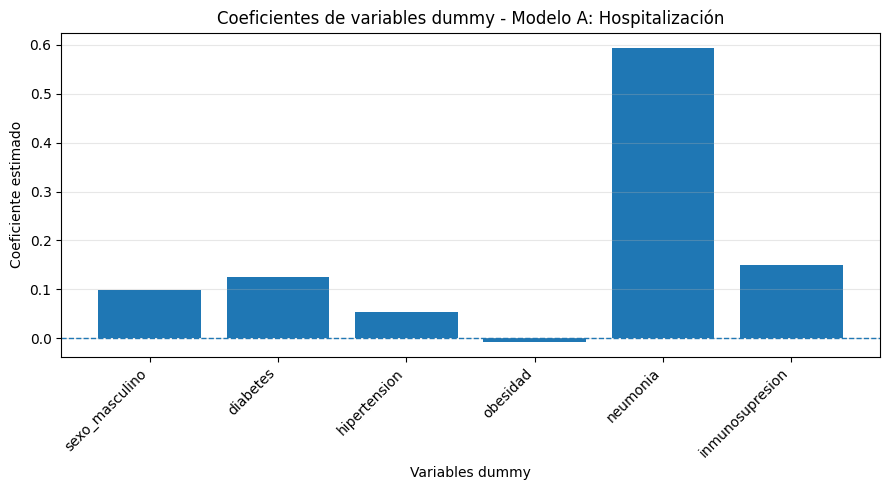

Gráfica guardada en: resultados_etapa_4\coeficientes_dummy_hospitalizacion.png


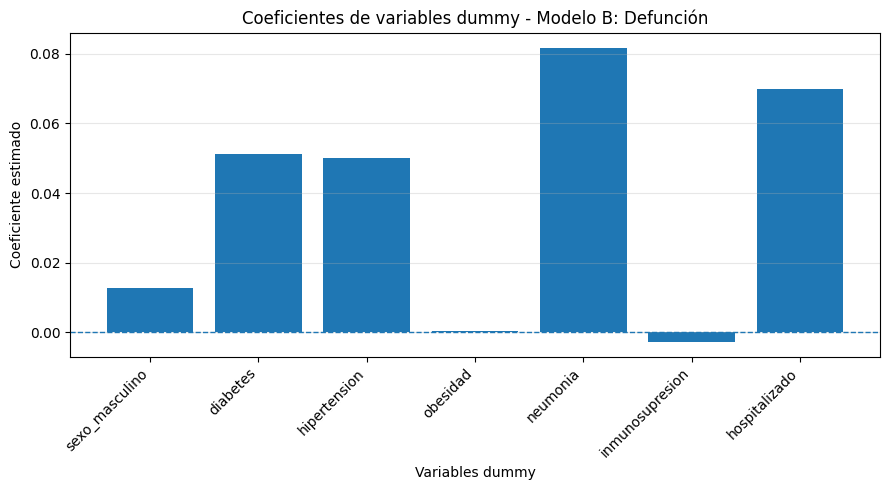

Gráfica guardada en: resultados_etapa_4\coeficientes_dummy_defuncion.png
Archivo Excel guardado en: resultados_etapa_4\resultados_variables_dummy.xlsx
Resumen Modelo A guardado en: resultados_etapa_4\summary_modelo_dummy_hospitalizacion.txt
Resumen Modelo B guardado en: resultados_etapa_4\summary_modelo_dummy_defuncion.txt
Resumen para el reporte
---------------------------------------------

Modelo A: Hospitalización
sexo_masculino: coef = 0.099764, cambio = 9.98 puntos porcentuales, p-valor = 0.000000
diabetes: coef = 0.126134, cambio = 12.61 puntos porcentuales, p-valor = 0.000000
hipertension: coef = 0.053113, cambio = 5.31 puntos porcentuales, p-valor = 0.000140
obesidad: coef = -0.007169, cambio = -0.72 puntos porcentuales, p-valor = 0.699882
neumonia: coef = 0.594122, cambio = 59.41 puntos porcentuales, p-valor = 0.000000
inmunosupresion: coef = 0.149281, cambio = 14.93 puntos porcentuales, p-valor = 0.000000

Modelo B: Defunción
sexo_masculino: coef = 0.012891, cambio = 1.29 pu

In [12]:
# ------------------------------------------------------------
# 9. Gráfica de coeficientes del Modelo A
# ------------------------------------------------------------

coef_hosp = tabla_dummy_hosp.drop(index="const", errors="ignore").copy()

plt.figure(figsize=(9, 5))
plt.bar(coef_hosp.index, coef_hosp["coeficiente"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Coeficientes de variables dummy - Modelo A: Hospitalización")
plt.xlabel("Variables dummy")
plt.ylabel("Coeficiente estimado")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

ruta_coef_hosp = OUT_DIR_4 / "coeficientes_dummy_hospitalizacion.png"
plt.savefig(ruta_coef_hosp, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_coef_hosp}")


# ------------------------------------------------------------
# 10. Gráfica de coeficientes del Modelo B
# ------------------------------------------------------------

coef_def = tabla_dummy_def.drop(index="const", errors="ignore").copy()

plt.figure(figsize=(9, 5))
plt.bar(coef_def.index, coef_def["coeficiente"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Coeficientes de variables dummy - Modelo B: Defunción")
plt.xlabel("Variables dummy")
plt.ylabel("Coeficiente estimado")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

ruta_coef_def = OUT_DIR_4 / "coeficientes_dummy_defuncion.png"
plt.savefig(ruta_coef_def, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_coef_def}")


# ------------------------------------------------------------
# 11. Guardar resultados en Excel y TXT
# ------------------------------------------------------------

ruta_excel_dummy = OUT_DIR_4 / "resultados_variables_dummy.xlsx"

with pd.ExcelWriter(ruta_excel_dummy, engine="openpyxl") as writer:
    tabla_dummies_etapa4.to_excel(writer, sheet_name="distribucion_dummies", index=False)
    tabla_dummy_hosp.to_excel(writer, sheet_name="modelo_hospitalizacion")
    tabla_dummy_def.to_excel(writer, sheet_name="modelo_defuncion")
    metricas_dummy.to_excel(writer, sheet_name="metricas_modelos", index=False)
    sintesis_dummy.to_excel(writer, sheet_name="sintesis_coeficientes", index=False)
    df_modelo_hosp.to_excel(writer, sheet_name="datos_modelo_hosp", index=False)
    df_modelo_def.to_excel(writer, sheet_name="datos_modelo_def", index=False)

print(f"Archivo Excel guardado en: {ruta_excel_dummy}")

ruta_txt_hosp = OUT_DIR_4 / "summary_modelo_dummy_hospitalizacion.txt"
with open(ruta_txt_hosp, "w", encoding="utf-8") as f:
    f.write(str(modelo_dummy_hosp.summary()))

ruta_txt_def = OUT_DIR_4 / "summary_modelo_dummy_defuncion.txt"
with open(ruta_txt_def, "w", encoding="utf-8") as f:
    f.write(str(modelo_dummy_def.summary()))

print(f"Resumen Modelo A guardado en: {ruta_txt_hosp}")
print(f"Resumen Modelo B guardado en: {ruta_txt_def}")


# ------------------------------------------------------------
# 12. Resumen rápido para el reporte
# ------------------------------------------------------------

print("Resumen para el reporte")
print("---------------------------------------------")

print("\nModelo A: Hospitalización")
for var in tabla_dummy_hosp.index:
    if var != "const":
        coef = tabla_dummy_hosp.loc[var, "coeficiente"]
        pval = tabla_dummy_hosp.loc[var, "p_valor"]
        print(f"{var}: coef = {coef:.6f}, cambio = {coef*100:.2f} puntos porcentuales, p-valor = {pval:.6f}")

print("\nModelo B: Defunción")
for var in tabla_dummy_def.index:
    if var != "const":
        coef = tabla_dummy_def.loc[var, "coeficiente"]
        pval = tabla_dummy_def.loc[var, "p_valor"]
        print(f"{var}: coef = {coef:.6f}, cambio = {coef*100:.2f} puntos porcentuales, p-valor = {pval:.6f}")

## **ETAPA 5. MODELOS LOGIT Y PROBIT**

In [13]:
# ============================================================
# ETAPA 5. MODELOS LOGIT Y PROBIT
# Variable dependiente: Defunción
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# Carpeta de salida para esta etapa
OUT_DIR_5 = Path("resultados_etapa_5")
OUT_DIR_5.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 1. Preparar base de trabajo
# ------------------------------------------------------------

df_lp = df_covid.copy()

# Variables sugeridas por el proyecto
variable_dependiente = "defuncion"

variables_predictoras = [
    "edad",
    "sexo_masculino",
    "diabetes",
    "hipertension",
    "obesidad",
    "neumonia",
    "inmunosupresion"
]

# Verificar variables disponibles
variables_predictoras = [v for v in variables_predictoras if v in df_lp.columns]

columnas_modelo = [variable_dependiente] + variables_predictoras

df_modelo_lp = df_lp[columnas_modelo].copy()

# Convertir todo a numérico
for col in columnas_modelo:
    df_modelo_lp[col] = pd.to_numeric(df_modelo_lp[col], errors="coerce")

# Filtrar edades razonables
if "edad" in df_modelo_lp.columns:
    df_modelo_lp = df_modelo_lp[
        (df_modelo_lp["edad"] >= 0) & 
        (df_modelo_lp["edad"] <= 120)
    ]

# Mantener solamente defunción 0/1
df_modelo_lp = df_modelo_lp[df_modelo_lp[variable_dependiente].isin([0, 1])]

# Eliminar valores faltantes
df_modelo_lp = df_modelo_lp.dropna()

# Quitar variables sin variación, si existieran
variables_sin_variacion = []

for var in variables_predictoras:
    if df_modelo_lp[var].nunique() < 2:
        variables_sin_variacion.append(var)

if variables_sin_variacion:
    print("Variables eliminadas por no tener variación:")
    print(variables_sin_variacion)
    variables_predictoras = [v for v in variables_predictoras if v not in variables_sin_variacion]

print("Observaciones utilizadas:", len(df_modelo_lp))
print("Variable dependiente:", variable_dependiente)
print("Variables predictoras:", variables_predictoras)

display(df_modelo_lp.head())


# ------------------------------------------------------------
# 2. Definir Y y X
# ------------------------------------------------------------

Y = df_modelo_lp[variable_dependiente]

X = df_modelo_lp[variables_predictoras]
X = sm.add_constant(X)

print("Dimensiones de X:", X.shape)
print("Dimensiones de Y:", Y.shape)


# ------------------------------------------------------------
# 3. Estimar modelo Logit
# ------------------------------------------------------------

modelo_logit = sm.Logit(Y, X).fit(disp=False, maxiter=200)

print(modelo_logit.summary())


# ------------------------------------------------------------
# 4. Estimar modelo Probit
# ------------------------------------------------------------

modelo_probit = sm.Probit(Y, X).fit(disp=False, maxiter=200)

print(modelo_probit.summary())


# ------------------------------------------------------------
# 5. Tablas de coeficientes Logit y Probit
# ------------------------------------------------------------

tabla_logit = pd.DataFrame({
    "coeficiente": modelo_logit.params,
    "error_estandar": modelo_logit.bse,
    "z": modelo_logit.tvalues,
    "p_valor": modelo_logit.pvalues,
    "IC_95_inf": modelo_logit.conf_int()[0],
    "IC_95_sup": modelo_logit.conf_int()[1]
})

tabla_probit = pd.DataFrame({
    "coeficiente": modelo_probit.params,
    "error_estandar": modelo_probit.bse,
    "z": modelo_probit.tvalues,
    "p_valor": modelo_probit.pvalues,
    "IC_95_inf": modelo_probit.conf_int()[0],
    "IC_95_sup": modelo_probit.conf_int()[1]
})

print("Tabla de coeficientes Logit")
display(tabla_logit)

print("Tabla de coeficientes Probit")
display(tabla_probit)

Observaciones utilizadas: 7648
Variable dependiente: defuncion
Variables predictoras: ['edad', 'sexo_masculino', 'diabetes', 'hipertension', 'obesidad', 'neumonia', 'inmunosupresion']


,defuncion,edad,sexo_masculino,diabetes,hipertension,obesidad,neumonia,inmunosupresion
104,0,26,0,0.0,0.0,0.0,0,0.0
244,0,94,0,0.0,1.0,0.0,0,0.0
380,0,1,0,0.0,0.0,0.0,0,0.0
439,0,43,1,0.0,0.0,0.0,1,1.0
492,1,1,1,0.0,0.0,0.0,1,0.0


Dimensiones de X: (7648, 8)
Dimensiones de Y: (7648,)
                           Logit Regression Results                           
Dep. Variable:              defuncion   No. Observations:                 7648
Model:                          Logit   Df Residuals:                     7640
Method:                           MLE   Df Model:                            7
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.2189
Time:                        22:31:46   Log-Likelihood:                -1308.4
converged:                       True   LL-Null:                       -1675.1
Covariance Type:            nonrobust   LLR p-value:                4.217e-154
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -5.5373      0.166    -33.280      0.000      -5.863      -5.211
edad                0.0324      0.003     12.755      0.000   

,coeficiente,error_estandar,z,p_valor,IC_95_inf,IC_95_sup
const,-5.537271,0.166383,-33.280311,7.440641e-243,-5.863375,-5.211166
edad,0.032369,0.002538,12.755006,2.923529e-37,0.027395,0.037343
sexo_masculino,0.493112,0.107361,4.593025,4.368677e-06,0.282688,0.703535
diabetes,0.415366,0.123900,3.352429,8.010591e-04,0.172527,0.658206
hipertension,0.141290,0.127273,1.110134,2.669413e-01,-0.108160,0.390741
obesidad,0.111651,0.173867,0.642163,5.207672e-01,-0.229121,0.452423
neumonia,1.684387,0.110745,15.209649,3.051759e-52,1.467331,1.901442
inmunosupresion,0.207335,0.204443,1.014145,3.105134e-01,-0.193366,0.608037


Tabla de coeficientes Probit


,coeficiente,error_estandar,z,p_valor,IC_95_inf,IC_95_sup
const,-2.916299,0.076160,-38.291753,0.000000e+00,-3.065570,-2.767028
edad,0.016135,0.001220,13.231114,5.802131e-40,0.013745,0.018526
sexo_masculino,0.248848,0.053870,4.619400,3.848518e-06,0.143264,0.354431
diabetes,0.217357,0.065938,3.296372,9.794226e-04,0.088120,0.346594
hipertension,0.080873,0.066654,1.213332,2.250031e-01,-0.049766,0.211512
obesidad,0.029783,0.091278,0.326292,7.442038e-01,-0.149119,0.208686
neumonia,0.877003,0.054088,16.214514,3.982161e-59,0.770994,0.983013
inmunosupresion,0.114991,0.104277,1.102745,2.701377e-01,-0.089388,0.319370


In [14]:
# ------------------------------------------------------------
# 6. Odds Ratio del modelo Logit
# ------------------------------------------------------------

# En Logit, el Odds Ratio se obtiene como exp(coeficiente).
# OR > 1: aumenta la razón de momios de defunción.
# OR < 1: reduce la razón de momios de defunción.

odds_ratio_logit = pd.DataFrame({
    "coeficiente_logit": modelo_logit.params,
    "odds_ratio": np.exp(modelo_logit.params),
    "OR_IC_95_inf": np.exp(modelo_logit.conf_int()[0]),
    "OR_IC_95_sup": np.exp(modelo_logit.conf_int()[1]),
    "p_valor": modelo_logit.pvalues
})

print("Odds Ratio - Modelo Logit")
display(odds_ratio_logit)


# ------------------------------------------------------------
# 7. Efectos marginales
# ------------------------------------------------------------

# Efectos marginales promedio:
# indican cuánto cambia la probabilidad de defunción ante un cambio
# de una unidad en cada variable explicativa.

marginales_logit = modelo_logit.get_margeff(at="overall").summary_frame()
marginales_probit = modelo_probit.get_margeff(at="overall").summary_frame()

print("Efectos marginales promedio - Logit")
display(marginales_logit)

print("Efectos marginales promedio - Probit")
display(marginales_probit)


# ------------------------------------------------------------
# 8. Probabilidades predichas
# ------------------------------------------------------------

df_predicciones = df_modelo_lp.copy()

df_predicciones["prob_logit"] = modelo_logit.predict(X)
df_predicciones["prob_probit"] = modelo_probit.predict(X)

print("Probabilidades predichas")
display(df_predicciones.head())


# ------------------------------------------------------------
# 9. Clasificación usando umbral de 0.5
# ------------------------------------------------------------

df_predicciones["pred_logit_05"] = np.where(df_predicciones["prob_logit"] >= 0.5, 1, 0)
df_predicciones["pred_probit_05"] = np.where(df_predicciones["prob_probit"] >= 0.5, 1, 0)

def metricas_clasificacion(y_real, y_pred):
    tp = int(((y_real == 1) & (y_pred == 1)).sum())
    tn = int(((y_real == 0) & (y_pred == 0)).sum())
    fp = int(((y_real == 0) & (y_pred == 1)).sum())
    fn = int(((y_real == 1) & (y_pred == 0)).sum())
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    
    return {
        "verdaderos_positivos": tp,
        "verdaderos_negativos": tn,
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall
    }

metricas_logit_clasif = metricas_clasificacion(
    df_predicciones["defuncion"],
    df_predicciones["pred_logit_05"]
)

metricas_probit_clasif = metricas_clasificacion(
    df_predicciones["defuncion"],
    df_predicciones["pred_probit_05"]
)

tabla_clasificacion = pd.DataFrame([
    {"modelo": "Logit", **metricas_logit_clasif},
    {"modelo": "Probit", **metricas_probit_clasif}
])

print("Métricas de clasificación con umbral 0.5")
display(tabla_clasificacion)


# ------------------------------------------------------------
# 10. Comparación Logit vs Probit
# ------------------------------------------------------------

comparacion_logit_probit = pd.DataFrame({
    "modelo": ["Logit", "Probit"],
    "observaciones": [int(modelo_logit.nobs), int(modelo_probit.nobs)],
    "log_likelihood": [modelo_logit.llf, modelo_probit.llf],
    "pseudo_r2_mcfadden": [modelo_logit.prsquared, modelo_probit.prsquared],
    "aic": [modelo_logit.aic, modelo_probit.aic],
    "bic": [modelo_logit.bic, modelo_probit.bic],
    "accuracy_umbral_05": [
        tabla_clasificacion.loc[tabla_clasificacion["modelo"] == "Logit", "accuracy"].iloc[0],
        tabla_clasificacion.loc[tabla_clasificacion["modelo"] == "Probit", "accuracy"].iloc[0]
    ],
    "precision_umbral_05": [
        tabla_clasificacion.loc[tabla_clasificacion["modelo"] == "Logit", "precision"].iloc[0],
        tabla_clasificacion.loc[tabla_clasificacion["modelo"] == "Probit", "precision"].iloc[0]
    ],
    "recall_umbral_05": [
        tabla_clasificacion.loc[tabla_clasificacion["modelo"] == "Logit", "recall"].iloc[0],
        tabla_clasificacion.loc[tabla_clasificacion["modelo"] == "Probit", "recall"].iloc[0]
    ]
})

print("Comparación Logit vs Probit")
display(comparacion_logit_probit)

Odds Ratio - Modelo Logit


,coeficiente_logit,odds_ratio,OR_IC_95_inf,OR_IC_95_sup,p_valor
const,-5.537271,0.003937,0.002842,0.005455,7.440641e-243
edad,0.032369,1.032898,1.027774,1.038049,2.923529e-37
sexo_masculino,0.493112,1.637403,1.326691,2.020885,4.368677e-06
diabetes,0.415366,1.514926,1.188303,1.931325,8.010591e-04
hipertension,0.141290,1.151759,0.897484,1.478075,2.669413e-01
obesidad,0.111651,1.118122,0.795232,1.572117,5.207672e-01
neumonia,1.684387,5.389144,4.337643,6.695542,3.051759e-52
inmunosupresion,0.207335,1.230395,0.824180,1.836823,3.105134e-01


Efectos marginales promedio - Logit


,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
edad,0.001486,0.000120,12.394692,2.792176e-35,0.001251,0.001721
sexo_masculino,0.022632,0.004940,4.581501,4.616498e-06,0.012950,0.032314
diabetes,0.019064,0.005693,3.348638,8.120997e-04,0.007906,0.030222
hipertension,0.006485,0.005843,1.109867,2.670565e-01,-0.004967,0.017937
obesidad,0.005124,0.007982,0.642014,5.208642e-01,-0.010520,0.020768
neumonia,0.077308,0.005247,14.732861,3.965558e-49,0.067024,0.087593
inmunosupresion,0.009516,0.009388,1.013630,3.107592e-01,-0.008884,0.027916


Efectos marginales promedio - Probit


...

,defuncion,edad,sexo_masculino,diabetes,hipertension,obesidad,neumonia,inmunosupresion,prob_logit,prob_probit
104,0,26,0,0.0,0.0,0.0,0,0.0,0.009052,0.006266
244,0,94,0,0.0,1.0,0.0,0,0.0,0.086803,0.093636
380,0,1,0,0.0,0.0,0.0,0,0.0,0.004050,0.001865
439,0,43,1,0.0,0.0,0.0,1,1.0,0.146718,0.163141
492,1,1,1,0.0,0.0,0.0,1,0.0,0.034643,0.038006


Métricas de clasificación con umbral 0.5


,modelo,verdaderos_positivos,verdaderos_negativos,falsos_positivos,falsos_negativos,accuracy,precision,recall
0,Logit,7,7203,8,430,0.94273,0.466667,0.016018
1,Probit,1,7209,2,436,0.94273,0.333333,0.002288


Comparación Logit vs Probit


,modelo,observaciones,log_likelihood,pseudo_r2_mcfadden,aic,bic,accuracy_umbral_05,precision_umbral_05,recall_umbral_05
0,Logit,7648,-1308.354198,0.218931,2632.708396,2688.245992,0.94273,0.466667,0.016018
1,Probit,7648,-1299.434888,0.224255,2614.869776,2670.407371,0.94273,0.333333,0.002288


Probabilidades predichas por perfil


,perfil,edad,sexo_masculino,diabetes,hipertension,obesidad,neumonia,inmunosupresion,prob_logit,prob_probit
0,Paciente base,38.0,0,0,0,0,0,0,0.013291,0.010635
1,Paciente mayor sin comorbilidades,65.0,0,0,0,0,0,0,0.031271,0.030916
2,Paciente mayor con diabetes e hipertensión,65.0,0,1,1,0,0,0,0.053321,0.058293
3,Paciente mayor con neumonía y comorbilidades,65.0,1,1,1,1,1,0,0.357211,0.339573


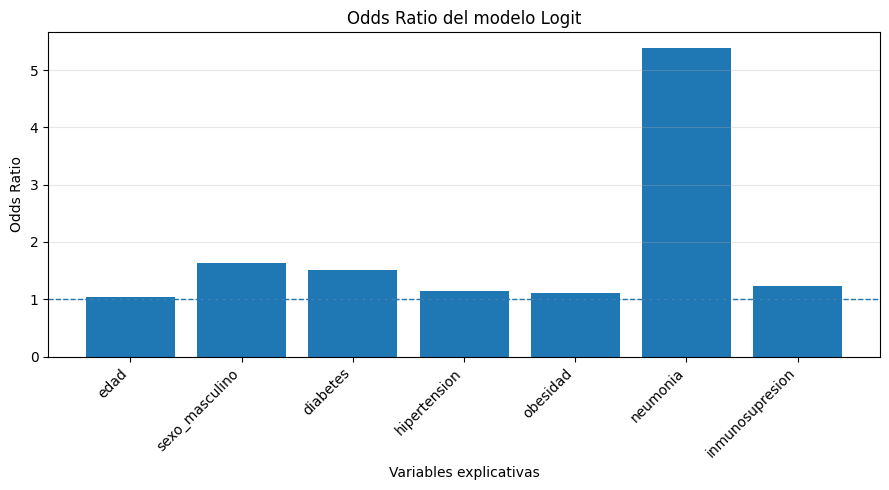

Gráfica guardada en: resultados_etapa_5\odds_ratio_logit.png


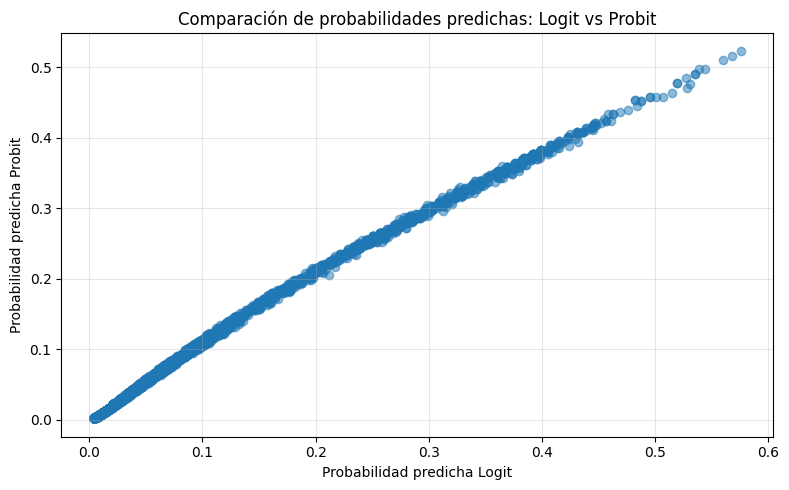

Gráfica guardada en: resultados_etapa_5\comparacion_probabilidades_logit_probit.png


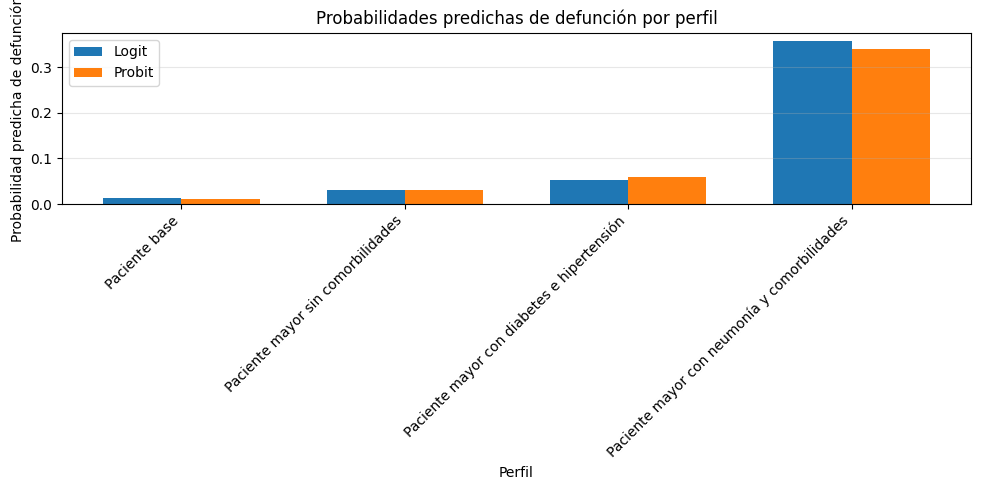

Gráfica guardada en: resultados_etapa_5\probabilidades_predichas_perfiles.png


In [15]:
# ------------------------------------------------------------
# 11. Probabilidades predichas por perfiles
# ------------------------------------------------------------

# Creamos perfiles hipotéticos para interpretar el modelo.
# Esto ayuda mucho en el reporte.

edad_promedio = df_modelo_lp["edad"].mean()
edad_mediana = df_modelo_lp["edad"].median()

perfiles = pd.DataFrame([
    {
        "perfil": "Paciente base",
        "edad": edad_mediana,
        "sexo_masculino": 0,
        "diabetes": 0,
        "hipertension": 0,
        "obesidad": 0,
        "neumonia": 0,
        "inmunosupresion": 0
    },
    {
        "perfil": "Paciente mayor sin comorbilidades",
        "edad": 65,
        "sexo_masculino": 0,
        "diabetes": 0,
        "hipertension": 0,
        "obesidad": 0,
        "neumonia": 0,
        "inmunosupresion": 0
    },
    {
        "perfil": "Paciente mayor con diabetes e hipertensión",
        "edad": 65,
        "sexo_masculino": 0,
        "diabetes": 1,
        "hipertension": 1,
        "obesidad": 0,
        "neumonia": 0,
        "inmunosupresion": 0
    },
    {
        "perfil": "Paciente mayor con neumonía y comorbilidades",
        "edad": 65,
        "sexo_masculino": 1,
        "diabetes": 1,
        "hipertension": 1,
        "obesidad": 1,
        "neumonia": 1,
        "inmunosupresion": 0
    }
])

# Mantener solo columnas usadas en el modelo
columnas_perfil = ["perfil"] + variables_predictoras
perfiles = perfiles[[c for c in columnas_perfil if c in perfiles.columns]]

X_perfiles = perfiles[variables_predictoras].copy()
X_perfiles = sm.add_constant(X_perfiles, has_constant="add")

# Asegurar mismo orden de columnas que X
X_perfiles = X_perfiles[X.columns]

perfiles["prob_logit"] = modelo_logit.predict(X_perfiles)
perfiles["prob_probit"] = modelo_probit.predict(X_perfiles)

print("Probabilidades predichas por perfil")
display(perfiles)


# ------------------------------------------------------------
# 12. Gráfica: Odds Ratio Logit
# ------------------------------------------------------------

or_plot = odds_ratio_logit.drop(index="const", errors="ignore").copy()

plt.figure(figsize=(9, 5))
plt.bar(or_plot.index, or_plot["odds_ratio"])
plt.axhline(1, linestyle="--", linewidth=1)
plt.title("Odds Ratio del modelo Logit")
plt.xlabel("Variables explicativas")
plt.ylabel("Odds Ratio")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

ruta_or = OUT_DIR_5 / "odds_ratio_logit.png"
plt.savefig(ruta_or, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_or}")


# ------------------------------------------------------------
# 13. Gráfica: comparación de probabilidades predichas
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df_predicciones["prob_logit"],
    df_predicciones["prob_probit"],
    alpha=0.5
)

plt.title("Comparación de probabilidades predichas: Logit vs Probit")
plt.xlabel("Probabilidad predicha Logit")
plt.ylabel("Probabilidad predicha Probit")
plt.grid(alpha=0.3)
plt.tight_layout()

ruta_probs = OUT_DIR_5 / "comparacion_probabilidades_logit_probit.png"
plt.savefig(ruta_probs, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_probs}")


# ------------------------------------------------------------
# 14. Gráfica: probabilidades predichas por perfil
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

x = np.arange(len(perfiles))
width = 0.35

plt.bar(x - width/2, perfiles["prob_logit"], width, label="Logit")
plt.bar(x + width/2, perfiles["prob_probit"], width, label="Probit")

plt.title("Probabilidades predichas de defunción por perfil")
plt.xlabel("Perfil")
plt.ylabel("Probabilidad predicha de defunción")
plt.xticks(x, perfiles["perfil"], rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

ruta_perfiles = OUT_DIR_5 / "probabilidades_predichas_perfiles.png"
plt.savefig(ruta_perfiles, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_perfiles}")

In [16]:
# ------------------------------------------------------------
# 15. Guardar resultados en Excel y TXT
# ------------------------------------------------------------

ruta_excel_lp = OUT_DIR_5 / "resultados_logit_probit.xlsx"

with pd.ExcelWriter(ruta_excel_lp, engine="openpyxl") as writer:
    tabla_logit.to_excel(writer, sheet_name="coeficientes_logit")
    tabla_probit.to_excel(writer, sheet_name="coeficientes_probit")
    odds_ratio_logit.to_excel(writer, sheet_name="odds_ratio_logit")
    marginales_logit.to_excel(writer, sheet_name="marginales_logit")
    marginales_probit.to_excel(writer, sheet_name="marginales_probit")
    comparacion_logit_probit.to_excel(writer, sheet_name="comparacion_modelos", index=False)
    tabla_clasificacion.to_excel(writer, sheet_name="clasificacion_05", index=False)
    perfiles.to_excel(writer, sheet_name="probabilidades_perfiles", index=False)
    df_predicciones.to_excel(writer, sheet_name="predicciones", index=False)
    df_modelo_lp.to_excel(writer, sheet_name="datos_modelo", index=False)

print(f"Archivo Excel guardado en: {ruta_excel_lp}")

ruta_txt_logit = OUT_DIR_5 / "summary_logit.txt"
with open(ruta_txt_logit, "w", encoding="utf-8") as f:
    f.write(str(modelo_logit.summary()))

ruta_txt_probit = OUT_DIR_5 / "summary_probit.txt"
with open(ruta_txt_probit, "w", encoding="utf-8") as f:
    f.write(str(modelo_probit.summary()))

print(f"Resumen Logit guardado en: {ruta_txt_logit}")
print(f"Resumen Probit guardado en: {ruta_txt_probit}")


# ------------------------------------------------------------
# 16. Síntesis de resultados para el reporte
# ------------------------------------------------------------

print("Resumen para el reporte")
print("---------------------------------------------")

print("\nModelo Logit")
for var in odds_ratio_logit.index:
    if var != "const":
        coef = tabla_logit.loc[var, "coeficiente"]
        pval = tabla_logit.loc[var, "p_valor"]
        or_val = odds_ratio_logit.loc[var, "odds_ratio"]
        print(
            f"{var}: coef = {coef:.6f}, OR = {or_val:.4f}, "
            f"p-valor = {pval:.6f}"
        )

print("\nEfectos marginales Logit")
for var in marginales_logit.index:
    dy_dx = marginales_logit.loc[var, "dy/dx"]
    pval = marginales_logit.loc[var, "Pr(>|z|)"]
    print(
        f"{var}: efecto marginal = {dy_dx:.6f}, "
        f"cambio en puntos porcentuales = {dy_dx*100:.4f}, "
        f"p-valor = {pval:.6f}"
    )

print("\nComparación Logit vs Probit")
display(comparacion_logit_probit)

print("\nProbabilidades predichas por perfil")
display(perfiles)

Archivo Excel guardado en: resultados_etapa_5\resultados_logit_probit.xlsx
Resumen Logit guardado en: resultados_etapa_5\summary_logit.txt
Resumen Probit guardado en: resultados_etapa_5\summary_probit.txt
Resumen para el reporte
---------------------------------------------

Modelo Logit
edad: coef = 0.032369, OR = 1.0329, p-valor = 0.000000
sexo_masculino: coef = 0.493112, OR = 1.6374, p-valor = 0.000004
diabetes: coef = 0.415366, OR = 1.5149, p-valor = 0.000801
hipertension: coef = 0.141290, OR = 1.1518, p-valor = 0.266941
obesidad: coef = 0.111651, OR = 1.1181, p-valor = 0.520767
neumonia: coef = 1.684387, OR = 5.3891, p-valor = 0.000000
inmunosupresion: coef = 0.207335, OR = 1.2304, p-valor = 0.310513

Efectos marginales Logit
edad: efecto marginal = 0.001486, cambio en puntos porcentuales = 0.1486, p-valor = 0.000000
sexo_masculino: efecto marginal = 0.022632, cambio en puntos porcentuales = 2.2632, p-valor = 0.000005
diabetes: efecto marginal = 0.019064, cambio en puntos porcentu

,modelo,observaciones,log_likelihood,pseudo_r2_mcfadden,aic,bic,accuracy_umbral_05,precision_umbral_05,recall_umbral_05
0,Logit,7648,-1308.354198,0.218931,2632.708396,2688.245992,0.94273,0.466667,0.016018
1,Probit,7648,-1299.434888,0.224255,2614.869776,2670.407371,0.94273,0.333333,0.002288



Probabilidades predichas por perfil


,perfil,edad,sexo_masculino,diabetes,hipertension,obesidad,neumonia,inmunosupresion,prob_logit,prob_probit
0,Paciente base,38.0,0,0,0,0,0,0,0.013291,0.010635
1,Paciente mayor sin comorbilidades,65.0,0,0,0,0,0,0,0.031271,0.030916
2,Paciente mayor con diabetes e hipertensión,65.0,0,1,1,0,0,0,0.053321,0.058293
3,Paciente mayor con neumonía y comorbilidades,65.0,1,1,1,1,1,0,0.357211,0.339573


## **ETAPA 6. MULTICOLINEALIDAD**

In [17]:
# ============================================================
# ETAPA 6. MULTICOLINEALIDAD
# Matriz de correlación y VIF
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from IPython.display import display
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Carpeta de salida
OUT_DIR_6 = Path("resultados_etapa_6")
OUT_DIR_6.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 1. Funciones auxiliares
# ------------------------------------------------------------

def preparar_variables_para_vif(df_base, variables):
    """
    Selecciona variables, convierte a numérico, elimina NA
    y quita variables sin variación.
    """
    variables_disponibles = [v for v in variables if v in df_base.columns]
    df_vif = df_base[variables_disponibles].copy()
    
    for col in df_vif.columns:
        df_vif[col] = pd.to_numeric(df_vif[col], errors="coerce")
    
    df_vif = df_vif.dropna()
    
    # Quitar variables sin variación
    variables_sin_variacion = [
        col for col in df_vif.columns 
        if df_vif[col].nunique() < 2
    ]
    
    if variables_sin_variacion:
        print("Variables eliminadas por no tener variación:")
        print(variables_sin_variacion)
        df_vif = df_vif.drop(columns=variables_sin_variacion)
    
    return df_vif


def calcular_vif(df_variables):
    """
    Calcula VIF para cada variable explicativa.
    """
    X = sm.add_constant(df_variables)
    
    resultados = []
    
    for i, col in enumerate(X.columns):
        if col == "const":
            continue
        
        try:
            vif = variance_inflation_factor(X.values, i)
        except Exception:
            vif = np.nan
        
        resultados.append({
            "variable": col,
            "VIF": vif,
            "interpretacion": interpretar_vif(vif)
        })
    
    return pd.DataFrame(resultados)


def interpretar_vif(vif):
    """
    Clasificación práctica del VIF.
    """
    if pd.isna(vif):
        return "No calculable"
    elif vif < 5:
        return "Bajo: no sugiere multicolinealidad relevante"
    elif vif < 10:
        return "Moderado: revisar posible multicolinealidad"
    else:
        return "Alto: posible multicolinealidad severa"


def obtener_correlaciones_altas(matriz_corr, umbral=0.70):
    """
    Obtiene pares de variables con correlación absoluta alta.
    """
    pares = []
    cols = matriz_corr.columns
    
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            corr = matriz_corr.iloc[i, j]
            
            if abs(corr) >= umbral:
                pares.append({
                    "variable_1": cols[i],
                    "variable_2": cols[j],
                    "correlacion": corr,
                    "correlacion_absoluta": abs(corr)
                })
    
    return pd.DataFrame(pares)


def graficar_matriz_correlacion(matriz_corr, titulo, ruta_salida):
    """
    Grafica y guarda matriz de correlación.
    """
    plt.figure(figsize=(10, 8))
    plt.imshow(matriz_corr, aspect="auto")
    plt.colorbar(label="Correlación")
    
    plt.xticks(
        range(len(matriz_corr.columns)), 
        matriz_corr.columns, 
        rotation=90
    )
    plt.yticks(
        range(len(matriz_corr.index)), 
        matriz_corr.index
    )
    
    # Agregar valores dentro de la matriz
    for i in range(len(matriz_corr.index)):
        for j in range(len(matriz_corr.columns)):
            plt.text(
                j, i, 
                f"{matriz_corr.iloc[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )
    
    plt.title(titulo)
    plt.tight_layout()
    plt.savefig(ruta_salida, dpi=300)
    plt.show()
    
    print(f"Gráfica guardada en: {ruta_salida}")

Observaciones usadas para diagnóstico clínico: 7648


,edad,sexo_masculino,diabetes,hipertension,obesidad,neumonia,inmunosupresion
104,26,0,0.0,0.0,0.0,0,0.0
244,94,0,0.0,1.0,0.0,0,0.0
380,1,0,0.0,0.0,0.0,0,0.0
439,43,1,0.0,0.0,0.0,1,1.0
492,1,1,0.0,0.0,0.0,1,0.0


Matriz de correlación - variables clínicas


,edad,sexo_masculino,diabetes,hipertension,obesidad,neumonia,inmunosupresion
edad,1.000000,-0.038460,0.391315,0.475545,0.129476,0.066780,0.024480
sexo_masculino,-0.038460,1.000000,0.011853,0.014273,-0.040384,0.096768,0.024736
diabetes,0.391315,0.011853,1.000000,0.473857,0.157061,0.140746,0.018706
hipertension,0.475545,0.014273,0.473857,1.000000,0.221769,0.142507,0.012248
obesidad,0.129476,-0.040384,0.157061,0.221769,1.000000,0.022281,0.016642
neumonia,0.066780,0.096768,0.140746,0.142507,0.022281,1.000000,0.075854
inmunosupresion,0.024480,0.024736,0.018706,0.012248,0.016642,0.075854,1.000000


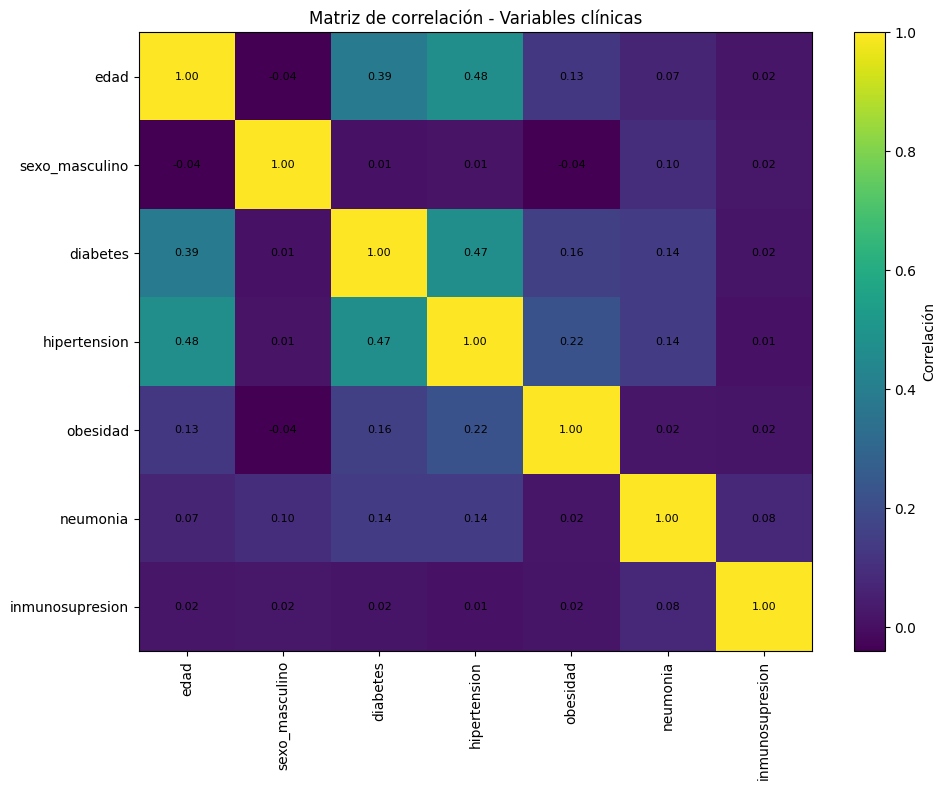

Gráfica guardada en: resultados_etapa_6\matriz_correlacion_clinica.png
Pares de variables clínicas con correlación absoluta >= 0.70


""


VIF - Variables clínicas


,variable,VIF,interpretacion
0,edad,1.359454,Bajo: no sugiere multicolinealidad relevante
1,sexo_masculino,1.014493,Bajo: no sugiere multicolinealidad relevante
2,diabetes,1.366347,Bajo: no sugiere multicolinealidad relevante
3,hipertension,1.528182,Bajo: no sugiere multicolinealidad relevante
4,obesidad,1.058278,Bajo: no sugiere multicolinealidad relevante
5,neumonia,1.043261,Bajo: no sugiere multicolinealidad relevante
6,inmunosupresion,1.006842,Bajo: no sugiere multicolinealidad relevante


Observaciones usadas para diagnóstico temporal: 521


,hospitalizaciones_diarias,casos_diarios
0,5.0,7.0
1,2.0,2.0
2,3.0,7.0
3,5.0,7.0
4,3.0,8.0


Matriz de correlación - variables temporales


,hospitalizaciones_diarias,casos_diarios
hospitalizaciones_diarias,1.000000,0.945281
casos_diarios,0.945281,1.000000


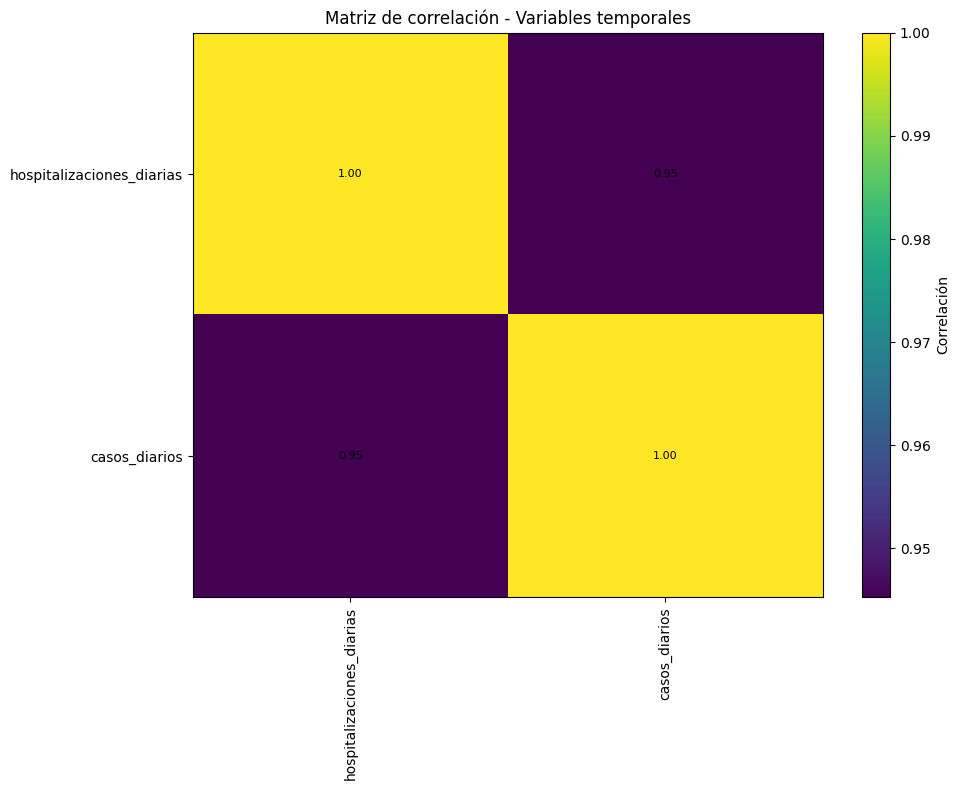

Gráfica guardada en: resultados_etapa_6\matriz_correlacion_temporal.png
Pares de variables temporales con correlación absoluta >= 0.70


,variable_1,variable_2,correlacion,correlacion_absoluta
0,hospitalizaciones_diarias,casos_diarios,0.945281,0.945281


VIF - Variables temporales


,variable,VIF,interpretacion
0,hospitalizaciones_diarias,9.394659,Moderado: revisar posible multicolinealidad
1,casos_diarios,9.394659,Moderado: revisar posible multicolinealidad


In [18]:
# ------------------------------------------------------------
# 2. Variables clínicas usadas en Logit y Probit
# ------------------------------------------------------------

variables_clinicas_vif = [
    "edad",
    "sexo_masculino",
    "diabetes",
    "hipertension",
    "obesidad",
    "neumonia",
    "inmunosupresion"
]

df_vif_clinico = preparar_variables_para_vif(
    df_covid,
    variables_clinicas_vif
)

print("Observaciones usadas para diagnóstico clínico:", len(df_vif_clinico))
display(df_vif_clinico.head())


# ------------------------------------------------------------
# 3. Matriz de correlación clínica
# ------------------------------------------------------------

matriz_corr_clinica = df_vif_clinico.corr()

print("Matriz de correlación - variables clínicas")
display(matriz_corr_clinica)

ruta_corr_clinica = OUT_DIR_6 / "matriz_correlacion_clinica.png"

graficar_matriz_correlacion(
    matriz_corr_clinica,
    "Matriz de correlación - Variables clínicas",
    ruta_corr_clinica
)


# ------------------------------------------------------------
# 4. Correlaciones clínicas altas
# ------------------------------------------------------------

correlaciones_altas_clinicas = obtener_correlaciones_altas(
    matriz_corr_clinica,
    umbral=0.70
)

print("Pares de variables clínicas con correlación absoluta >= 0.70")
display(correlaciones_altas_clinicas)


# ------------------------------------------------------------
# 5. VIF variables clínicas
# ------------------------------------------------------------

vif_clinico = calcular_vif(df_vif_clinico)

print("VIF - Variables clínicas")
display(vif_clinico)


# ------------------------------------------------------------
# 6. Variables temporales usadas en regresión múltiple
# ------------------------------------------------------------

variables_temporales_vif = [
    "hospitalizaciones_diarias",
    "casos_diarios"
]

df_vif_temporal = preparar_variables_para_vif(
    df_ts,
    variables_temporales_vif
)

print("Observaciones usadas para diagnóstico temporal:", len(df_vif_temporal))
display(df_vif_temporal.head())


# ------------------------------------------------------------
# 7. Matriz de correlación temporal
# ------------------------------------------------------------

matriz_corr_temporal = df_vif_temporal.corr()

print("Matriz de correlación - variables temporales")
display(matriz_corr_temporal)

ruta_corr_temporal = OUT_DIR_6 / "matriz_correlacion_temporal.png"

graficar_matriz_correlacion(
    matriz_corr_temporal,
    "Matriz de correlación - Variables temporales",
    ruta_corr_temporal
)


# ------------------------------------------------------------
# 8. Correlaciones temporales altas
# ------------------------------------------------------------

correlaciones_altas_temporales = obtener_correlaciones_altas(
    matriz_corr_temporal,
    umbral=0.70
)

print("Pares de variables temporales con correlación absoluta >= 0.70")
display(correlaciones_altas_temporales)


# ------------------------------------------------------------
# 9. VIF variables temporales
# ------------------------------------------------------------

vif_temporal = calcular_vif(df_vif_temporal)

print("VIF - Variables temporales")
display(vif_temporal)

In [19]:
# ------------------------------------------------------------
# 10. Recomendaciones según resultados VIF
# ------------------------------------------------------------

def generar_recomendaciones_vif(tabla_vif, nombre_bloque):
    recomendaciones = []
    
    for _, row in tabla_vif.iterrows():
        variable = row["variable"]
        vif = row["VIF"]
        
        if pd.isna(vif):
            recomendacion = "Revisar la variable, ya que el VIF no pudo calcularse."
        elif vif < 5:
            recomendacion = "No se requiere corrección por multicolinealidad."
        elif vif < 10:
            recomendacion = (
                "Revisar correlaciones con otras variables. "
                "La multicolinealidad es moderada, pero no necesariamente crítica."
            )
        else:
            recomendacion = (
                "Existe posible multicolinealidad severa. "
                "Considerar eliminar variables redundantes, combinar variables relacionadas "
                "o usar una especificación alternativa."
            )
        
        recomendaciones.append({
            "bloque": nombre_bloque,
            "variable": variable,
            "VIF": vif,
            "diagnostico": row["interpretacion"],
            "recomendacion": recomendacion
        })
    
    return pd.DataFrame(recomendaciones)


recomendaciones_clinicas = generar_recomendaciones_vif(
    vif_clinico,
    "Variables clínicas"
)

recomendaciones_temporales = generar_recomendaciones_vif(
    vif_temporal,
    "Variables temporales"
)

recomendaciones_vif = pd.concat(
    [recomendaciones_clinicas, recomendaciones_temporales],
    ignore_index=True
)

print("Recomendaciones generales según VIF")
display(recomendaciones_vif)


# ------------------------------------------------------------
# 11. Guardar resultados en Excel
# ------------------------------------------------------------

ruta_excel_multicolinealidad = OUT_DIR_6 / "resultados_multicolinealidad.xlsx"

with pd.ExcelWriter(ruta_excel_multicolinealidad, engine="openpyxl") as writer:
    matriz_corr_clinica.to_excel(writer, sheet_name="corr_clinica")
    vif_clinico.to_excel(writer, sheet_name="vif_clinico", index=False)
    correlaciones_altas_clinicas.to_excel(writer, sheet_name="corr_altas_clinicas", index=False)
    
    matriz_corr_temporal.to_excel(writer, sheet_name="corr_temporal")
    vif_temporal.to_excel(writer, sheet_name="vif_temporal", index=False)
    correlaciones_altas_temporales.to_excel(writer, sheet_name="corr_altas_temporales", index=False)
    
    recomendaciones_vif.to_excel(writer, sheet_name="recomendaciones", index=False)

print(f"Archivo Excel guardado en: {ruta_excel_multicolinealidad}")


# ------------------------------------------------------------
# 12. Guardar resumen en TXT
# ------------------------------------------------------------

ruta_txt_multicolinealidad = OUT_DIR_6 / "resumen_multicolinealidad.txt"

with open(ruta_txt_multicolinealidad, "w", encoding="utf-8") as f:
    f.write("ETAPA 6. MULTICOLINEALIDAD\n")
    f.write("=" * 60 + "\n\n")
    
    f.write("Variables clínicas analizadas:\n")
    f.write(", ".join(df_vif_clinico.columns) + "\n\n")
    
    f.write("VIF - Variables clínicas:\n")
    f.write(vif_clinico.to_string(index=False))
    f.write("\n\n")
    
    f.write("Correlaciones clínicas altas:\n")
    if len(correlaciones_altas_clinicas) > 0:
        f.write(correlaciones_altas_clinicas.to_string(index=False))
    else:
        f.write("No se detectaron correlaciones absolutas mayores o iguales a 0.70.")
    
    f.write("\n\n" + "-" * 60 + "\n\n")
    
    f.write("Variables temporales analizadas:\n")
    f.write(", ".join(df_vif_temporal.columns) + "\n\n")
    
    f.write("VIF - Variables temporales:\n")
    f.write(vif_temporal.to_string(index=False))
    f.write("\n\n")
    
    f.write("Correlaciones temporales altas:\n")
    if len(correlaciones_altas_temporales) > 0:
        f.write(correlaciones_altas_temporales.to_string(index=False))
    else:
        f.write("No se detectaron correlaciones absolutas mayores o iguales a 0.70.")
    
    f.write("\n\n" + "-" * 60 + "\n\n")
    
    f.write("Recomendaciones:\n")
    f.write(recomendaciones_vif.to_string(index=False))

print(f"Resumen TXT guardado en: {ruta_txt_multicolinealidad}")


# ------------------------------------------------------------
# 13. Síntesis de resultados para el reporte
# ------------------------------------------------------------

print("Resumen para el reporte")
print("---------------------------------------------")

print("\nVariables clínicas")
display(vif_clinico)

max_vif_clinico = vif_clinico["VIF"].max()
print(f"Mayor VIF clínico: {max_vif_clinico:.4f}")

if max_vif_clinico < 5:
    print("Lectura técnica: No se observa multicolinealidad relevante en las variables clínicas.")
elif max_vif_clinico < 10:
    print("Lectura técnica: Se observa multicolinealidad moderada en algunas variables clínicas.")
else:
    print("Lectura técnica: Se observa posible multicolinealidad severa en variables clínicas.")

print("\nVariables temporales")
display(vif_temporal)

max_vif_temporal = vif_temporal["VIF"].max()
print(f"Mayor VIF temporal: {max_vif_temporal:.4f}")

if max_vif_temporal < 5:
    print("Lectura técnica: No se observa multicolinealidad relevante en las variables temporales.")
elif max_vif_temporal < 10:
    print("Lectura técnica: Se observa multicolinealidad moderada en algunas variables temporales.")
else:
    print("Lectura técnica: Se observa posible multicolinealidad severa en variables temporales.")

print("\nCorrelaciones clínicas altas:")
display(correlaciones_altas_clinicas)

print("\nCorrelaciones temporales altas:")
display(correlaciones_altas_temporales)

Recomendaciones generales según VIF


,bloque,variable,VIF,diagnostico,recomendacion
0,Variables clínicas,edad,1.359454,Bajo: no sugiere multicolinealidad relevante,No se requiere corrección por multicolinealidad.
1,Variables clínicas,sexo_masculino,1.014493,Bajo: no sugiere multicolinealidad relevante,No se requiere corrección por multicolinealidad.
2,Variables clínicas,diabetes,1.366347,Bajo: no sugiere multicolinealidad relevante,No se requiere corrección por multicolinealidad.
3,Variables clínicas,hipertension,1.528182,Bajo: no sugiere multicolinealidad relevante,No se requiere corrección por multicolinealidad.
4,Variables clínicas,obesidad,1.058278,Bajo: no sugiere multicolinealidad relevante,No se requiere corrección por multicolinealidad.
5,Variables clínicas,neumonia,1.043261,Bajo: no sugiere multicolinealidad relevante,No se requiere corrección por multicolinealidad.
6,Variables clínicas,inmunosupresion,1.006842,Bajo: no sugiere multicolinealidad relevante,No se requiere corrección por multicolinealidad.
7,Variables temporales,hospitalizaciones_diarias,9.394659,Moderado: revisar posible multicolinealidad,Revisar correlaciones con otras variables. La ...
8,Variables temporales,casos_diarios,9.394659,Moderado: revisar posible multicolinealidad,Revisar correlaciones con otras variables. La ...


Archivo Excel guardado en: resultados_etapa_6\resultados_multicolinealidad.xlsx
Resumen TXT guardado en: resultados_etapa_6\resumen_multicolinealidad.txt
Resumen para el reporte
---------------------------------------------

Variables clínicas


,variable,VIF,interpretacion
0,edad,1.359454,Bajo: no sugiere multicolinealidad relevante
1,sexo_masculino,1.014493,Bajo: no sugiere multicolinealidad relevante
2,diabetes,1.366347,Bajo: no sugiere multicolinealidad relevante
3,hipertension,1.528182,Bajo: no sugiere multicolinealidad relevante
4,obesidad,1.058278,Bajo: no sugiere multicolinealidad relevante
5,neumonia,1.043261,Bajo: no sugiere multicolinealidad relevante
6,inmunosupresion,1.006842,Bajo: no sugiere multicolinealidad relevante


Mayor VIF clínico: 1.5282
Lectura técnica: No se observa multicolinealidad relevante en las variables clínicas.

Variables temporales


,variable,VIF,interpretacion
0,hospitalizaciones_diarias,9.394659,Moderado: revisar posible multicolinealidad
1,casos_diarios,9.394659,Moderado: revisar posible multicolinealidad


Mayor VIF temporal: 9.3947
Lectura técnica: Se observa multicolinealidad moderada en algunas variables temporales.

Correlaciones clínicas altas:


""



Correlaciones temporales altas:


,variable_1,variable_2,correlacion,correlacion_absoluta
0,hospitalizaciones_diarias,casos_diarios,0.945281,0.945281


## **ETAPA 7. HETEROCEDASTICIDAD**

In [20]:
# ============================================================
# ETAPA 7. HETEROCEDASTICIDAD
# Pruebas de Breusch-Pagan, White y errores robustos
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from IPython.display import display
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

# Carpeta de salida para esta etapa
OUT_DIR_7 = Path("resultados_etapa_7")
OUT_DIR_7.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 1. Modelo de regresión lineal simple
# Defunciones diarias ~ Hospitalizaciones diarias
# ------------------------------------------------------------

df_rls_het = df_ts[[
    "defunciones_diarias",
    "hospitalizaciones_diarias"
]].copy()

for col in df_rls_het.columns:
    df_rls_het[col] = pd.to_numeric(df_rls_het[col], errors="coerce")

df_rls_het = df_rls_het.dropna()

Y_rls = df_rls_het["defunciones_diarias"]
X_rls = df_rls_het[["hospitalizaciones_diarias"]]
X_rls = sm.add_constant(X_rls)

modelo_rls_het = sm.OLS(Y_rls, X_rls).fit()

print("Resumen modelo RLS")
print(modelo_rls_het.summary())


# ------------------------------------------------------------
# 2. Modelo de regresión lineal múltiple
# Defunciones diarias ~ Hospitalizaciones diarias + Casos diarios
# ------------------------------------------------------------

df_rlm_het = df_ts[[
    "defunciones_diarias",
    "hospitalizaciones_diarias",
    "casos_diarios"
]].copy()

for col in df_rlm_het.columns:
    df_rlm_het[col] = pd.to_numeric(df_rlm_het[col], errors="coerce")

df_rlm_het = df_rlm_het.dropna()

Y_rlm = df_rlm_het["defunciones_diarias"]
X_rlm = df_rlm_het[[
    "hospitalizaciones_diarias",
    "casos_diarios"
]]
X_rlm = sm.add_constant(X_rlm)

modelo_rlm_het = sm.OLS(Y_rlm, X_rlm).fit()

print("Resumen modelo RLM")
print(modelo_rlm_het.summary())


# ------------------------------------------------------------
# 3. Funciones auxiliares
# ------------------------------------------------------------

def pruebas_heterocedasticidad(modelo, nombre_modelo):
    """
    Aplica Breusch-Pagan y White a un modelo OLS.
    """
    residuos = modelo.resid
    exog = modelo.model.exog
    
    # Breusch-Pagan
    bp_test = het_breuschpagan(residuos, exog)
    
    # White
    white_test = het_white(residuos, exog)
    
    resultados = pd.DataFrame({
        "modelo": [nombre_modelo, nombre_modelo],
        "prueba": ["Breusch-Pagan", "White"],
        "estadistico_lm": [bp_test[0], white_test[0]],
        "p_valor_lm": [bp_test[1], white_test[1]],
        "estadistico_f": [bp_test[2], white_test[2]],
        "p_valor_f": [bp_test[3], white_test[3]]
    })
    
    resultados["decision_5"] = np.where(
        resultados["p_valor_lm"] < 0.05,
        "Rechazar H0: existe evidencia de heterocedasticidad",
        "No rechazar H0: no hay evidencia suficiente de heterocedasticidad"
    )
    
    return resultados


def tabla_coeficientes_modelo(modelo, nombre_modelo, tipo_error):
    """
    Genera tabla ordenada de coeficientes para un modelo OLS.
    """
    nombres = modelo.model.exog_names
    
    tabla = pd.DataFrame({
        "modelo": nombre_modelo,
        "tipo_error": tipo_error,
        "variable": nombres,
        "coeficiente": modelo.params,
        "error_estandar": modelo.bse,
        "t": modelo.tvalues,
        "p_valor": modelo.pvalues,
        "IC_95_inf": modelo.conf_int()[:, 0] if isinstance(modelo.conf_int(), np.ndarray) else modelo.conf_int()[0],
        "IC_95_sup": modelo.conf_int()[:, 1] if isinstance(modelo.conf_int(), np.ndarray) else modelo.conf_int()[1]
    })
    
    return tabla


def comparar_errores(modelo_original, modelo_robusto, nombre_modelo):
    """
    Compara errores estándar y p-valores originales contra errores robustos.
    """
    nombres = modelo_original.model.exog_names
    
    comparacion = pd.DataFrame({
        "modelo": nombre_modelo,
        "variable": nombres,
        "coeficiente_ols": modelo_original.params,
        "error_estandar_ols": modelo_original.bse,
        "p_valor_ols": modelo_original.pvalues,
        "error_estandar_robusto_HC3": modelo_robusto.bse,
        "p_valor_robusto_HC3": modelo_robusto.pvalues
    })
    
    comparacion["cambio_error_estandar"] = (
        comparacion["error_estandar_robusto_HC3"] -
        comparacion["error_estandar_ols"]
    )
    
    comparacion["cambio_p_valor"] = (
        comparacion["p_valor_robusto_HC3"] -
        comparacion["p_valor_ols"]
    )
    
    return comparacion

Resumen modelo RLS
                             OLS Regression Results                            
Dep. Variable:     defunciones_diarias   R-squared:                       0.343
Model:                             OLS   Adj. R-squared:                  0.341
Method:                  Least Squares   F-statistic:                     270.5
Date:                 Wed, 17 Jun 2026   Prob (F-statistic):           3.15e-49
Time:                         22:31:52   Log-Likelihood:                -734.81
No. Observations:                  521   AIC:                             1474.
Df Residuals:                      519   BIC:                             1482.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

Resultados de pruebas de heterocedasticidad


,modelo,prueba,estadistico_lm,p_valor_lm,estadistico_f,p_valor_f,decision_5
0,Regresión lineal simple,Breusch-Pagan,54.687483,1.413034e-13,60.866485,3.381381e-14,Rechazar H0: existe evidencia de heterocedasti...
1,Regresión lineal simple,White,61.448060,4.536525e-14,34.631662,7.650539e-15,Rechazar H0: existe evidencia de heterocedasti...
2,Regresión lineal múltiple,Breusch-Pagan,57.488189,3.285477e-13,32.123110,7.059571e-14,Rechazar H0: existe evidencia de heterocedasti...
3,Regresión lineal múltiple,White,65.496378,8.841447e-13,14.810260,1.374331e-13,Rechazar H0: existe evidencia de heterocedasti...


Modelo RLS con errores robustos HC3
                             OLS Regression Results                            
Dep. Variable:     defunciones_diarias   R-squared:                       0.343
Model:                             OLS   Adj. R-squared:                  0.341
Method:                  Least Squares   F-statistic:                     146.1
Date:                 Wed, 17 Jun 2026   Prob (F-statistic):           8.11e-30
Time:                         22:31:52   Log-Likelihood:                -734.81
No. Observations:                  521   AIC:                             1474.
Df Residuals:                      519   BIC:                             1482.
Df Model:                            1                                         
Covariance Type:                   HC3                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

,modelo,tipo_error,variable,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup
0,Regresión lineal simple,OLS,const,0.135117,0.061193,2.208047,2.767748e-02,0.014901,0.255333
1,Regresión lineal simple,OLS,hospitalizaciones_diarias,0.105195,0.006396,16.446768,3.153216e-49,0.092630,0.117761
2,Regresión lineal simple,Robusto HC3,const,0.135117,0.048313,2.796674,5.354710e-03,0.040203,0.230031
3,Regresión lineal simple,Robusto HC3,hospitalizaciones_diarias,0.105195,0.008702,12.089128,8.111460e-30,0.088100,0.122290
4,Regresión lineal múltiple,OLS,const,0.149019,0.061211,2.434517,1.524836e-02,0.028767,0.269270
5,Regresión lineal múltiple,OLS,hospitalizaciones_diarias,0.061698,0.019519,3.160906,1.664813e-03,0.023352,0.100044
6,Regresión lineal múltiple,OLS,casos_diarios,0.018937,0.008033,2.357470,1.877093e-02,0.003156,0.034718
7,Regresión lineal múltiple,Robusto HC3,const,0.149019,0.049715,2.997483,2.852816e-03,0.051352,0.246685
8,Regresión lineal múltiple,Robusto HC3,hospitalizaciones_diarias,0.061698,0.026926,2.291344,2.234407e-02,0.008799,0.114596
9,Regresión lineal múltiple,Robusto HC3,casos_diarios,0.018937,0.011157,1.697393,9.022312e-02,-0.002981,0.040855


Comparación de errores estándar y p-valores


,modelo,variable,coeficiente_ols,error_estandar_ols,p_valor_ols,error_estandar_robusto_HC3,p_valor_robusto_HC3,cambio_error_estandar,cambio_p_valor
0,Regresión lineal simple,const,0.135117,0.061193,2.767748e-02,0.048313,5.354710e-03,-0.012880,-2.232277e-02
1,Regresión lineal simple,hospitalizaciones_diarias,0.105195,0.006396,3.153216e-49,0.008702,8.111460e-30,0.002306,8.111460e-30
2,Regresión lineal múltiple,const,0.149019,0.061211,1.524836e-02,0.049715,2.852816e-03,-0.011496,-1.239554e-02
3,Regresión lineal múltiple,hospitalizaciones_diarias,0.061698,0.019519,1.664813e-03,0.026926,2.234407e-02,0.007407,2.067926e-02
4,Regresión lineal múltiple,casos_diarios,0.018937,0.008033,1.877093e-02,0.011157,9.022312e-02,0.003124,7.145219e-02


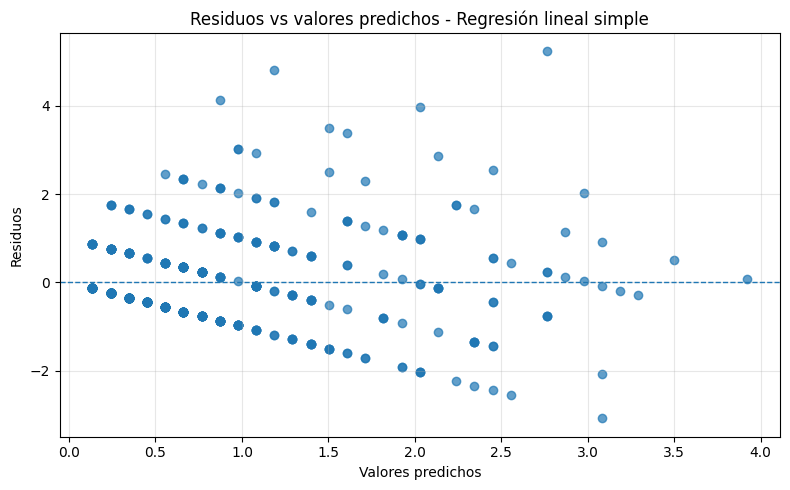

Gráfica guardada en: resultados_etapa_7\heterocedasticidad_residuos_rls.png


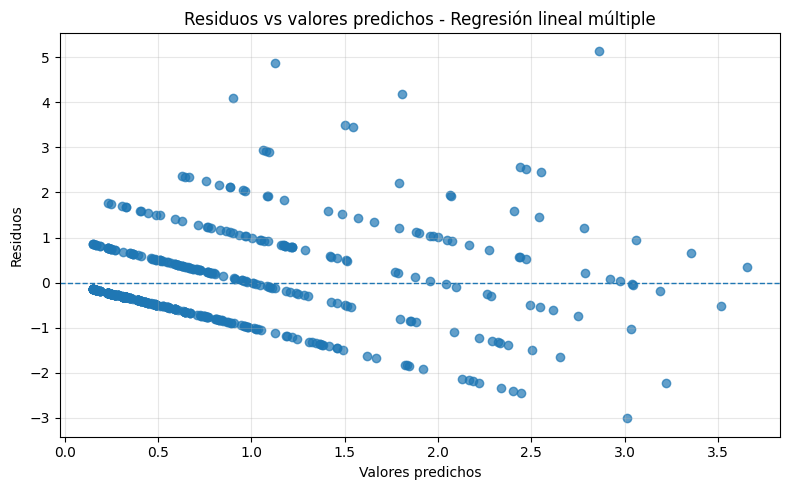

Gráfica guardada en: resultados_etapa_7\heterocedasticidad_residuos_rlm.png


In [21]:
# ------------------------------------------------------------
# 4. Pruebas para ambos modelos
# ------------------------------------------------------------

hetero_rls = pruebas_heterocedasticidad(
    modelo_rls_het,
    "Regresión lineal simple"
)

hetero_rlm = pruebas_heterocedasticidad(
    modelo_rlm_het,
    "Regresión lineal múltiple"
)

resultados_hetero = pd.concat(
    [hetero_rls, hetero_rlm],
    ignore_index=True
)

print("Resultados de pruebas de heterocedasticidad")
display(resultados_hetero)


# ------------------------------------------------------------
# 5. Modelos con errores robustos HC3
# ------------------------------------------------------------

modelo_rls_robusto = modelo_rls_het.get_robustcov_results(cov_type="HC3")
modelo_rlm_robusto = modelo_rlm_het.get_robustcov_results(cov_type="HC3")

print("Modelo RLS con errores robustos HC3")
print(modelo_rls_robusto.summary())

print("\nModelo RLM con errores robustos HC3")
print(modelo_rlm_robusto.summary())


# ------------------------------------------------------------
# 6. Tablas de coeficientes originales y robustos
# ------------------------------------------------------------

tabla_rls_ols = tabla_coeficientes_modelo(
    modelo_rls_het,
    "Regresión lineal simple",
    "OLS"
)

tabla_rls_robusto = tabla_coeficientes_modelo(
    modelo_rls_robusto,
    "Regresión lineal simple",
    "Robusto HC3"
)

tabla_rlm_ols = tabla_coeficientes_modelo(
    modelo_rlm_het,
    "Regresión lineal múltiple",
    "OLS"
)

tabla_rlm_robusto = tabla_coeficientes_modelo(
    modelo_rlm_robusto,
    "Regresión lineal múltiple",
    "Robusto HC3"
)

tabla_coeficientes_hetero = pd.concat(
    [
        tabla_rls_ols,
        tabla_rls_robusto,
        tabla_rlm_ols,
        tabla_rlm_robusto
    ],
    ignore_index=True
)

print("Coeficientes OLS vs errores robustos")
display(tabla_coeficientes_hetero)


# ------------------------------------------------------------
# 7. Comparación directa de errores estándar y p-valores
# ------------------------------------------------------------

comparacion_rls = comparar_errores(
    modelo_rls_het,
    modelo_rls_robusto,
    "Regresión lineal simple"
)

comparacion_rlm = comparar_errores(
    modelo_rlm_het,
    modelo_rlm_robusto,
    "Regresión lineal múltiple"
)

comparacion_errores = pd.concat(
    [comparacion_rls, comparacion_rlm],
    ignore_index=True
)

print("Comparación de errores estándar y p-valores")
display(comparacion_errores)


# ------------------------------------------------------------
# 8. Gráfica residuos vs predichos - RLS
# ------------------------------------------------------------

df_graf_rls = pd.DataFrame({
    "predichos": modelo_rls_het.fittedvalues,
    "residuos": modelo_rls_het.resid
})

plt.figure(figsize=(8, 5))
plt.scatter(df_graf_rls["predichos"], df_graf_rls["residuos"], alpha=0.7)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Residuos vs valores predichos - Regresión lineal simple")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.grid(alpha=0.3)
plt.tight_layout()

ruta_residuos_rls = OUT_DIR_7 / "heterocedasticidad_residuos_rls.png"
plt.savefig(ruta_residuos_rls, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_residuos_rls}")


# ------------------------------------------------------------
# 9. Gráfica residuos vs predichos - RLM
# ------------------------------------------------------------

df_graf_rlm = pd.DataFrame({
    "predichos": modelo_rlm_het.fittedvalues,
    "residuos": modelo_rlm_het.resid
})

plt.figure(figsize=(8, 5))
plt.scatter(df_graf_rlm["predichos"], df_graf_rlm["residuos"], alpha=0.7)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Residuos vs valores predichos - Regresión lineal múltiple")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.grid(alpha=0.3)
plt.tight_layout()

ruta_residuos_rlm = OUT_DIR_7 / "heterocedasticidad_residuos_rlm.png"
plt.savefig(ruta_residuos_rlm, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_residuos_rlm}")

In [22]:
# ------------------------------------------------------------
# 10. Conclusión con base en pruebas
# ------------------------------------------------------------

def conclusion_hetero(tabla_resultados, nombre_modelo):
    sub = tabla_resultados[tabla_resultados["modelo"] == nombre_modelo]
    
    existe_hetero = (sub["p_valor_lm"] < 0.05).any()
    
    if existe_hetero:
        return (
            f"En el modelo {nombre_modelo} se detecta evidencia de heterocedasticidad "
            f"al menos en una de las pruebas aplicadas. Por ello, se recomienda interpretar "
            f"los resultados utilizando errores estándar robustos HC3."
        )
    else:
        return (
            f"En el modelo {nombre_modelo} no se detecta evidencia estadística suficiente "
            f"de heterocedasticidad al 5% de significancia. Los errores estándar OLS "
            f"pueden considerarse adecuados bajo este diagnóstico."
        )


conclusion_rls = conclusion_hetero(
    resultados_hetero,
    "Regresión lineal simple"
)

conclusion_rlm = conclusion_hetero(
    resultados_hetero,
    "Regresión lineal múltiple"
)

print(conclusion_rls)
print(conclusion_rlm)


# ------------------------------------------------------------
# 11. Guardar resultados en Excel
# ------------------------------------------------------------

ruta_excel_hetero = OUT_DIR_7 / "resultados_heterocedasticidad.xlsx"

with pd.ExcelWriter(ruta_excel_hetero, engine="openpyxl") as writer:
    resultados_hetero.to_excel(writer, sheet_name="pruebas_hetero", index=False)
    tabla_coeficientes_hetero.to_excel(writer, sheet_name="coeficientes_ols_robustos", index=False)
    comparacion_errores.to_excel(writer, sheet_name="comparacion_errores", index=False)
    df_graf_rls.to_excel(writer, sheet_name="residuos_rls", index=False)
    df_graf_rlm.to_excel(writer, sheet_name="residuos_rlm", index=False)

print(f"Archivo Excel guardado en: {ruta_excel_hetero}")


# ------------------------------------------------------------
# 12. Guardar resúmenes en TXT
# ------------------------------------------------------------

ruta_txt_hetero = OUT_DIR_7 / "resumen_heterocedasticidad.txt"

with open(ruta_txt_hetero, "w", encoding="utf-8") as f:
    f.write("ETAPA 7. HETEROCEDASTICIDAD\n")
    f.write("=" * 70 + "\n\n")
    
    f.write("Pruebas de heterocedasticidad:\n")
    f.write(resultados_hetero.to_string(index=False))
    f.write("\n\n")
    
    f.write("Conclusiones:\n")
    f.write(conclusion_rls + "\n")
    f.write(conclusion_rlm + "\n\n")
    
    f.write("=" * 70 + "\n\n")
    f.write("Resumen modelo RLS OLS:\n")
    f.write(str(modelo_rls_het.summary()))
    f.write("\n\n")
    
    f.write("Resumen modelo RLS con errores robustos HC3:\n")
    f.write(str(modelo_rls_robusto.summary()))
    f.write("\n\n")
    
    f.write("=" * 70 + "\n\n")
    f.write("Resumen modelo RLM OLS:\n")
    f.write(str(modelo_rlm_het.summary()))
    f.write("\n\n")
    
    f.write("Resumen modelo RLM con errores robustos HC3:\n")
    f.write(str(modelo_rlm_robusto.summary()))

print(f"Resumen TXT guardado en: {ruta_txt_hetero}")


# ------------------------------------------------------------
# 13. Síntesis de resultados para el reporte
# ------------------------------------------------------------

print("Resumen para el reporte")
print("---------------------------------------------")

display(resultados_hetero)

print("\nConclusión RLS:")
print(conclusion_rls)

print("\nConclusión RLM:")
print(conclusion_rlm)

print("\nComparación de errores estándar y p-valores:")
display(comparacion_errores)

En el modelo Regresión lineal simple se detecta evidencia de heterocedasticidad al menos en una de las pruebas aplicadas. Por ello, se recomienda interpretar los resultados utilizando errores estándar robustos HC3.
En el modelo Regresión lineal múltiple se detecta evidencia de heterocedasticidad al menos en una de las pruebas aplicadas. Por ello, se recomienda interpretar los resultados utilizando errores estándar robustos HC3.
Archivo Excel guardado en: resultados_etapa_7\resultados_heterocedasticidad.xlsx
Resumen TXT guardado en: resultados_etapa_7\resumen_heterocedasticidad.txt
Resumen para el reporte
---------------------------------------------


,modelo,prueba,estadistico_lm,p_valor_lm,estadistico_f,p_valor_f,decision_5
0,Regresión lineal simple,Breusch-Pagan,54.687483,1.413034e-13,60.866485,3.381381e-14,Rechazar H0: existe evidencia de heterocedasti...
1,Regresión lineal simple,White,61.448060,4.536525e-14,34.631662,7.650539e-15,Rechazar H0: existe evidencia de heterocedasti...
2,Regresión lineal múltiple,Breusch-Pagan,57.488189,3.285477e-13,32.123110,7.059571e-14,Rechazar H0: existe evidencia de heterocedasti...
3,Regresión lineal múltiple,White,65.496378,8.841447e-13,14.810260,1.374331e-13,Rechazar H0: existe evidencia de heterocedasti...



Conclusión RLS:
En el modelo Regresión lineal simple se detecta evidencia de heterocedasticidad al menos en una de las pruebas aplicadas. Por ello, se recomienda interpretar los resultados utilizando errores estándar robustos HC3.

Conclusión RLM:
En el modelo Regresión lineal múltiple se detecta evidencia de heterocedasticidad al menos en una de las pruebas aplicadas. Por ello, se recomienda interpretar los resultados utilizando errores estándar robustos HC3.

Comparación de errores estándar y p-valores:


,modelo,variable,coeficiente_ols,error_estandar_ols,p_valor_ols,error_estandar_robusto_HC3,p_valor_robusto_HC3,cambio_error_estandar,cambio_p_valor
0,Regresión lineal simple,const,0.135117,0.061193,2.767748e-02,0.048313,5.354710e-03,-0.012880,-2.232277e-02
1,Regresión lineal simple,hospitalizaciones_diarias,0.105195,0.006396,3.153216e-49,0.008702,8.111460e-30,0.002306,8.111460e-30
2,Regresión lineal múltiple,const,0.149019,0.061211,1.524836e-02,0.049715,2.852816e-03,-0.011496,-1.239554e-02
3,Regresión lineal múltiple,hospitalizaciones_diarias,0.061698,0.019519,1.664813e-03,0.026926,2.234407e-02,0.007407,2.067926e-02
4,Regresión lineal múltiple,casos_diarios,0.018937,0.008033,1.877093e-02,0.011157,9.022312e-02,0.003124,7.145219e-02


## **ETAPA 8. AUTOCORRELACIÓN**

In [23]:
# ============================================================
# ETAPA 8. AUTOCORRELACIÓN
# Pruebas de Durbin-Watson y Breusch-Godfrey
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from IPython.display import display
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

# Carpeta de salida para esta etapa
OUT_DIR_8 = Path("resultados_etapa_8")
OUT_DIR_8.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 1. Modelo de regresión lineal simple
# Defunciones diarias ~ Hospitalizaciones diarias
# ------------------------------------------------------------

df_rls_auto = df_ts[[
    "defunciones_diarias",
    "hospitalizaciones_diarias"
]].copy()

for col in df_rls_auto.columns:
    df_rls_auto[col] = pd.to_numeric(df_rls_auto[col], errors="coerce")

df_rls_auto = df_rls_auto.dropna()

Y_rls_auto = df_rls_auto["defunciones_diarias"]
X_rls_auto = df_rls_auto[["hospitalizaciones_diarias"]]
X_rls_auto = sm.add_constant(X_rls_auto)

modelo_rls_auto = sm.OLS(Y_rls_auto, X_rls_auto).fit()

print(modelo_rls_auto.summary())


# ------------------------------------------------------------
# 2. Modelo de regresión lineal múltiple
# Defunciones diarias ~ Hospitalizaciones diarias + Casos diarios
# ------------------------------------------------------------

df_rlm_auto = df_ts[[
    "defunciones_diarias",
    "hospitalizaciones_diarias",
    "casos_diarios"
]].copy()

for col in df_rlm_auto.columns:
    df_rlm_auto[col] = pd.to_numeric(df_rlm_auto[col], errors="coerce")

df_rlm_auto = df_rlm_auto.dropna()

Y_rlm_auto = df_rlm_auto["defunciones_diarias"]
X_rlm_auto = df_rlm_auto[[
    "hospitalizaciones_diarias",
    "casos_diarios"
]]
X_rlm_auto = sm.add_constant(X_rlm_auto)

modelo_rlm_auto = sm.OLS(Y_rlm_auto, X_rlm_auto).fit()

print(modelo_rlm_auto.summary())


# ------------------------------------------------------------
# 3. Funciones auxiliares
# ------------------------------------------------------------

def interpretar_durbin_watson(dw):
    """
    Interpretación práctica del estadístico Durbin-Watson.
    DW cercano a 2: no autocorrelación.
    DW menor a 2: posible autocorrelación positiva.
    DW mayor a 2: posible autocorrelación negativa.
    """
    if dw < 1.5:
        return "Posible autocorrelación positiva"
    elif dw <= 2.5:
        return "No se observa autocorrelación importante"
    else:
        return "Posible autocorrelación negativa"


def pruebas_autocorrelacion(modelo, nombre_modelo, max_lags=7):
    """
    Aplica Durbin-Watson y Breusch-Godfrey para varios rezagos.
    """
    residuos = modelo.resid
    
    # Durbin-Watson
    dw = durbin_watson(residuos)
    
    filas = []
    
    filas.append({
        "modelo": nombre_modelo,
        "prueba": "Durbin-Watson",
        "rezagos": 1,
        "estadistico": dw,
        "p_valor": np.nan,
        "decision_5": interpretar_durbin_watson(dw)
    })
    
    # Breusch-Godfrey para rezagos 1 a max_lags
    for lag in range(1, max_lags + 1):
        bg = acorr_breusch_godfrey(modelo, nlags=lag)
        
        filas.append({
            "modelo": nombre_modelo,
            "prueba": "Breusch-Godfrey",
            "rezagos": lag,
            "estadistico": bg[0],
            "p_valor": bg[1],
            "decision_5": (
                "Rechazar H0: existe autocorrelación"
                if bg[1] < 0.05
                else "No rechazar H0: no hay evidencia suficiente"
            )
        })
    
    return pd.DataFrame(filas)


def crear_tabla_residuos(modelo, nombre_modelo):
    """
    Crea tabla con predicciones, residuos y residuos rezagados.
    """
    tabla = pd.DataFrame({
        "modelo": nombre_modelo,
        "predichos": modelo.fittedvalues,
        "residuos": modelo.resid
    })
    
    tabla["residuos_lag1"] = tabla["residuos"].shift(1)
    tabla["residuos_lag7"] = tabla["residuos"].shift(7)
    
    return tabla

                             OLS Regression Results                            
Dep. Variable:     defunciones_diarias   R-squared:                       0.343
Model:                             OLS   Adj. R-squared:                  0.341
Method:                  Least Squares   F-statistic:                     270.5
Date:                 Wed, 17 Jun 2026   Prob (F-statistic):           3.15e-49
Time:                         22:31:53   Log-Likelihood:                -734.81
No. Observations:                  521   AIC:                             1474.
Df Residuals:                      519   BIC:                             1482.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

Resultados de autocorrelación


,modelo,prueba,rezagos,estadistico,p_valor,decision_5
0,Regresión lineal simple,Durbin-Watson,1,1.982318,NaN,No se observa autocorrelación importante
1,Regresión lineal simple,Breusch-Godfrey,1,0.030879,0.860512,No rechazar H0: no hay evidencia suficiente
2,Regresión lineal simple,Breusch-Godfrey,2,2.052629,0.358325,No rechazar H0: no hay evidencia suficiente
3,Regresión lineal simple,Breusch-Godfrey,3,4.178031,0.242871,No rechazar H0: no hay evidencia suficiente
4,Regresión lineal simple,Breusch-Godfrey,4,7.206020,0.125393,No rechazar H0: no hay evidencia suficiente
5,Regresión lineal simple,Breusch-Godfrey,5,7.409178,0.191944,No rechazar H0: no hay evidencia suficiente
6,Regresión lineal simple,Breusch-Godfrey,6,8.998164,0.173681,No rechazar H0: no hay evidencia suficiente
7,Regresión lineal simple,Breusch-Godfrey,7,12.208533,0.093906,No rechazar H0: no hay evidencia suficiente
8,Regresión lineal múltiple,Durbin-Watson,1,1.953387,NaN,No se observa autocorrelación importante
9,Regresión lineal múltiple,Breusch-Godfrey,1,0.260237,0.609957,No rechazar H0: no hay evidencia suficiente


,modelo,predichos,residuos,residuos_lag1,residuos_lag7
0,Regresión lineal simple,0.661093,-0.661093,NaN,NaN
1,Regresión lineal simple,0.345507,-0.345507,-0.661093,NaN
2,Regresión lineal simple,0.450703,-0.450703,-0.345507,NaN
3,Regresión lineal simple,0.661093,-0.661093,-0.450703,NaN
4,Regresión lineal simple,0.450703,-0.450703,-0.661093,NaN


,modelo,predichos,residuos,residuos_lag1,residuos_lag7
0,Regresión lineal múltiple,0.590067,-0.590067,NaN,NaN
1,Regresión lineal múltiple,0.310288,-0.310288,-0.590067,NaN
2,Regresión lineal múltiple,0.466672,-0.466672,-0.310288,NaN
3,Regresión lineal múltiple,0.590067,-0.590067,-0.466672,NaN
4,Regresión lineal múltiple,0.485609,-0.485609,-0.590067,NaN


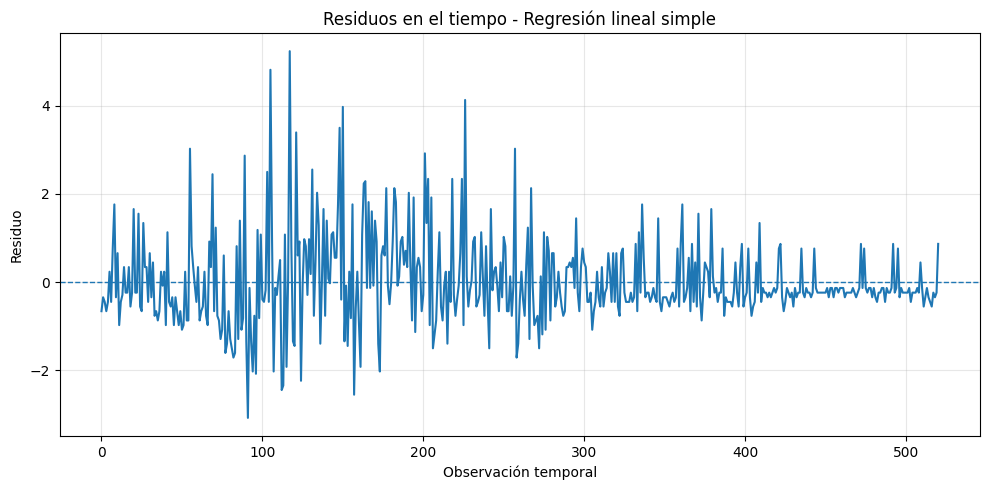

Gráfica guardada en: resultados_etapa_8\autocorrelacion_residuos_tiempo_rls.png


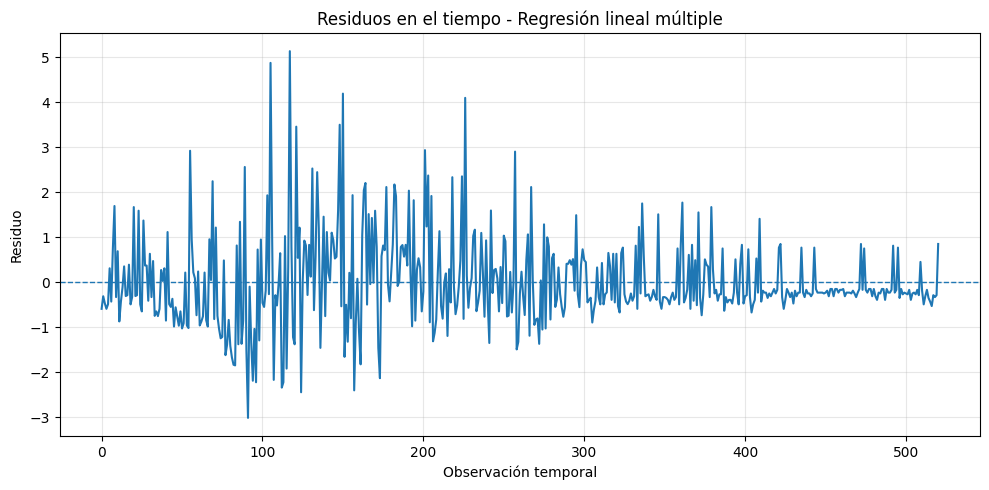

Gráfica guardada en: resultados_etapa_8\autocorrelacion_residuos_tiempo_rlm.png


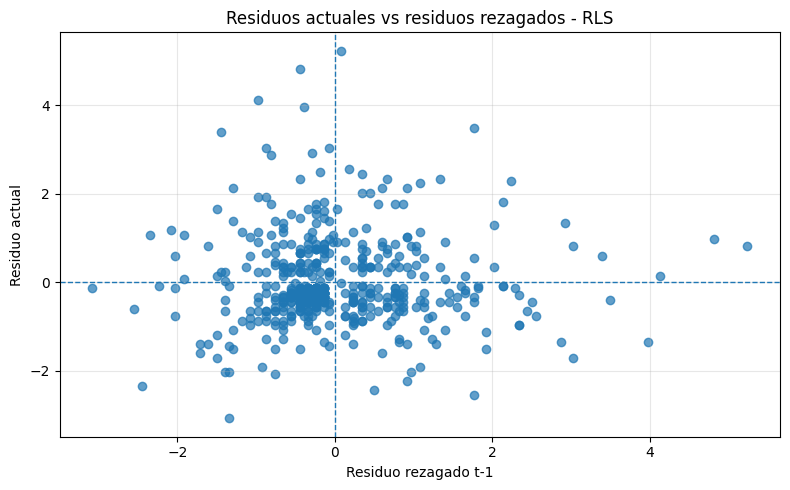

Gráfica guardada en: resultados_etapa_8\autocorrelacion_residuos_lag1_rls.png


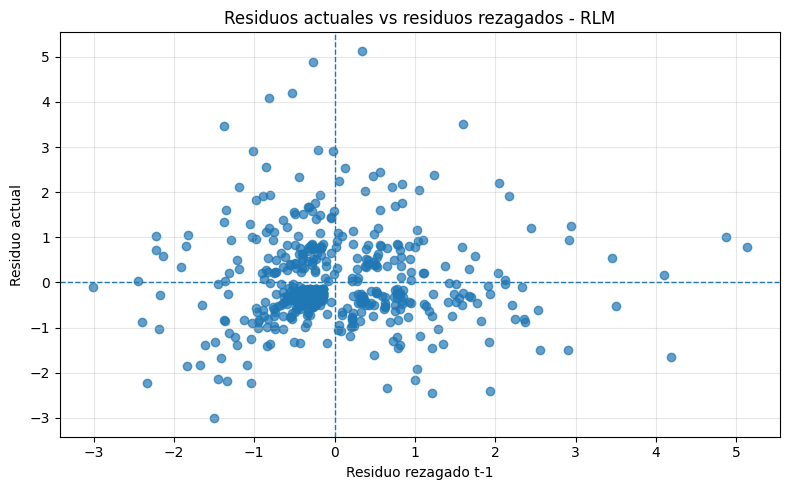

Gráfica guardada en: resultados_etapa_8\autocorrelacion_residuos_lag1_rlm.png


In [24]:
# ------------------------------------------------------------
# 4. Aplicar pruebas a ambos modelos
# ------------------------------------------------------------

auto_rls = pruebas_autocorrelacion(
    modelo_rls_auto,
    "Regresión lineal simple",
    max_lags=7
)

auto_rlm = pruebas_autocorrelacion(
    modelo_rlm_auto,
    "Regresión lineal múltiple",
    max_lags=7
)

resultados_autocorrelacion = pd.concat(
    [auto_rls, auto_rlm],
    ignore_index=True
)

print("Resultados de autocorrelación")
display(resultados_autocorrelacion)


# ------------------------------------------------------------
# 5. Crear tablas de residuos
# ------------------------------------------------------------

residuos_rls = crear_tabla_residuos(
    modelo_rls_auto,
    "Regresión lineal simple"
)

residuos_rlm = crear_tabla_residuos(
    modelo_rlm_auto,
    "Regresión lineal múltiple"
)

display(residuos_rls.head())
display(residuos_rlm.head())


# ------------------------------------------------------------
# 6. Gráfica de residuos en el tiempo - RLS
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(residuos_rls.index, residuos_rls["residuos"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Residuos en el tiempo - Regresión lineal simple")
plt.xlabel("Observación temporal")
plt.ylabel("Residuo")
plt.grid(alpha=0.3)
plt.tight_layout()

ruta_residuos_tiempo_rls = OUT_DIR_8 / "autocorrelacion_residuos_tiempo_rls.png"
plt.savefig(ruta_residuos_tiempo_rls, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_residuos_tiempo_rls}")


# ------------------------------------------------------------
# 7. Gráfica de residuos en el tiempo - RLM
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(residuos_rlm.index, residuos_rlm["residuos"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Residuos en el tiempo - Regresión lineal múltiple")
plt.xlabel("Observación temporal")
plt.ylabel("Residuo")
plt.grid(alpha=0.3)
plt.tight_layout()

ruta_residuos_tiempo_rlm = OUT_DIR_8 / "autocorrelacion_residuos_tiempo_rlm.png"
plt.savefig(ruta_residuos_tiempo_rlm, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_residuos_tiempo_rlm}")


# ------------------------------------------------------------
# 8. Dispersión residuos vs residuos rezagados - RLS
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.scatter(
    residuos_rls["residuos_lag1"],
    residuos_rls["residuos"],
    alpha=0.7
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Residuos actuales vs residuos rezagados - RLS")
plt.xlabel("Residuo rezagado t-1")
plt.ylabel("Residuo actual")
plt.grid(alpha=0.3)
plt.tight_layout()

ruta_res_lag_rls = OUT_DIR_8 / "autocorrelacion_residuos_lag1_rls.png"
plt.savefig(ruta_res_lag_rls, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_res_lag_rls}")


# ------------------------------------------------------------
# 9. Dispersión residuos vs residuos rezagados - RLM
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.scatter(
    residuos_rlm["residuos_lag1"],
    residuos_rlm["residuos"],
    alpha=0.7
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Residuos actuales vs residuos rezagados - RLM")
plt.xlabel("Residuo rezagado t-1")
plt.ylabel("Residuo actual")
plt.grid(alpha=0.3)
plt.tight_layout()

ruta_res_lag_rlm = OUT_DIR_8 / "autocorrelacion_residuos_lag1_rlm.png"
plt.savefig(ruta_res_lag_rlm, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_res_lag_rlm}")

In [25]:
# ------------------------------------------------------------
# 10. Conclusión de resultados
# ------------------------------------------------------------

def conclusion_autocorrelacion(tabla_resultados, nombre_modelo):
    sub = tabla_resultados[
        (tabla_resultados["modelo"] == nombre_modelo) &
        (tabla_resultados["prueba"] == "Breusch-Godfrey")
    ]
    
    existe_auto = (sub["p_valor"] < 0.05).any()
    
    dw_row = tabla_resultados[
        (tabla_resultados["modelo"] == nombre_modelo) &
        (tabla_resultados["prueba"] == "Durbin-Watson")
    ].iloc[0]
    
    dw = dw_row["estadistico"]
    interp_dw = dw_row["decision_5"]
    
    if existe_auto:
        return (
            f"En el modelo {nombre_modelo}, el estadístico Durbin-Watson fue {dw:.4f}, "
            f"lo que sugiere: {interp_dw}. Además, la prueba de Breusch-Godfrey "
            f"rechaza la hipótesis nula en al menos un rezago, por lo que existe evidencia "
            f"de autocorrelación en los residuos. Se recomienda considerar modelos con rezagos "
            f"o modelos de series de tiempo."
        )
    else:
        return (
            f"En el modelo {nombre_modelo}, el estadístico Durbin-Watson fue {dw:.4f}, "
            f"lo que sugiere: {interp_dw}. La prueba de Breusch-Godfrey no rechaza la "
            f"hipótesis nula en los rezagos evaluados, por lo que no se detecta evidencia "
            f"suficiente de autocorrelación al 5%."
        )


conclusion_auto_rls = conclusion_autocorrelacion(
    resultados_autocorrelacion,
    "Regresión lineal simple"
)

conclusion_auto_rlm = conclusion_autocorrelacion(
    resultados_autocorrelacion,
    "Regresión lineal múltiple"
)

print(conclusion_auto_rls)
print(conclusion_auto_rlm)


# ------------------------------------------------------------
# 11. Guardar resultados en Excel
# ------------------------------------------------------------

ruta_excel_auto = OUT_DIR_8 / "resultados_autocorrelacion.xlsx"

with pd.ExcelWriter(ruta_excel_auto, engine="openpyxl") as writer:
    resultados_autocorrelacion.to_excel(
        writer,
        sheet_name="pruebas_autocorrelacion",
        index=False
    )
    
    residuos_rls.to_excel(
        writer,
        sheet_name="residuos_rls",
        index=False
    )
    
    residuos_rlm.to_excel(
        writer,
        sheet_name="residuos_rlm",
        index=False
    )

print(f"Archivo Excel guardado en: {ruta_excel_auto}")


# ------------------------------------------------------------
# 12. Guardar resumen en TXT
# ------------------------------------------------------------

ruta_txt_auto = OUT_DIR_8 / "resumen_autocorrelacion.txt"

with open(ruta_txt_auto, "w", encoding="utf-8") as f:
    f.write("ETAPA 8. AUTOCORRELACIÓN\n")
    f.write("=" * 70 + "\n\n")
    
    f.write("Pruebas aplicadas:\n")
    f.write("1. Durbin-Watson\n")
    f.write("2. Breusch-Godfrey\n\n")
    
    f.write("Resultados:\n")
    f.write(resultados_autocorrelacion.to_string(index=False))
    f.write("\n\n")
    
    f.write("Conclusiones:\n")
    f.write(conclusion_auto_rls + "\n")
    f.write(conclusion_auto_rlm + "\n\n")
    
    f.write("=" * 70 + "\n\n")
    f.write("Resumen modelo RLS:\n")
    f.write(str(modelo_rls_auto.summary()))
    f.write("\n\n")
    
    f.write("Resumen modelo RLM:\n")
    f.write(str(modelo_rlm_auto.summary()))

print(f"Resumen TXT guardado en: {ruta_txt_auto}")


# ------------------------------------------------------------
# 13. Síntesis de resultados para el reporte
# ------------------------------------------------------------

print("Resumen para el reporte")
print("---------------------------------------------")

display(resultados_autocorrelacion)

print("\nConclusión RLS:")
print(conclusion_auto_rls)

print("\nConclusión RLM:")
print(conclusion_auto_rlm)

En el modelo Regresión lineal simple, el estadístico Durbin-Watson fue 1.9823, lo que sugiere: No se observa autocorrelación importante. La prueba de Breusch-Godfrey no rechaza la hipótesis nula en los rezagos evaluados, por lo que no se detecta evidencia suficiente de autocorrelación al 5%.
En el modelo Regresión lineal múltiple, el estadístico Durbin-Watson fue 1.9534, lo que sugiere: No se observa autocorrelación importante. La prueba de Breusch-Godfrey no rechaza la hipótesis nula en los rezagos evaluados, por lo que no se detecta evidencia suficiente de autocorrelación al 5%.
Archivo Excel guardado en: resultados_etapa_8\resultados_autocorrelacion.xlsx
Resumen TXT guardado en: resultados_etapa_8\resumen_autocorrelacion.txt
Resumen para el reporte
---------------------------------------------


,modelo,prueba,rezagos,estadistico,p_valor,decision_5
0,Regresión lineal simple,Durbin-Watson,1,1.982318,NaN,No se observa autocorrelación importante
1,Regresión lineal simple,Breusch-Godfrey,1,0.030879,0.860512,No rechazar H0: no hay evidencia suficiente
2,Regresión lineal simple,Breusch-Godfrey,2,2.052629,0.358325,No rechazar H0: no hay evidencia suficiente
3,Regresión lineal simple,Breusch-Godfrey,3,4.178031,0.242871,No rechazar H0: no hay evidencia suficiente
4,Regresión lineal simple,Breusch-Godfrey,4,7.206020,0.125393,No rechazar H0: no hay evidencia suficiente
5,Regresión lineal simple,Breusch-Godfrey,5,7.409178,0.191944,No rechazar H0: no hay evidencia suficiente
6,Regresión lineal simple,Breusch-Godfrey,6,8.998164,0.173681,No rechazar H0: no hay evidencia suficiente
7,Regresión lineal simple,Breusch-Godfrey,7,12.208533,0.093906,No rechazar H0: no hay evidencia suficiente
8,Regresión lineal múltiple,Durbin-Watson,1,1.953387,NaN,No se observa autocorrelación importante
9,Regresión lineal múltiple,Breusch-Godfrey,1,0.260237,0.609957,No rechazar H0: no hay evidencia suficiente



Conclusión RLS:
En el modelo Regresión lineal simple, el estadístico Durbin-Watson fue 1.9823, lo que sugiere: No se observa autocorrelación importante. La prueba de Breusch-Godfrey no rechaza la hipótesis nula en los rezagos evaluados, por lo que no se detecta evidencia suficiente de autocorrelación al 5%.

Conclusión RLM:
En el modelo Regresión lineal múltiple, el estadístico Durbin-Watson fue 1.9534, lo que sugiere: No se observa autocorrelación importante. La prueba de Breusch-Godfrey no rechaza la hipótesis nula en los rezagos evaluados, por lo que no se detecta evidencia suficiente de autocorrelación al 5%.


## **ETAPA 9. NORMALIDAD**

In [26]:
# ============================================================
# ETAPA 9. NORMALIDAD
# Pruebas de Jarque-Bera, Shapiro-Wilk y análisis de residuos
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from IPython.display import display
from scipy.stats import jarque_bera, shapiro, skew, kurtosis, probplot

# Carpeta de salida para esta etapa
OUT_DIR_9 = Path("resultados_etapa_9")
OUT_DIR_9.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 1. Modelo de regresión lineal simple
# Defunciones diarias ~ Hospitalizaciones diarias
# ------------------------------------------------------------

df_rls_norm = df_ts[[
    "defunciones_diarias",
    "hospitalizaciones_diarias"
]].copy()

for col in df_rls_norm.columns:
    df_rls_norm[col] = pd.to_numeric(df_rls_norm[col], errors="coerce")

df_rls_norm = df_rls_norm.dropna()

Y_rls_norm = df_rls_norm["defunciones_diarias"]
X_rls_norm = df_rls_norm[["hospitalizaciones_diarias"]]
X_rls_norm = sm.add_constant(X_rls_norm)

modelo_rls_norm = sm.OLS(Y_rls_norm, X_rls_norm).fit()

print(modelo_rls_norm.summary())


# ------------------------------------------------------------
# 2. Modelo de regresión lineal múltiple
# Defunciones diarias ~ Hospitalizaciones diarias + Casos diarios
# ------------------------------------------------------------

df_rlm_norm = df_ts[[
    "defunciones_diarias",
    "hospitalizaciones_diarias",
    "casos_diarios"
]].copy()

for col in df_rlm_norm.columns:
    df_rlm_norm[col] = pd.to_numeric(df_rlm_norm[col], errors="coerce")

df_rlm_norm = df_rlm_norm.dropna()

Y_rlm_norm = df_rlm_norm["defunciones_diarias"]
X_rlm_norm = df_rlm_norm[[
    "hospitalizaciones_diarias",
    "casos_diarios"
]]
X_rlm_norm = sm.add_constant(X_rlm_norm)

modelo_rlm_norm = sm.OLS(Y_rlm_norm, X_rlm_norm).fit()

print(modelo_rlm_norm.summary())


# ------------------------------------------------------------
# 3. Funciones auxiliares
# ------------------------------------------------------------

def pruebas_normalidad(residuos, nombre_modelo):
    """
    Aplica Jarque-Bera y Shapiro-Wilk a los residuos.
    """
    residuos = pd.Series(residuos).dropna()
    
    # Jarque-Bera
    jb_stat, jb_p = jarque_bera(residuos)
    
    # Shapiro-Wilk
    # Nota: Shapiro puede ser muy sensible con muestras grandes.
    # Si n > 5000, se toma una muestra de 5000 para evitar advertencias.
    if len(residuos) > 5000:
        residuos_shapiro = residuos.sample(5000, random_state=42)
    else:
        residuos_shapiro = residuos
    
    shapiro_stat, shapiro_p = shapiro(residuos_shapiro)
    
    resultados = pd.DataFrame({
        "modelo": [nombre_modelo, nombre_modelo],
        "prueba": ["Jarque-Bera", "Shapiro-Wilk"],
        "estadistico": [jb_stat, shapiro_stat],
        "p_valor": [jb_p, shapiro_p],
        "n_residuos": [len(residuos), len(residuos_shapiro)],
        "decision_5": [
            "Rechazar H0: residuos no normales" if jb_p < 0.05 else "No rechazar H0: no hay evidencia suficiente contra normalidad",
            "Rechazar H0: residuos no normales" if shapiro_p < 0.05 else "No rechazar H0: no hay evidencia suficiente contra normalidad"
        ]
    })
    
    return resultados


def estadisticos_residuos(residuos, nombre_modelo):
    """
    Calcula estadísticos descriptivos de los residuos.
    """
    residuos = pd.Series(residuos).dropna()
    
    tabla = pd.DataFrame({
        "modelo": [nombre_modelo],
        "n": [len(residuos)],
        "media": [residuos.mean()],
        "mediana": [residuos.median()],
        "desviacion_estandar": [residuos.std()],
        "minimo": [residuos.min()],
        "maximo": [residuos.max()],
        "asimetria": [skew(residuos)],
        "curtosis": [kurtosis(residuos)]
    })
    
    return tabla


def conclusion_normalidad(tabla_resultados, nombre_modelo):
    """
    Genera una conclusión sobre normalidad.
    """
    sub = tabla_resultados[tabla_resultados["modelo"] == nombre_modelo]
    
    rechazos = (sub["p_valor"] < 0.05).sum()
    
    if rechazos == 0:
        return (
            f"En el modelo {nombre_modelo}, las pruebas aplicadas no rechazan la hipótesis "
            f"de normalidad al 5% de significancia. Por lo tanto, no se encuentra evidencia "
            f"estadística suficiente para afirmar que los residuos se alejan de una distribución normal."
        )
    elif rechazos == len(sub):
        return (
            f"En el modelo {nombre_modelo}, las pruebas Jarque-Bera y Shapiro-Wilk rechazan "
            f"la hipótesis de normalidad al 5% de significancia. Esto sugiere que los residuos "
            f"no siguen una distribución normal."
        )
    else:
        return (
            f"En el modelo {nombre_modelo}, los resultados de normalidad son mixtos. "
            f"Al menos una prueba rechaza la hipótesis de normalidad, por lo que la distribución "
            f"de los residuos debe interpretarse con cautela y complementarse con el análisis gráfico."
        )

                             OLS Regression Results                            
Dep. Variable:     defunciones_diarias   R-squared:                       0.343
Model:                             OLS   Adj. R-squared:                  0.341
Method:                  Least Squares   F-statistic:                     270.5
Date:                 Wed, 17 Jun 2026   Prob (F-statistic):           3.15e-49
Time:                         22:31:55   Log-Likelihood:                -734.81
No. Observations:                  521   AIC:                             1474.
Df Residuals:                      519   BIC:                             1482.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

Resultados de pruebas de normalidad


,modelo,prueba,estadistico,p_valor,n_residuos,decision_5
0,Regresión lineal simple,Jarque-Bera,459.788459,1.439477e-100,521,Rechazar H0: residuos no normales
1,Regresión lineal simple,Shapiro-Wilk,0.907437,2.880999e-17,521,Rechazar H0: residuos no normales
2,Regresión lineal múltiple,Jarque-Bera,465.335269,8.989390e-102,521,Rechazar H0: residuos no normales
3,Regresión lineal múltiple,Shapiro-Wilk,0.908973,4.053113e-17,521,Rechazar H0: residuos no normales


Estadísticos descriptivos de residuos


,modelo,n,media,mediana,desviacion_estandar,minimo,maximo,asimetria,curtosis
0,Regresión lineal simple,521,-2.045708e-16,-0.240312,0.992435,-3.080584,5.235002,1.239533,3.877436
1,Regresión lineal múltiple,521,-1.500186e-15,-0.229653,0.987153,-3.012786,5.134432,1.217086,3.938350


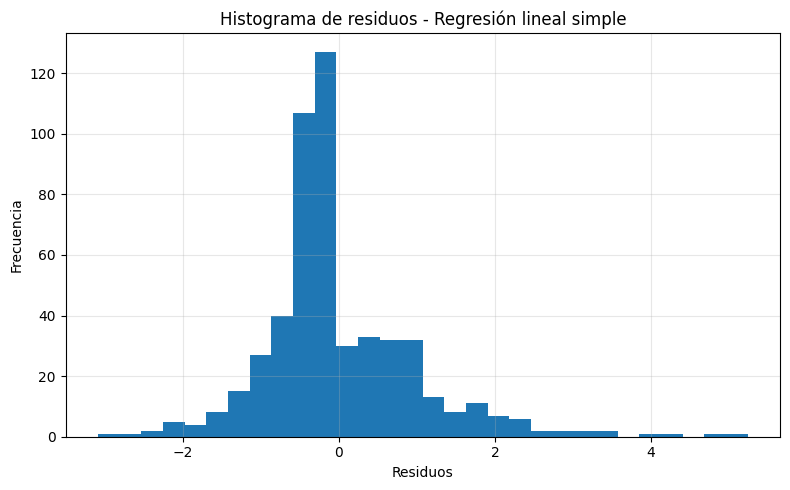

Gráfica guardada en: resultados_etapa_9\normalidad_histograma_residuos_rls.png


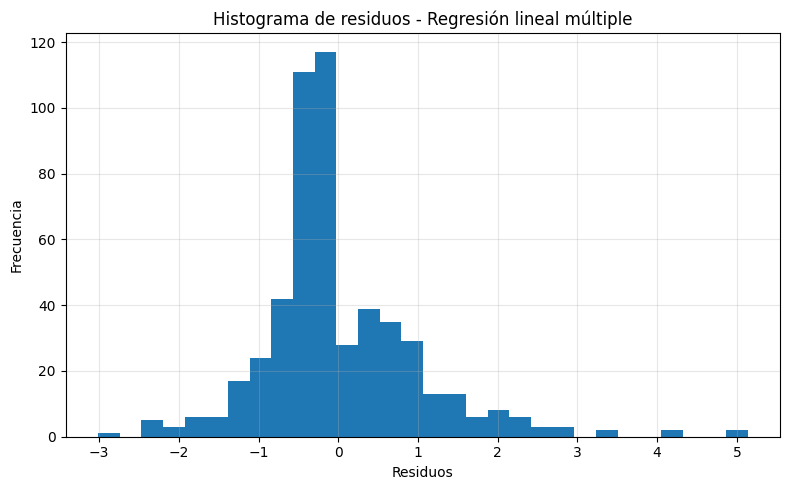

Gráfica guardada en: resultados_etapa_9\normalidad_histograma_residuos_rlm.png


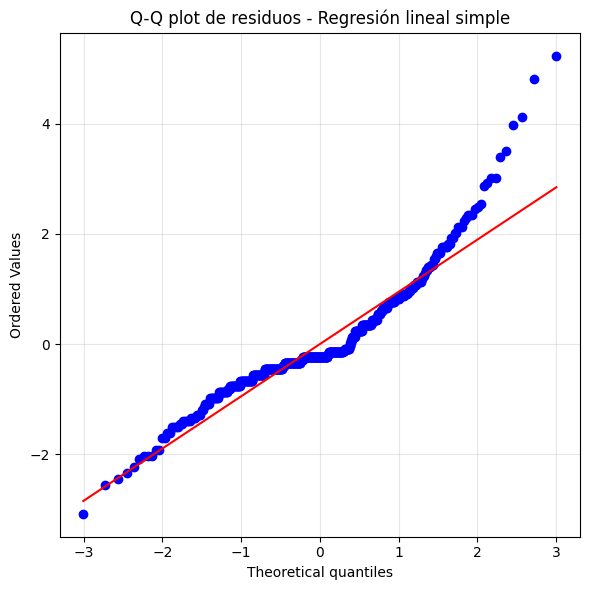

Gráfica guardada en: resultados_etapa_9\normalidad_qqplot_residuos_rls.png


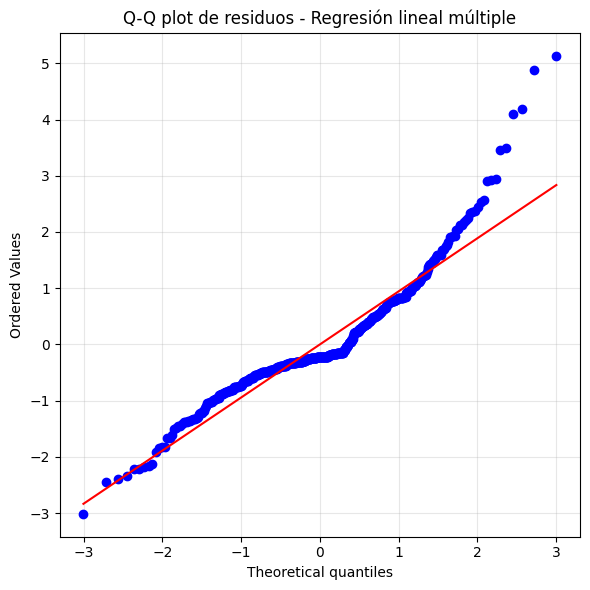

Gráfica guardada en: resultados_etapa_9\normalidad_qqplot_residuos_rlm.png
En el modelo Regresión lineal simple, las pruebas Jarque-Bera y Shapiro-Wilk rechazan la hipótesis de normalidad al 5% de significancia. Esto sugiere que los residuos no siguen una distribución normal.
En el modelo Regresión lineal múltiple, las pruebas Jarque-Bera y Shapiro-Wilk rechazan la hipótesis de normalidad al 5% de significancia. Esto sugiere que los residuos no siguen una distribución normal.


In [27]:
# ------------------------------------------------------------
# 4. Extraer residuos
# ------------------------------------------------------------

residuos_rls_norm = modelo_rls_norm.resid
residuos_rlm_norm = modelo_rlm_norm.resid


# ------------------------------------------------------------
# 5. Pruebas de normalidad
# ------------------------------------------------------------

normalidad_rls = pruebas_normalidad(
    residuos_rls_norm,
    "Regresión lineal simple"
)

normalidad_rlm = pruebas_normalidad(
    residuos_rlm_norm,
    "Regresión lineal múltiple"
)

resultados_normalidad = pd.concat(
    [normalidad_rls, normalidad_rlm],
    ignore_index=True
)

print("Resultados de pruebas de normalidad")
display(resultados_normalidad)


# ------------------------------------------------------------
# 6. Estadísticos descriptivos de residuos
# ------------------------------------------------------------

estad_res_rls = estadisticos_residuos(
    residuos_rls_norm,
    "Regresión lineal simple"
)

estad_res_rlm = estadisticos_residuos(
    residuos_rlm_norm,
    "Regresión lineal múltiple"
)

estadisticos_residuos_norm = pd.concat(
    [estad_res_rls, estad_res_rlm],
    ignore_index=True
)

print("Estadísticos descriptivos de residuos")
display(estadisticos_residuos_norm)


# ------------------------------------------------------------
# 7. Histograma residuos RLS
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.hist(residuos_rls_norm, bins=30)
plt.title("Histograma de residuos - Regresión lineal simple")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.tight_layout()

ruta_hist_rls = OUT_DIR_9 / "normalidad_histograma_residuos_rls.png"
plt.savefig(ruta_hist_rls, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_hist_rls}")


# ------------------------------------------------------------
# 8. Histograma residuos RLM
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.hist(residuos_rlm_norm, bins=30)
plt.title("Histograma de residuos - Regresión lineal múltiple")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.tight_layout()

ruta_hist_rlm = OUT_DIR_9 / "normalidad_histograma_residuos_rlm.png"
plt.savefig(ruta_hist_rlm, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_hist_rlm}")


# ------------------------------------------------------------
# 9. Q-Q plot residuos RLS
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))
probplot(residuos_rls_norm, dist="norm", plot=plt)
plt.title("Q-Q plot de residuos - Regresión lineal simple")
plt.grid(alpha=0.3)
plt.tight_layout()

ruta_qq_rls = OUT_DIR_9 / "normalidad_qqplot_residuos_rls.png"
plt.savefig(ruta_qq_rls, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_qq_rls}")


# ------------------------------------------------------------
# 10. Q-Q plot residuos RLM
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))
probplot(residuos_rlm_norm, dist="norm", plot=plt)
plt.title("Q-Q plot de residuos - Regresión lineal múltiple")
plt.grid(alpha=0.3)
plt.tight_layout()

ruta_qq_rlm = OUT_DIR_9 / "normalidad_qqplot_residuos_rlm.png"
plt.savefig(ruta_qq_rlm, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_qq_rlm}")


# ------------------------------------------------------------
# 11. Conclusiones del diagnóstico
# ------------------------------------------------------------

conclusion_norm_rls = conclusion_normalidad(
    resultados_normalidad,
    "Regresión lineal simple"
)

conclusion_norm_rlm = conclusion_normalidad(
    resultados_normalidad,
    "Regresión lineal múltiple"
)

print(conclusion_norm_rls)
print(conclusion_norm_rlm)

In [28]:
# ------------------------------------------------------------
# 12. Guardar resultados en Excel
# ------------------------------------------------------------

ruta_excel_normalidad = OUT_DIR_9 / "resultados_normalidad.xlsx"

with pd.ExcelWriter(ruta_excel_normalidad, engine="openpyxl") as writer:
    resultados_normalidad.to_excel(
        writer,
        sheet_name="pruebas_normalidad",
        index=False
    )
    
    estadisticos_residuos_norm.to_excel(
        writer,
        sheet_name="estadisticos_residuos",
        index=False
    )

print(f"Archivo Excel guardado en: {ruta_excel_normalidad}")


# ------------------------------------------------------------
# 13. Guardar resumen en TXT
# ------------------------------------------------------------

ruta_txt_normalidad = OUT_DIR_9 / "resumen_normalidad.txt"

with open(ruta_txt_normalidad, "w", encoding="utf-8") as f:
    f.write("ETAPA 9. NORMALIDAD\n")
    f.write("=" * 70 + "\n\n")
    
    f.write("Pruebas aplicadas:\n")
    f.write("1. Jarque-Bera\n")
    f.write("2. Shapiro-Wilk\n\n")
    
    f.write("Resultados de pruebas de normalidad:\n")
    f.write(resultados_normalidad.to_string(index=False))
    f.write("\n\n")
    
    f.write("Estadísticos descriptivos de residuos:\n")
    f.write(estadisticos_residuos_norm.to_string(index=False))
    f.write("\n\n")
    
    f.write("Conclusiones:\n")
    f.write(conclusion_norm_rls + "\n")
    f.write(conclusion_norm_rlm + "\n\n")
    
    f.write("=" * 70 + "\n\n")
    f.write("Resumen modelo RLS:\n")
    f.write(str(modelo_rls_norm.summary()))
    f.write("\n\n")
    
    f.write("Resumen modelo RLM:\n")
    f.write(str(modelo_rlm_norm.summary()))

print(f"Resumen TXT guardado en: {ruta_txt_normalidad}")


# ------------------------------------------------------------
# 14. Síntesis de resultados para el reporte
# ------------------------------------------------------------

print("Resumen para el reporte")
print("---------------------------------------------")

display(resultados_normalidad)

print("\nEstadísticos descriptivos de residuos:")
display(estadisticos_residuos_norm)

print("\nConclusión RLS:")
print(conclusion_norm_rls)

print("\nConclusión RLM:")
print(conclusion_norm_rlm)

Archivo Excel guardado en: resultados_etapa_9\resultados_normalidad.xlsx
Resumen TXT guardado en: resultados_etapa_9\resumen_normalidad.txt
Resumen para el reporte
---------------------------------------------


,modelo,prueba,estadistico,p_valor,n_residuos,decision_5
0,Regresión lineal simple,Jarque-Bera,459.788459,1.439477e-100,521,Rechazar H0: residuos no normales
1,Regresión lineal simple,Shapiro-Wilk,0.907437,2.880999e-17,521,Rechazar H0: residuos no normales
2,Regresión lineal múltiple,Jarque-Bera,465.335269,8.989390e-102,521,Rechazar H0: residuos no normales
3,Regresión lineal múltiple,Shapiro-Wilk,0.908973,4.053113e-17,521,Rechazar H0: residuos no normales



Estadísticos descriptivos de residuos:


,modelo,n,media,mediana,desviacion_estandar,minimo,maximo,asimetria,curtosis
0,Regresión lineal simple,521,-2.045708e-16,-0.240312,0.992435,-3.080584,5.235002,1.239533,3.877436
1,Regresión lineal múltiple,521,-1.500186e-15,-0.229653,0.987153,-3.012786,5.134432,1.217086,3.938350



Conclusión RLS:
En el modelo Regresión lineal simple, las pruebas Jarque-Bera y Shapiro-Wilk rechazan la hipótesis de normalidad al 5% de significancia. Esto sugiere que los residuos no siguen una distribución normal.

Conclusión RLM:
En el modelo Regresión lineal múltiple, las pruebas Jarque-Bera y Shapiro-Wilk rechazan la hipótesis de normalidad al 5% de significancia. Esto sugiere que los residuos no siguen una distribución normal.


## **ETAPA 10. MODELOS CON REZAGOS DISTRIBUIDOS**

In [29]:
# ============================================================
# ETAPA 10. MODELOS CON REZAGOS DISTRIBUIDOS
# Defunciones diarias explicadas por casos contemporáneos
# y casos rezagados a 1, 7 y 14 días
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from IPython.display import display

# Carpeta de salida para esta etapa
OUT_DIR_10 = Path("resultados_etapa_10")
OUT_DIR_10.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 1. Preparar serie temporal
# ------------------------------------------------------------

df_rezagos = df_ts.copy()

# Asegurar que la fecha esté ordenada
if "fecha" in df_rezagos.columns:
    df_rezagos["fecha"] = pd.to_datetime(df_rezagos["fecha"], errors="coerce")
    df_rezagos = df_rezagos.sort_values("fecha")
else:
    df_rezagos = df_rezagos.sort_index()

# Convertir variables a numéricas
variables_base = [
    "defunciones_diarias",
    "casos_diarios",
    "hospitalizaciones_diarias"
]

for col in variables_base:
    if col in df_rezagos.columns:
        df_rezagos[col] = pd.to_numeric(df_rezagos[col], errors="coerce")

display(df_rezagos.head())


# ------------------------------------------------------------
# 2. Crear rezagos de casos diarios
# ------------------------------------------------------------

df_rezagos["casos_lag_1"] = df_rezagos["casos_diarios"].shift(1)
df_rezagos["casos_lag_7"] = df_rezagos["casos_diarios"].shift(7)
df_rezagos["casos_lag_14"] = df_rezagos["casos_diarios"].shift(14)

# También creamos rezagos de hospitalizaciones como análisis complementario
df_rezagos["hospitalizaciones_lag_1"] = df_rezagos["hospitalizaciones_diarias"].shift(1)
df_rezagos["hospitalizaciones_lag_7"] = df_rezagos["hospitalizaciones_diarias"].shift(7)
df_rezagos["hospitalizaciones_lag_14"] = df_rezagos["hospitalizaciones_diarias"].shift(14)

display(df_rezagos.head(20))


# ------------------------------------------------------------
# 3. Modelo principal:
# Defunciones diarias ~ casos contemporáneos y rezagados
# ------------------------------------------------------------

variables_modelo_casos = [
    "casos_diarios",
    "casos_lag_1",
    "casos_lag_7",
    "casos_lag_14"
]

df_modelo_rezagos_casos = df_rezagos[
    ["defunciones_diarias"] + variables_modelo_casos
].dropna().copy()

Y_casos = df_modelo_rezagos_casos["defunciones_diarias"]
X_casos = df_modelo_rezagos_casos[variables_modelo_casos]
X_casos = sm.add_constant(X_casos)

modelo_rezagos_casos = sm.OLS(Y_casos, X_casos).fit()

print(modelo_rezagos_casos.summary())


# ------------------------------------------------------------
# 4. Modelo complementario:
# Defunciones diarias ~ hospitalizaciones contemporáneas y rezagadas
# ------------------------------------------------------------

variables_modelo_hosp = [
    "hospitalizaciones_diarias",
    "hospitalizaciones_lag_1",
    "hospitalizaciones_lag_7",
    "hospitalizaciones_lag_14"
]

df_modelo_rezagos_hosp = df_rezagos[
    ["defunciones_diarias"] + variables_modelo_hosp
].dropna().copy()

Y_hosp = df_modelo_rezagos_hosp["defunciones_diarias"]
X_hosp = df_modelo_rezagos_hosp[variables_modelo_hosp]
X_hosp = sm.add_constant(X_hosp)

modelo_rezagos_hosp = sm.OLS(Y_hosp, X_hosp).fit()

print(modelo_rezagos_hosp.summary())


# ------------------------------------------------------------
# 5. Función para tabla de coeficientes
# ------------------------------------------------------------

def tabla_coeficientes(modelo, nombre_modelo):
    tabla = pd.DataFrame({
        "modelo": nombre_modelo,
        "variable": modelo.params.index,
        "coeficiente": modelo.params.values,
        "error_estandar": modelo.bse.values,
        "t": modelo.tvalues.values,
        "p_valor": modelo.pvalues.values,
        "IC_95_inf": modelo.conf_int()[0].values,
        "IC_95_sup": modelo.conf_int()[1].values
    })
    return tabla


tabla_rezagos_casos = tabla_coeficientes(
    modelo_rezagos_casos,
    "Modelo con rezagos de casos"
)

tabla_rezagos_hosp = tabla_coeficientes(
    modelo_rezagos_hosp,
    "Modelo con rezagos de hospitalizaciones"
)

print("Modelo con rezagos de casos")
display(tabla_rezagos_casos)

print("Modelo con rezagos de hospitalizaciones")
display(tabla_rezagos_hosp)

,fecha,casos_diarios,hospitalizaciones_diarias,defunciones_diarias
0,2025-01-01,7.0,5.0,0.0
1,2025-01-02,2.0,2.0,0.0
2,2025-01-03,7.0,3.0,0.0
3,2025-01-04,7.0,5.0,0.0
4,2025-01-05,8.0,3.0,0.0


,fecha,casos_diarios,hospitalizaciones_diarias,defunciones_diarias,casos_lag_1,casos_lag_7,casos_lag_14,hospitalizaciones_lag_1,hospitalizaciones_lag_7,hospitalizaciones_lag_14
0,2025-01-01,7.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-02,2.0,2.0,0.0,7.0,NaN,NaN,5.0,NaN,NaN
2,2025-01-03,7.0,3.0,0.0,2.0,NaN,NaN,2.0,NaN,NaN
3,2025-01-04,7.0,5.0,0.0,7.0,NaN,NaN,3.0,NaN,NaN
4,2025-01-05,8.0,3.0,0.0,7.0,NaN,NaN,5.0,NaN,NaN
5,2025-01-06,9.0,6.0,1.0,8.0,NaN,NaN,3.0,NaN,NaN
6,2025-01-07,5.0,3.0,0.0,9.0,NaN,NaN,6.0,NaN,NaN
7,2025-01-08,2.0,1.0,1.0,5.0,7.0,NaN,3.0,5.0,NaN
8,2025-01-09,5.0,1.0,2.0,2.0,2.0,NaN,1.0,2.0,NaN
9,2025-01-10,3.0,2.0,0.0,5.0,7.0,NaN,1.0,3.0,NaN


                             OLS Regression Results                            
Dep. Variable:     defunciones_diarias   R-squared:                       0.382
Model:                             OLS   Adj. R-squared:                  0.377
Method:                  Least Squares   F-statistic:                     77.59
Date:                 Wed, 17 Jun 2026   Prob (F-statistic):           3.26e-51
Time:                         22:31:57   Log-Likelihood:                -703.70
No. Observations:                  507   AIC:                             1417.
Df Residuals:                      502   BIC:                             1439.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1364      0.059 

,modelo,variable,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup
0,Modelo con rezagos de casos,const,0.136378,0.059487,2.292565,0.022286,0.019504,0.253252
1,Modelo con rezagos de casos,casos_diarios,0.006730,0.006968,0.965890,0.334564,-0.006960,0.020420
2,Modelo con rezagos de casos,casos_lag_1,0.008996,0.006452,1.394226,0.163866,-0.003681,0.021673
3,Modelo con rezagos de casos,casos_lag_7,0.013353,0.007079,1.886208,0.059844,-0.000556,0.027261
4,Modelo con rezagos de casos,casos_lag_14,0.018798,0.006181,3.041101,0.002480,0.006653,0.030942


Modelo con rezagos de hospitalizaciones


,modelo,variable,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup
0,Modelo con rezagos de hospitalizaciones,const,0.009992,0.062937,0.158760,0.873922,-0.113661,0.133645
1,Modelo con rezagos de hospitalizaciones,hospitalizaciones_diarias,0.034071,0.012378,2.752551,0.006127,0.009752,0.058389
2,Modelo con rezagos de hospitalizaciones,hospitalizaciones_lag_1,0.029367,0.012178,2.411484,0.016246,0.005441,0.053293
3,Modelo con rezagos de hospitalizaciones,hospitalizaciones_lag_7,0.026635,0.012219,2.179753,0.029740,0.002628,0.050642
4,Modelo con rezagos de hospitalizaciones,hospitalizaciones_lag_14,0.033492,0.011525,2.905931,0.003823,0.010848,0.056136


,modelo,variable_dependiente,observaciones,r_cuadrada,r_cuadrada_ajustada,estadistico_f,p_valor_f,aic,bic
0,Modelo con rezagos de casos,defunciones_diarias,507,0.382062,0.377139,77.594957,3.261402e-51,1417.404065,1438.546620
1,Modelo con rezagos de hospitalizaciones,defunciones_diarias,507,0.399136,0.394348,83.365756,3.006110e-54,1403.198893,1424.341448


,modelo,efecto_contemporaneo,efecto_lag_1,efecto_lag_7,efecto_lag_14,efecto_acumulado,multiplicador_largo_plazo
0,Modelo con rezagos de casos,0.006730,0.008996,0.013353,0.018798,0.047877,0.047877
1,Modelo con rezagos de hospitalizaciones,0.034071,0.029367,0.026635,0.033492,0.123564,0.123564


,defunciones_diarias,casos_diarios,casos_lag_1,casos_lag_7,casos_lag_14,defunciones_predichas,residuos
14,1.0,10.0,15.0,2.0,7.0,0.496909,0.503091
15,0.0,5.0,10.0,5.0,2.0,0.364348,-0.364348
16,0.0,4.0,5.0,3.0,7.0,0.379921,-0.379921
17,1.0,8.0,4.0,2.0,7.0,0.384493,0.615507
18,0.0,5.0,8.0,12.0,8.0,0.552612,-0.552612


,defunciones_diarias,hospitalizaciones_diarias,hospitalizaciones_lag_1,hospitalizaciones_lag_7,hospitalizaciones_lag_14,defunciones_predichas,residuos
14,1.0,5.0,11.0,1.0,5.0,0.697474,0.302526
15,0.0,1.0,5.0,1.0,2.0,0.284515,-0.284515
16,0.0,1.0,1.0,2.0,3.0,0.227175,-0.227175
17,1.0,5.0,1.0,2.0,5.0,0.430441,0.569559
18,0.0,4.0,5.0,8.0,3.0,0.606664,-0.606664


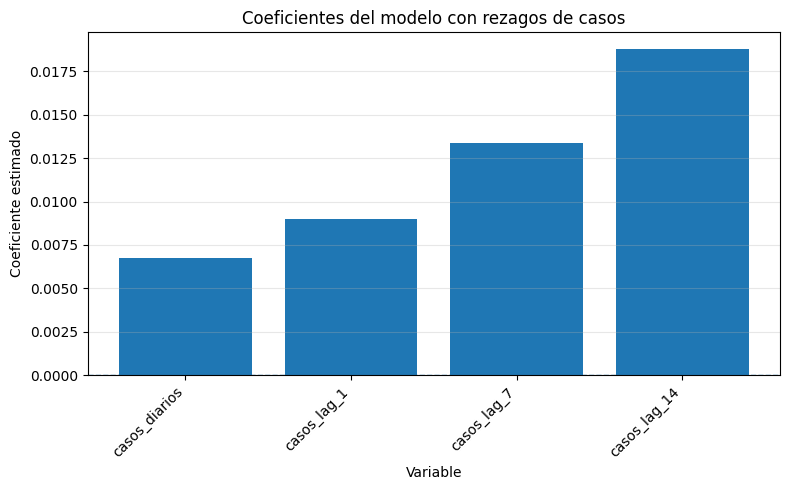

Gráfica guardada en: resultados_etapa_10\coeficientes_rezagos_casos.png


In [30]:
# ------------------------------------------------------------
# 6. Métricas generales
# ------------------------------------------------------------

metricas_rezagos = pd.DataFrame({
    "modelo": [
        "Modelo con rezagos de casos",
        "Modelo con rezagos de hospitalizaciones"
    ],
    "variable_dependiente": [
        "defunciones_diarias",
        "defunciones_diarias"
    ],
    "observaciones": [
        int(modelo_rezagos_casos.nobs),
        int(modelo_rezagos_hosp.nobs)
    ],
    "r_cuadrada": [
        modelo_rezagos_casos.rsquared,
        modelo_rezagos_hosp.rsquared
    ],
    "r_cuadrada_ajustada": [
        modelo_rezagos_casos.rsquared_adj,
        modelo_rezagos_hosp.rsquared_adj
    ],
    "estadistico_f": [
        modelo_rezagos_casos.fvalue,
        modelo_rezagos_hosp.fvalue
    ],
    "p_valor_f": [
        modelo_rezagos_casos.f_pvalue,
        modelo_rezagos_hosp.f_pvalue
    ],
    "aic": [
        modelo_rezagos_casos.aic,
        modelo_rezagos_hosp.aic
    ],
    "bic": [
        modelo_rezagos_casos.bic,
        modelo_rezagos_hosp.bic
    ]
})

display(metricas_rezagos)


# ------------------------------------------------------------
# 7. Interpretación de efectos
# ------------------------------------------------------------

def efectos_rezagos(modelo, variables_rezago, nombre_modelo):
    coefs = modelo.params
    
    efecto_contemporaneo = coefs.get(variables_rezago[0], np.nan)
    efecto_lag_1 = coefs.get(variables_rezago[1], np.nan)
    efecto_lag_7 = coefs.get(variables_rezago[2], np.nan)
    efecto_lag_14 = coefs.get(variables_rezago[3], np.nan)
    
    efecto_acumulado = (
        efecto_contemporaneo +
        efecto_lag_1 +
        efecto_lag_7 +
        efecto_lag_14
    )
    
    # En un modelo de rezagos distribuidos finito, el multiplicador de largo plazo
    # se interpreta como la suma de los coeficientes de los rezagos incluidos.
    multiplicador_largo_plazo = efecto_acumulado
    
    tabla = pd.DataFrame({
        "modelo": [nombre_modelo],
        "efecto_contemporaneo": [efecto_contemporaneo],
        "efecto_lag_1": [efecto_lag_1],
        "efecto_lag_7": [efecto_lag_7],
        "efecto_lag_14": [efecto_lag_14],
        "efecto_acumulado": [efecto_acumulado],
        "multiplicador_largo_plazo": [multiplicador_largo_plazo]
    })
    
    return tabla


efectos_casos = efectos_rezagos(
    modelo_rezagos_casos,
    variables_modelo_casos,
    "Modelo con rezagos de casos"
)

efectos_hosp = efectos_rezagos(
    modelo_rezagos_hosp,
    variables_modelo_hosp,
    "Modelo con rezagos de hospitalizaciones"
)

efectos_rezagos_total = pd.concat(
    [efectos_casos, efectos_hosp],
    ignore_index=True
)

display(efectos_rezagos_total)


# ------------------------------------------------------------
# 8. Predicciones y residuos
# ------------------------------------------------------------

df_pred_rezagos_casos = df_modelo_rezagos_casos.copy()
df_pred_rezagos_casos["defunciones_predichas"] = modelo_rezagos_casos.fittedvalues
df_pred_rezagos_casos["residuos"] = modelo_rezagos_casos.resid

df_pred_rezagos_hosp = df_modelo_rezagos_hosp.copy()
df_pred_rezagos_hosp["defunciones_predichas"] = modelo_rezagos_hosp.fittedvalues
df_pred_rezagos_hosp["residuos"] = modelo_rezagos_hosp.resid

display(df_pred_rezagos_casos.head())
display(df_pred_rezagos_hosp.head())


# ------------------------------------------------------------
# 9. Gráfica de coeficientes de rezagos de casos
# ------------------------------------------------------------

coef_plot_casos = tabla_rezagos_casos[
    tabla_rezagos_casos["variable"] != "const"
].copy()

plt.figure(figsize=(8, 5))
plt.bar(coef_plot_casos["variable"], coef_plot_casos["coeficiente"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Coeficientes del modelo con rezagos de casos")
plt.xlabel("Variable")
plt.ylabel("Coeficiente estimado")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

ruta_coef_casos = OUT_DIR_10 / "coeficientes_rezagos_casos.png"
plt.savefig(ruta_coef_casos, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_coef_casos}")

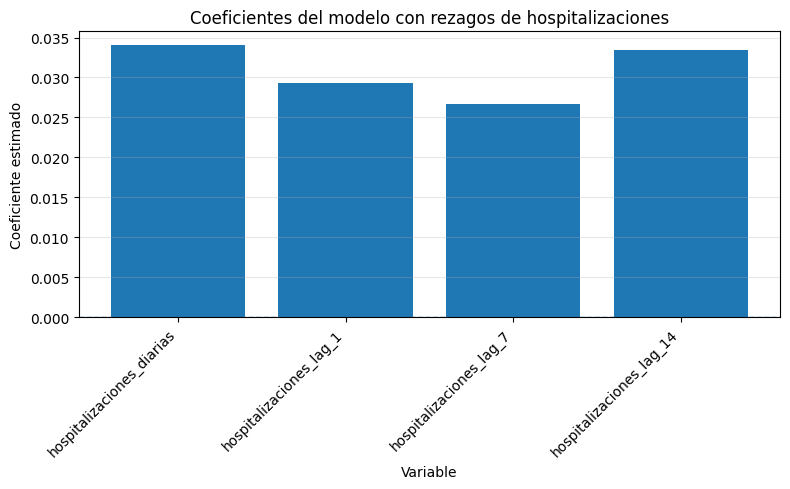

Gráfica guardada en: resultados_etapa_10\coeficientes_rezagos_hospitalizaciones.png


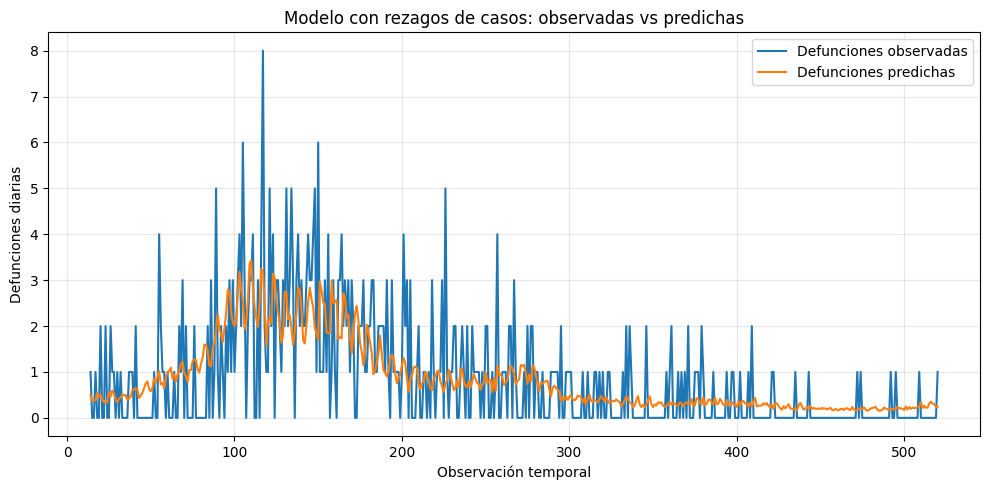

Gráfica guardada en: resultados_etapa_10\predicciones_rezagos_casos.png


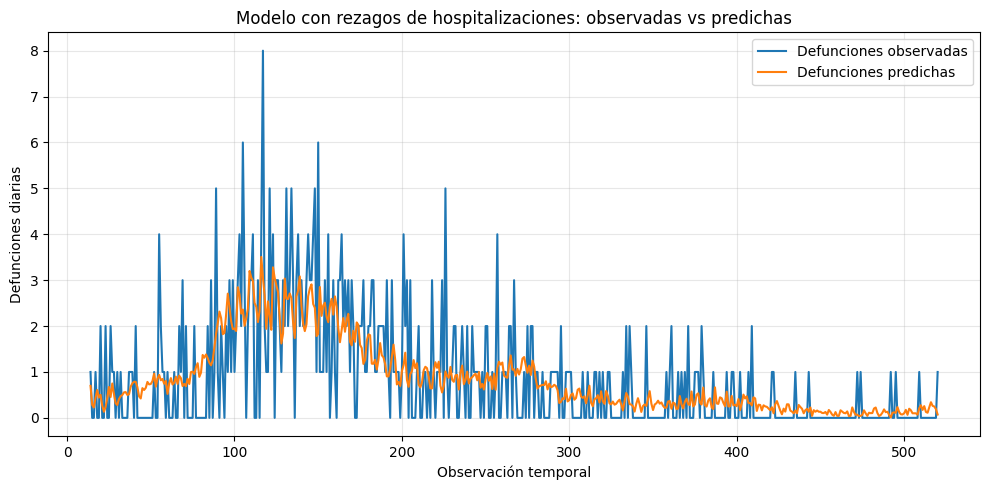

Gráfica guardada en: resultados_etapa_10\predicciones_rezagos_hospitalizaciones.png
Archivo Excel guardado en: resultados_etapa_10\resultados_modelos_rezagos_distribuidos.xlsx
Resumen TXT guardado en: resultados_etapa_10\resumen_modelos_rezagos_distribuidos.txt
Resumen para el reporte
---------------------------------------------

Coeficientes modelo con rezagos de casos


,modelo,variable,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup
0,Modelo con rezagos de casos,const,0.136378,0.059487,2.292565,0.022286,0.019504,0.253252
1,Modelo con rezagos de casos,casos_diarios,0.006730,0.006968,0.965890,0.334564,-0.006960,0.020420
2,Modelo con rezagos de casos,casos_lag_1,0.008996,0.006452,1.394226,0.163866,-0.003681,0.021673
3,Modelo con rezagos de casos,casos_lag_7,0.013353,0.007079,1.886208,0.059844,-0.000556,0.027261
4,Modelo con rezagos de casos,casos_lag_14,0.018798,0.006181,3.041101,0.002480,0.006653,0.030942



Coeficientes modelo con rezagos de hospitalizaciones


,modelo,variable,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup
0,Modelo con rezagos de hospitalizaciones,const,0.009992,0.062937,0.158760,0.873922,-0.113661,0.133645
1,Modelo con rezagos de hospitalizaciones,hospitalizaciones_diarias,0.034071,0.012378,2.752551,0.006127,0.009752,0.058389
2,Modelo con rezagos de hospitalizaciones,hospitalizaciones_lag_1,0.029367,0.012178,2.411484,0.016246,0.005441,0.053293
3,Modelo con rezagos de hospitalizaciones,hospitalizaciones_lag_7,0.026635,0.012219,2.179753,0.029740,0.002628,0.050642
4,Modelo con rezagos de hospitalizaciones,hospitalizaciones_lag_14,0.033492,0.011525,2.905931,0.003823,0.010848,0.056136



Efectos acumulados y multiplicadores


,modelo,efecto_contemporaneo,efecto_lag_1,efecto_lag_7,efecto_lag_14,efecto_acumulado,multiplicador_largo_plazo
0,Modelo con rezagos de casos,0.006730,0.008996,0.013353,0.018798,0.047877,0.047877
1,Modelo con rezagos de hospitalizaciones,0.034071,0.029367,0.026635,0.033492,0.123564,0.123564



Métricas de los modelos


,modelo,variable_dependiente,observaciones,r_cuadrada,r_cuadrada_ajustada,estadistico_f,p_valor_f,aic,bic
0,Modelo con rezagos de casos,defunciones_diarias,507,0.382062,0.377139,77.594957,3.261402e-51,1417.404065,1438.546620
1,Modelo con rezagos de hospitalizaciones,defunciones_diarias,507,0.399136,0.394348,83.365756,3.006110e-54,1403.198893,1424.341448


In [31]:
# ------------------------------------------------------------
# 10. Gráfica de coeficientes de rezagos de hospitalizaciones
# ------------------------------------------------------------

coef_plot_hosp = tabla_rezagos_hosp[
    tabla_rezagos_hosp["variable"] != "const"
].copy()

plt.figure(figsize=(8, 5))
plt.bar(coef_plot_hosp["variable"], coef_plot_hosp["coeficiente"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Coeficientes del modelo con rezagos de hospitalizaciones")
plt.xlabel("Variable")
plt.ylabel("Coeficiente estimado")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

ruta_coef_hosp = OUT_DIR_10 / "coeficientes_rezagos_hospitalizaciones.png"
plt.savefig(ruta_coef_hosp, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_coef_hosp}")


# ------------------------------------------------------------
# 11. Defunciones observadas vs predichas - modelo casos
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    df_pred_rezagos_casos.index,
    df_pred_rezagos_casos["defunciones_diarias"],
    label="Defunciones observadas"
)

plt.plot(
    df_pred_rezagos_casos.index,
    df_pred_rezagos_casos["defunciones_predichas"],
    label="Defunciones predichas"
)

plt.title("Modelo con rezagos de casos: observadas vs predichas")
plt.xlabel("Observación temporal")
plt.ylabel("Defunciones diarias")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

ruta_pred_casos = OUT_DIR_10 / "predicciones_rezagos_casos.png"
plt.savefig(ruta_pred_casos, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_pred_casos}")


# ------------------------------------------------------------
# 12. Defunciones observadas vs predichas - modelo hospitalizaciones
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    df_pred_rezagos_hosp.index,
    df_pred_rezagos_hosp["defunciones_diarias"],
    label="Defunciones observadas"
)

plt.plot(
    df_pred_rezagos_hosp.index,
    df_pred_rezagos_hosp["defunciones_predichas"],
    label="Defunciones predichas"
)

plt.title("Modelo con rezagos de hospitalizaciones: observadas vs predichas")
plt.xlabel("Observación temporal")
plt.ylabel("Defunciones diarias")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

ruta_pred_hosp = OUT_DIR_10 / "predicciones_rezagos_hospitalizaciones.png"
plt.savefig(ruta_pred_hosp, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_pred_hosp}")


# ------------------------------------------------------------
# 13. Guardar resultados en Excel
# ------------------------------------------------------------

ruta_excel_rezagos = OUT_DIR_10 / "resultados_modelos_rezagos_distribuidos.xlsx"

with pd.ExcelWriter(ruta_excel_rezagos, engine="openpyxl") as writer:
    tabla_rezagos_casos.to_excel(writer, sheet_name="coef_rezagos_casos", index=False)
    tabla_rezagos_hosp.to_excel(writer, sheet_name="coef_rezagos_hosp", index=False)
    metricas_rezagos.to_excel(writer, sheet_name="metricas_modelos", index=False)
    efectos_rezagos_total.to_excel(writer, sheet_name="efectos_acumulados", index=False)
    df_pred_rezagos_casos.to_excel(writer, sheet_name="pred_resid_casos", index=False)
    df_pred_rezagos_hosp.to_excel(writer, sheet_name="pred_resid_hosp", index=False)

print(f"Archivo Excel guardado en: {ruta_excel_rezagos}")


# ------------------------------------------------------------
# 14. Guardar resúmenes en TXT
# ------------------------------------------------------------

ruta_txt_rezagos = OUT_DIR_10 / "resumen_modelos_rezagos_distribuidos.txt"

with open(ruta_txt_rezagos, "w", encoding="utf-8") as f:
    f.write("ETAPA 10. MODELOS CON REZAGOS DISTRIBUIDOS\n")
    f.write("=" * 70 + "\n\n")
    
    f.write("Modelo principal: defunciones diarias explicadas por casos diarios contemporáneos y rezagados.\n")
    f.write(str(modelo_rezagos_casos.summary()))
    f.write("\n\n")
    
    f.write("Modelo complementario: defunciones diarias explicadas por hospitalizaciones contemporáneas y rezagadas.\n")
    f.write(str(modelo_rezagos_hosp.summary()))
    f.write("\n\n")
    
    f.write("Efectos acumulados y multiplicadores:\n")
    f.write(efectos_rezagos_total.to_string(index=False))

print(f"Resumen TXT guardado en: {ruta_txt_rezagos}")


# ------------------------------------------------------------
# 15. Síntesis de resultados para el reporte
# ------------------------------------------------------------

print("Resumen para el reporte")
print("---------------------------------------------")

print("\nCoeficientes modelo con rezagos de casos")
display(tabla_rezagos_casos)

print("\nCoeficientes modelo con rezagos de hospitalizaciones")
display(tabla_rezagos_hosp)

print("\nEfectos acumulados y multiplicadores")
display(efectos_rezagos_total)

print("\nMétricas de los modelos")
display(metricas_rezagos)

## **ETAPA 11. MODELO DE AJUSTE PARCIAL**

In [32]:
# ============================================================
# ETAPA 11. MODELO DE AJUSTE PARCIAL
# Defunciones diarias y hospitalizaciones diarias
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from IPython.display import display

# Carpeta de salida para esta etapa
OUT_DIR_11 = Path("resultados_etapa_11")
OUT_DIR_11.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 1. Preparar serie temporal
# ------------------------------------------------------------

df_ajuste = df_ts.copy()

if "fecha" in df_ajuste.columns:
    df_ajuste["fecha"] = pd.to_datetime(df_ajuste["fecha"], errors="coerce")
    df_ajuste = df_ajuste.sort_values("fecha")
else:
    df_ajuste = df_ajuste.sort_index()

variables_ajuste = [
    "defunciones_diarias",
    "hospitalizaciones_diarias",
    "casos_diarios"
]

for col in variables_ajuste:
    if col in df_ajuste.columns:
        df_ajuste[col] = pd.to_numeric(df_ajuste[col], errors="coerce")

# Crear rezago de la variable dependiente
df_ajuste["defunciones_lag_1"] = df_ajuste["defunciones_diarias"].shift(1)

display(df_ajuste.head())


# ------------------------------------------------------------
# 2. Modelo principal de ajuste parcial
# Defunciones_t ~ Hospitalizaciones_t + Defunciones_t-1
# ------------------------------------------------------------

variables_modelo_ajuste = [
    "hospitalizaciones_diarias",
    "defunciones_lag_1"
]

df_modelo_ajuste = df_ajuste[
    ["defunciones_diarias"] + variables_modelo_ajuste
].dropna().copy()

Y_ajuste = df_modelo_ajuste["defunciones_diarias"]
X_ajuste = df_modelo_ajuste[variables_modelo_ajuste]
X_ajuste = sm.add_constant(X_ajuste)

modelo_ajuste_parcial = sm.OLS(Y_ajuste, X_ajuste).fit()

print(modelo_ajuste_parcial.summary())


# ------------------------------------------------------------
# 3. Modelo complementario
# Defunciones_t ~ Casos_t + Defunciones_t-1
# ------------------------------------------------------------

variables_modelo_ajuste_casos = [
    "casos_diarios",
    "defunciones_lag_1"
]

df_modelo_ajuste_casos = df_ajuste[
    ["defunciones_diarias"] + variables_modelo_ajuste_casos
].dropna().copy()

Y_ajuste_casos = df_modelo_ajuste_casos["defunciones_diarias"]
X_ajuste_casos = df_modelo_ajuste_casos[variables_modelo_ajuste_casos]
X_ajuste_casos = sm.add_constant(X_ajuste_casos)

modelo_ajuste_parcial_casos = sm.OLS(Y_ajuste_casos, X_ajuste_casos).fit()

print(modelo_ajuste_parcial_casos.summary())


# ------------------------------------------------------------
# 4. Función para tabla de coeficientes
# ------------------------------------------------------------

def tabla_coeficientes_ajuste(modelo, nombre_modelo):
    tabla = pd.DataFrame({
        "modelo": nombre_modelo,
        "variable": modelo.params.index,
        "coeficiente": modelo.params.values,
        "error_estandar": modelo.bse.values,
        "t": modelo.tvalues.values,
        "p_valor": modelo.pvalues.values,
        "IC_95_inf": modelo.conf_int()[0].values,
        "IC_95_sup": modelo.conf_int()[1].values
    })
    return tabla


tabla_ajuste_hosp = tabla_coeficientes_ajuste(
    modelo_ajuste_parcial,
    "Ajuste parcial con hospitalizaciones"
)

tabla_ajuste_casos = tabla_coeficientes_ajuste(
    modelo_ajuste_parcial_casos,
    "Ajuste parcial con casos"
)

print("Modelo de ajuste parcial con hospitalizaciones")
display(tabla_ajuste_hosp)

print("Modelo de ajuste parcial con casos")
display(tabla_ajuste_casos)

,fecha,casos_diarios,hospitalizaciones_diarias,defunciones_diarias,defunciones_lag_1
0,2025-01-01,7.0,5.0,0.0,NaN
1,2025-01-02,2.0,2.0,0.0,0.0
2,2025-01-03,7.0,3.0,0.0,0.0
3,2025-01-04,7.0,5.0,0.0,0.0
4,2025-01-05,8.0,3.0,0.0,0.0


                             OLS Regression Results                            
Dep. Variable:     defunciones_diarias   R-squared:                       0.348
Model:                             OLS   Adj. R-squared:                  0.346
Method:                  Least Squares   F-statistic:                     138.1
Date:                 Wed, 17 Jun 2026   Prob (F-statistic):           9.11e-49
Time:                         22:31:59   Log-Likelihood:                -731.47
No. Observations:                  520   AIC:                             1469.
Df Residuals:                      517   BIC:                             1482.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

,modelo,variable,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup
0,Ajuste parcial con hospitalizaciones,const,0.117575,0.061748,1.904100,5.745197e-02,-0.003733,0.238884
1,Ajuste parcial con hospitalizaciones,hospitalizaciones_diarias,0.097117,0.007439,13.055784,7.164845e-34,0.082503,0.111730
2,Ajuste parcial con hospitalizaciones,defunciones_lag_1,0.086873,0.041388,2.098958,3.630497e-02,0.005562,0.168183


Modelo de ajuste parcial con casos


,modelo,variable,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup
0,Ajuste parcial con casos,const,0.187903,0.059551,3.155304,1.696675e-03,0.070910,0.304895
1,Ajuste parcial con casos,casos_diarios,0.039551,0.003084,12.824047,6.993357e-33,0.033492,0.045610
2,Ajuste parcial con casos,defunciones_lag_1,0.087603,0.041691,2.101226,3.610457e-02,0.005698,0.169508


In [33]:
# ------------------------------------------------------------
# 5. Métricas generales de los modelos
# ------------------------------------------------------------

metricas_ajuste = pd.DataFrame({
    "modelo": [
        "Ajuste parcial con hospitalizaciones",
        "Ajuste parcial con casos"
    ],
    "variable_dependiente": [
        "defunciones_diarias",
        "defunciones_diarias"
    ],
    "observaciones": [
        int(modelo_ajuste_parcial.nobs),
        int(modelo_ajuste_parcial_casos.nobs)
    ],
    "r_cuadrada": [
        modelo_ajuste_parcial.rsquared,
        modelo_ajuste_parcial_casos.rsquared
    ],
    "r_cuadrada_ajustada": [
        modelo_ajuste_parcial.rsquared_adj,
        modelo_ajuste_parcial_casos.rsquared_adj
    ],
    "estadistico_f": [
        modelo_ajuste_parcial.fvalue,
        modelo_ajuste_parcial_casos.fvalue
    ],
    "p_valor_f": [
        modelo_ajuste_parcial.f_pvalue,
        modelo_ajuste_parcial_casos.f_pvalue
    ],
    "aic": [
        modelo_ajuste_parcial.aic,
        modelo_ajuste_parcial_casos.aic
    ],
    "bic": [
        modelo_ajuste_parcial.bic,
        modelo_ajuste_parcial_casos.bic
    ]
})

display(metricas_ajuste)


# ------------------------------------------------------------
# 6. Cálculo de velocidad de ajuste y largo plazo
# ------------------------------------------------------------

def calcular_parametros_ajuste(modelo, variable_explicativa, nombre_modelo):
    """
    En el modelo:
    Y_t = alpha + beta X_t + rho Y_{t-1} + u_t

    rho = coeficiente de Y_{t-1}
    lambda = 1 - rho
    beta_largo_plazo = beta / lambda
    intercepto_largo_plazo = alpha / lambda
    """
    
    alpha = modelo.params.get("const", np.nan)
    beta_corto_plazo = modelo.params.get(variable_explicativa, np.nan)
    rho = modelo.params.get("defunciones_lag_1", np.nan)
    
    velocidad_ajuste = 1 - rho
    persistencia_temporal = rho
    
    if velocidad_ajuste != 0:
        beta_largo_plazo = beta_corto_plazo / velocidad_ajuste
        intercepto_largo_plazo = alpha / velocidad_ajuste
    else:
        beta_largo_plazo = np.nan
        intercepto_largo_plazo = np.nan
    
    return pd.DataFrame({
        "modelo": [nombre_modelo],
        "variable_explicativa": [variable_explicativa],
        "intercepto_corto_plazo": [alpha],
        "beta_corto_plazo": [beta_corto_plazo],
        "rho_persistencia": [rho],
        "velocidad_ajuste_lambda": [velocidad_ajuste],
        "beta_largo_plazo": [beta_largo_plazo],
        "intercepto_largo_plazo": [intercepto_largo_plazo],
        "interpretacion_velocidad": [
            interpretar_velocidad_ajuste(velocidad_ajuste)
        ]
    })


def interpretar_velocidad_ajuste(lambda_val):
    if pd.isna(lambda_val):
        return "No calculable"
    elif lambda_val < 0:
        return "Ajuste inestable: revisar especificación del modelo"
    elif lambda_val < 0.30:
        return "Ajuste lento: alta persistencia temporal"
    elif lambda_val < 0.70:
        return "Ajuste moderado"
    elif lambda_val <= 1:
        return "Ajuste rápido: baja persistencia temporal"
    else:
        return "Sobreajuste o ajuste mayor a uno: revisar especificación"


parametros_ajuste_hosp = calcular_parametros_ajuste(
    modelo_ajuste_parcial,
    "hospitalizaciones_diarias",
    "Ajuste parcial con hospitalizaciones"
)

parametros_ajuste_casos = calcular_parametros_ajuste(
    modelo_ajuste_parcial_casos,
    "casos_diarios",
    "Ajuste parcial con casos"
)

parametros_ajuste_total = pd.concat(
    [parametros_ajuste_hosp, parametros_ajuste_casos],
    ignore_index=True
)

display(parametros_ajuste_total)


# ------------------------------------------------------------
# 7. Predicciones y residuos
# ------------------------------------------------------------

df_pred_ajuste_hosp = df_modelo_ajuste.copy()
df_pred_ajuste_hosp["defunciones_predichas"] = modelo_ajuste_parcial.fittedvalues
df_pred_ajuste_hosp["residuos"] = modelo_ajuste_parcial.resid

df_pred_ajuste_casos = df_modelo_ajuste_casos.copy()
df_pred_ajuste_casos["defunciones_predichas"] = modelo_ajuste_parcial_casos.fittedvalues
df_pred_ajuste_casos["residuos"] = modelo_ajuste_parcial_casos.resid

display(df_pred_ajuste_hosp.head())
display(df_pred_ajuste_casos.head())

,modelo,variable_dependiente,observaciones,r_cuadrada,r_cuadrada_ajustada,estadistico_f,p_valor_f,aic,bic
0,Ajuste parcial con hospitalizaciones,defunciones_diarias,520,0.348135,0.345614,138.054776,9.113353e-49,1468.940993,1481.702480
1,Ajuste parcial con casos,defunciones_diarias,520,0.342399,0.339855,134.595248,8.777521e-48,1473.497357,1486.258843


,modelo,variable_explicativa,intercepto_corto_plazo,beta_corto_plazo,rho_persistencia,velocidad_ajuste_lambda,beta_largo_plazo,intercepto_largo_plazo,interpretacion_velocidad
0,Ajuste parcial con hospitalizaciones,hospitalizaciones_diarias,0.117575,0.097117,0.086873,0.913127,0.106356,0.128761,Ajuste rápido: baja persistencia temporal
1,Ajuste parcial con casos,casos_diarios,0.187903,0.039551,0.087603,0.912397,0.043348,0.205944,Ajuste rápido: baja persistencia temporal


,defunciones_diarias,hospitalizaciones_diarias,defunciones_lag_1,defunciones_predichas,residuos
1,0.0,2.0,0.0,0.311808,-0.311808
2,0.0,3.0,0.0,0.408925,-0.408925
3,0.0,5.0,0.0,0.603158,-0.603158
4,0.0,3.0,0.0,0.408925,-0.408925
5,1.0,6.0,0.0,0.700274,0.299726


,defunciones_diarias,casos_diarios,defunciones_lag_1,defunciones_predichas,residuos
1,0.0,2.0,0.0,0.267005,-0.267005
2,0.0,7.0,0.0,0.464759,-0.464759
3,0.0,7.0,0.0,0.464759,-0.464759
4,0.0,8.0,0.0,0.504310,-0.504310
5,1.0,9.0,0.0,0.543861,0.456139


,defunciones_diarias,hospitalizaciones_diarias,defunciones_lag_1,defunciones_predichas,residuos,equilibrio_largo_plazo,brecha_ajuste
1,0.0,2.0,0.0,0.311808,-0.311808,0.341473,0.341473
2,0.0,3.0,0.0,0.408925,-0.408925,0.447829,0.447829
3,0.0,5.0,0.0,0.603158,-0.603158,0.660541,0.660541
4,0.0,3.0,0.0,0.408925,-0.408925,0.447829,0.447829
5,1.0,6.0,0.0,0.700274,0.299726,0.766897,-0.233103


,defunciones_diarias,casos_diarios,defunciones_lag_1,defunciones_predichas,residuos,equilibrio_largo_plazo,brecha_ajuste
1,0.0,2.0,0.0,0.267005,-0.267005,0.292641,0.292641
2,0.0,7.0,0.0,0.464759,-0.464759,0.509383,0.509383
3,0.0,7.0,0.0,0.464759,-0.464759,0.509383,0.509383
4,0.0,8.0,0.0,0.504310,-0.504310,0.552731,0.552731
5,1.0,9.0,0.0,0.543861,0.456139,0.596079,-0.403921


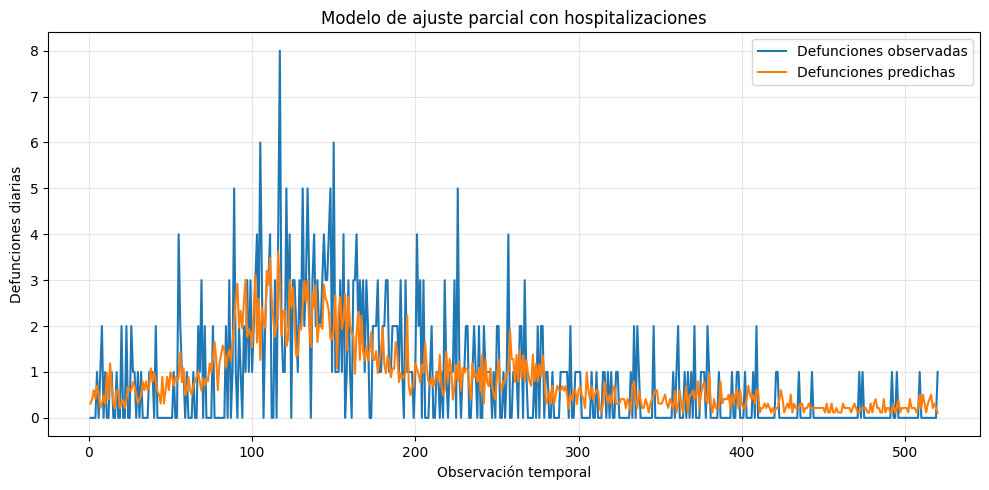

Gráfica guardada en: resultados_etapa_11\ajuste_parcial_observadas_predichas_hosp.png


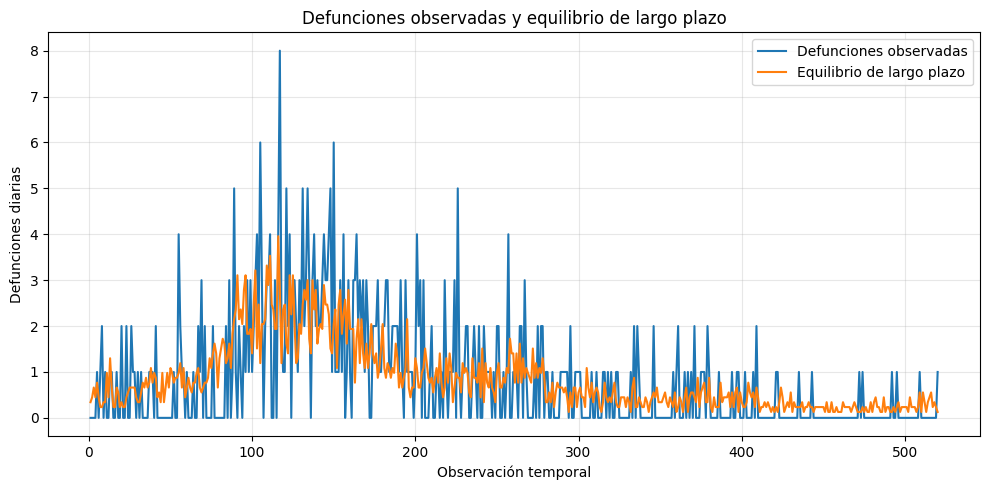

Gráfica guardada en: resultados_etapa_11\ajuste_parcial_equilibrio_largo_plazo_hosp.png


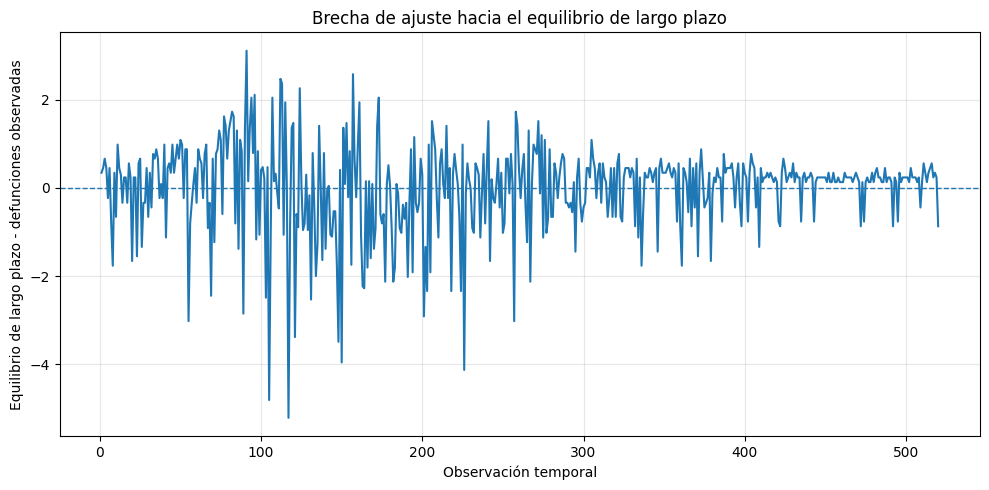

Gráfica guardada en: resultados_etapa_11\ajuste_parcial_brecha_hosp.png


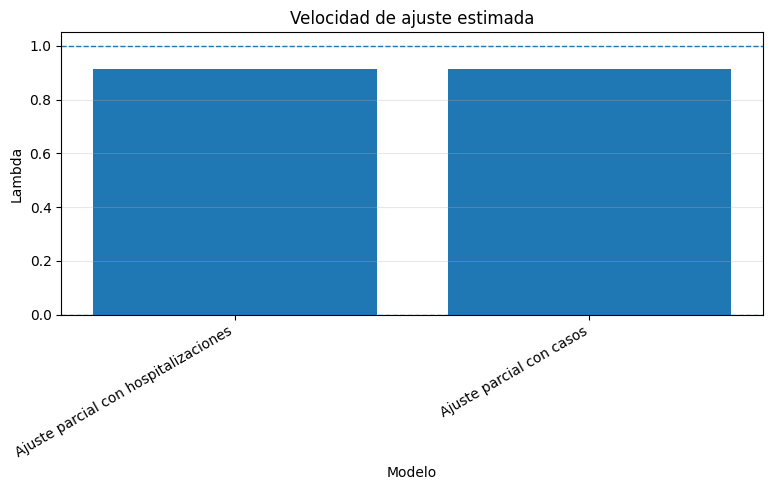

Gráfica guardada en: resultados_etapa_11\velocidad_ajuste_lambda.png


In [34]:
# ------------------------------------------------------------
# 8. Calcular nivel de equilibrio de largo plazo
# ------------------------------------------------------------

def agregar_equilibrio_largo_plazo(df_pred, parametros, variable_explicativa):
    """
    Equilibrio de largo plazo:
    Y* = intercepto_largo_plazo + beta_largo_plazo * X_t
    """
    df_out = df_pred.copy()
    
    intercepto_lp = parametros["intercepto_largo_plazo"].iloc[0]
    beta_lp = parametros["beta_largo_plazo"].iloc[0]
    
    df_out["equilibrio_largo_plazo"] = (
        intercepto_lp + beta_lp * df_out[variable_explicativa]
    )
    
    df_out["brecha_ajuste"] = (
        df_out["equilibrio_largo_plazo"] -
        df_out["defunciones_diarias"]
    )
    
    return df_out


df_pred_ajuste_hosp = agregar_equilibrio_largo_plazo(
    df_pred_ajuste_hosp,
    parametros_ajuste_hosp,
    "hospitalizaciones_diarias"
)

df_pred_ajuste_casos = agregar_equilibrio_largo_plazo(
    df_pred_ajuste_casos,
    parametros_ajuste_casos,
    "casos_diarios"
)

display(df_pred_ajuste_hosp.head())
display(df_pred_ajuste_casos.head())


# ------------------------------------------------------------
# 9. Gráfica observadas vs predichas - hospitalizaciones
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    df_pred_ajuste_hosp.index,
    df_pred_ajuste_hosp["defunciones_diarias"],
    label="Defunciones observadas"
)

plt.plot(
    df_pred_ajuste_hosp.index,
    df_pred_ajuste_hosp["defunciones_predichas"],
    label="Defunciones predichas"
)

plt.title("Modelo de ajuste parcial con hospitalizaciones")
plt.xlabel("Observación temporal")
plt.ylabel("Defunciones diarias")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

ruta_ajuste_hosp = OUT_DIR_11 / "ajuste_parcial_observadas_predichas_hosp.png"
plt.savefig(ruta_ajuste_hosp, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_ajuste_hosp}")


# ------------------------------------------------------------
# 10. Gráfica observadas vs equilibrio de largo plazo - hospitalizaciones
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    df_pred_ajuste_hosp.index,
    df_pred_ajuste_hosp["defunciones_diarias"],
    label="Defunciones observadas"
)

plt.plot(
    df_pred_ajuste_hosp.index,
    df_pred_ajuste_hosp["equilibrio_largo_plazo"],
    label="Equilibrio de largo plazo"
)

plt.title("Defunciones observadas y equilibrio de largo plazo")
plt.xlabel("Observación temporal")
plt.ylabel("Defunciones diarias")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

ruta_equilibrio_hosp = OUT_DIR_11 / "ajuste_parcial_equilibrio_largo_plazo_hosp.png"
plt.savefig(ruta_equilibrio_hosp, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_equilibrio_hosp}")


# ------------------------------------------------------------
# 11. Gráfica de brecha de ajuste - hospitalizaciones
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    df_pred_ajuste_hosp.index,
    df_pred_ajuste_hosp["brecha_ajuste"]
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Brecha de ajuste hacia el equilibrio de largo plazo")
plt.xlabel("Observación temporal")
plt.ylabel("Equilibrio de largo plazo - defunciones observadas")
plt.grid(alpha=0.3)
plt.tight_layout()

ruta_brecha_hosp = OUT_DIR_11 / "ajuste_parcial_brecha_hosp.png"
plt.savefig(ruta_brecha_hosp, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_brecha_hosp}")


# ------------------------------------------------------------
# 12. Comparación de velocidad de ajuste
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    parametros_ajuste_total["modelo"],
    parametros_ajuste_total["velocidad_ajuste_lambda"]
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)

plt.title("Velocidad de ajuste estimada")
plt.xlabel("Modelo")
plt.ylabel("Lambda")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

ruta_lambda = OUT_DIR_11 / "velocidad_ajuste_lambda.png"
plt.savefig(ruta_lambda, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_lambda}")

In [35]:
# ------------------------------------------------------------
# 13. Guardar resultados en Excel
# ------------------------------------------------------------

ruta_excel_ajuste = OUT_DIR_11 / "resultados_modelo_ajuste_parcial.xlsx"

with pd.ExcelWriter(ruta_excel_ajuste, engine="openpyxl") as writer:
    tabla_ajuste_hosp.to_excel(writer, sheet_name="coef_ajuste_hosp", index=False)
    tabla_ajuste_casos.to_excel(writer, sheet_name="coef_ajuste_casos", index=False)
    metricas_ajuste.to_excel(writer, sheet_name="metricas_modelos", index=False)
    parametros_ajuste_total.to_excel(writer, sheet_name="velocidad_equilibrio", index=False)
    df_pred_ajuste_hosp.to_excel(writer, sheet_name="pred_equilibrio_hosp", index=False)
    df_pred_ajuste_casos.to_excel(writer, sheet_name="pred_equilibrio_casos", index=False)

print(f"Archivo Excel guardado en: {ruta_excel_ajuste}")


# ------------------------------------------------------------
# 14. Guardar resúmenes en TXT
# ------------------------------------------------------------

ruta_txt_ajuste = OUT_DIR_11 / "resumen_modelo_ajuste_parcial.txt"

with open(ruta_txt_ajuste, "w", encoding="utf-8") as f:
    f.write("ETAPA 11. MODELO DE AJUSTE PARCIAL\n")
    f.write("=" * 70 + "\n\n")
    
    f.write("Modelo principal: defunciones diarias explicadas por hospitalizaciones diarias y defunciones rezagadas.\n")
    f.write(str(modelo_ajuste_parcial.summary()))
    f.write("\n\n")
    
    f.write("Modelo complementario: defunciones diarias explicadas por casos diarios y defunciones rezagadas.\n")
    f.write(str(modelo_ajuste_parcial_casos.summary()))
    f.write("\n\n")
    
    f.write("Parámetros de ajuste:\n")
    f.write(parametros_ajuste_total.to_string(index=False))

print(f"Resumen TXT guardado en: {ruta_txt_ajuste}")


# ------------------------------------------------------------
# 15. Síntesis de resultados para el reporte
# ------------------------------------------------------------

print("Resumen para el reporte")
print("---------------------------------------------")

print("\nCoeficientes del modelo de ajuste parcial con hospitalizaciones")
display(tabla_ajuste_hosp)

print("\nCoeficientes del modelo de ajuste parcial con casos")
display(tabla_ajuste_casos)

print("\nVelocidad de ajuste, persistencia y largo plazo")
display(parametros_ajuste_total)

print("\nMétricas de comparación")
display(metricas_ajuste)

Archivo Excel guardado en: resultados_etapa_11\resultados_modelo_ajuste_parcial.xlsx
Resumen TXT guardado en: resultados_etapa_11\resumen_modelo_ajuste_parcial.txt
Resumen para el reporte
---------------------------------------------

Coeficientes del modelo de ajuste parcial con hospitalizaciones


,modelo,variable,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup
0,Ajuste parcial con hospitalizaciones,const,0.117575,0.061748,1.904100,5.745197e-02,-0.003733,0.238884
1,Ajuste parcial con hospitalizaciones,hospitalizaciones_diarias,0.097117,0.007439,13.055784,7.164845e-34,0.082503,0.111730
2,Ajuste parcial con hospitalizaciones,defunciones_lag_1,0.086873,0.041388,2.098958,3.630497e-02,0.005562,0.168183



Coeficientes del modelo de ajuste parcial con casos


,modelo,variable,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup
0,Ajuste parcial con casos,const,0.187903,0.059551,3.155304,1.696675e-03,0.070910,0.304895
1,Ajuste parcial con casos,casos_diarios,0.039551,0.003084,12.824047,6.993357e-33,0.033492,0.045610
2,Ajuste parcial con casos,defunciones_lag_1,0.087603,0.041691,2.101226,3.610457e-02,0.005698,0.169508



Velocidad de ajuste, persistencia y largo plazo


,modelo,variable_explicativa,intercepto_corto_plazo,beta_corto_plazo,rho_persistencia,velocidad_ajuste_lambda,beta_largo_plazo,intercepto_largo_plazo,interpretacion_velocidad
0,Ajuste parcial con hospitalizaciones,hospitalizaciones_diarias,0.117575,0.097117,0.086873,0.913127,0.106356,0.128761,Ajuste rápido: baja persistencia temporal
1,Ajuste parcial con casos,casos_diarios,0.187903,0.039551,0.087603,0.912397,0.043348,0.205944,Ajuste rápido: baja persistencia temporal



Métricas de comparación


,modelo,variable_dependiente,observaciones,r_cuadrada,r_cuadrada_ajustada,estadistico_f,p_valor_f,aic,bic
0,Ajuste parcial con hospitalizaciones,defunciones_diarias,520,0.348135,0.345614,138.054776,9.113353e-49,1468.940993,1481.702480
1,Ajuste parcial con casos,defunciones_diarias,520,0.342399,0.339855,134.595248,8.777521e-48,1473.497357,1486.258843


## **ETAPA 12. MODELO DE EXPECTATIVAS ADAPTATIVAS**

In [36]:
# ============================================================
# ETAPA 12. MODELO DE EXPECTATIVAS ADAPTATIVAS
# Casos diarios, hospitalizaciones diarias y defunciones diarias
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from IPython.display import display

# Carpeta de salida para esta etapa
OUT_DIR_12 = Path("resultados_etapa_12")
OUT_DIR_12.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 1. Preparar serie temporal
# ------------------------------------------------------------

df_exp = df_ts.copy()

if "fecha" in df_exp.columns:
    df_exp["fecha"] = pd.to_datetime(df_exp["fecha"], errors="coerce")
    df_exp = df_exp.sort_values("fecha")
else:
    df_exp = df_exp.sort_index()

variables_expectativas = [
    "casos_diarios",
    "hospitalizaciones_diarias",
    "defunciones_diarias"
]

for col in variables_expectativas:
    df_exp[col] = pd.to_numeric(df_exp[col], errors="coerce")

df_exp = df_exp.dropna(subset=variables_expectativas).reset_index(drop=True)

print("Observaciones disponibles:", len(df_exp))
display(df_exp.head())


# ------------------------------------------------------------
# 2. Funciones para expectativas adaptativas
# ------------------------------------------------------------

def calcular_expectativa_adaptativa(serie, lambda_ajuste):
    """
    Calcula expectativas adaptativas:
    E_t = lambda * Y_{t-1} + (1 - lambda) * E_{t-1}

    La primera expectativa se inicializa con el primer valor observado.
    """
    serie = pd.Series(serie).reset_index(drop=True)
    expectativas = np.zeros(len(serie))

    expectativas[0] = serie.iloc[0]

    for t in range(1, len(serie)):
        expectativas[t] = (
            lambda_ajuste * serie.iloc[t - 1] +
            (1 - lambda_ajuste) * expectativas[t - 1]
        )

    return pd.Series(expectativas)


def calcular_metricas_error(y_real, y_pred):
    """
    Calcula métricas de error.
    """
    y_real = pd.Series(y_real).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)

    error = y_real - y_pred

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    sesgo = np.mean(error)

    # MAPE evitando división entre cero
    mascara = y_real != 0
    if mascara.sum() > 0:
        mape = np.mean(np.abs((y_real[mascara] - y_pred[mascara]) / y_real[mascara])) * 100
    else:
        mape = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "sesgo_promedio": sesgo
    }


def evaluar_lambdas(df_base, variable, lambdas):
    """
    Evalúa distintos valores de lambda y selecciona el mejor según RMSE.
    """
    resultados = []

    y_real = df_base[variable]

    for lam in lambdas:
        expectativa = calcular_expectativa_adaptativa(y_real, lam)
        metricas = calcular_metricas_error(y_real, expectativa)

        resultados.append({
            "variable": variable,
            "lambda": lam,
            "peso_dato_observado_anterior": lam,
            "peso_expectativa_pasada": 1 - lam,
            **metricas
        })

    tabla = pd.DataFrame(resultados)
    tabla = tabla.sort_values("RMSE").reset_index(drop=True)

    return tabla


def estimar_modelo_expectativa(df_base, variable, expectativa_col):
    """
    Estima:
    Y_t = alpha + beta * E_t + u_t
    """
    df_modelo = df_base[[variable, expectativa_col]].dropna().copy()

    Y = df_modelo[variable]
    X = df_modelo[[expectativa_col]]
    X = sm.add_constant(X)

    modelo = sm.OLS(Y, X).fit()

    return modelo, df_modelo


# ------------------------------------------------------------
# 3. Evaluar valores de lambda
# ------------------------------------------------------------

lambdas = np.round(np.arange(0.1, 1.0, 0.1), 2)

resultados_lambdas = []

for variable in variables_expectativas:
    tabla_var = evaluar_lambdas(df_exp, variable, lambdas)
    resultados_lambdas.append(tabla_var)

resultados_lambdas = pd.concat(resultados_lambdas, ignore_index=True)

print("Evaluación de lambdas")
display(resultados_lambdas)

Observaciones disponibles: 521


,fecha,casos_diarios,hospitalizaciones_diarias,defunciones_diarias
0,2025-01-01,7.0,5.0,0.0
1,2025-01-02,2.0,2.0,0.0
2,2025-01-03,7.0,3.0,0.0
3,2025-01-04,7.0,5.0,0.0
4,2025-01-05,8.0,3.0,0.0


Evaluación de lambdas


,variable,lambda,peso_dato_observado_anterior,peso_expectativa_pasada,MAE,RMSE,MAPE,sesgo_promedio
0,casos_diarios,0.2,0.2,0.8,4.257357,6.842990,46.220874,-0.037203
1,casos_diarios,0.3,0.3,0.7,4.218258,6.843695,46.004528,-0.026818
2,casos_diarios,0.4,0.4,0.6,4.247992,6.909295,46.604088,-0.022084
3,casos_diarios,0.5,0.5,0.5,4.289452,6.980490,47.511082,-0.019311
4,casos_diarios,0.6,0.6,0.4,4.313850,7.048151,48.428558,-0.017426
5,casos_diarios,0.7,0.7,0.3,4.355102,7.119381,49.483849,-0.016026
6,casos_diarios,0.8,0.8,0.2,4.409160,7.206832,50.702471,-0.014942
7,casos_diarios,0.1,0.1,0.9,4.586973,7.252106,49.456938,-0.075654
8,casos_diarios,0.9,0.9,0.1,4.504001,7.323628,52.104959,-0.014094
9,hospitalizaciones_diarias,0.2,0.2,0.8,2.325098,3.309493,51.488877,-0.034047


In [37]:
# ------------------------------------------------------------
# 4. Seleccionar mejor lambda por variable
# ------------------------------------------------------------

mejores_lambdas = (
    resultados_lambdas
    .sort_values("RMSE")
    .groupby("variable")
    .first()
    .reset_index()
)

print("Mejores lambdas según RMSE")
display(mejores_lambdas)


# ------------------------------------------------------------
# 5. Construir expectativas adaptativas finales
# ------------------------------------------------------------

df_expectativas_final = df_exp.copy()

for _, row in mejores_lambdas.iterrows():
    variable = row["variable"]
    lam = row["lambda"]

    col_expectativa = f"expectativa_{variable}"
    col_error = f"error_{variable}"

    df_expectativas_final[col_expectativa] = calcular_expectativa_adaptativa(
        df_expectativas_final[variable],
        lam
    )

    df_expectativas_final[col_error] = (
        df_expectativas_final[variable] -
        df_expectativas_final[col_expectativa]
    )

display(df_expectativas_final.head())


# ------------------------------------------------------------
# 6. Estimar modelos: observado_t ~ expectativa_t
# ------------------------------------------------------------

tablas_coeficientes_exp = []
metricas_modelos_exp = []
modelos_exp = {}
datos_modelos_exp = {}

for variable in variables_expectativas:
    col_expectativa = f"expectativa_{variable}"

    modelo, datos_modelo = estimar_modelo_expectativa(
        df_expectativas_final,
        variable,
        col_expectativa
    )

    modelos_exp[variable] = modelo
    datos_modelos_exp[variable] = datos_modelo

    tabla_coef = pd.DataFrame({
        "variable_modelada": variable,
        "variable": modelo.params.index,
        "coeficiente": modelo.params.values,
        "error_estandar": modelo.bse.values,
        "t": modelo.tvalues.values,
        "p_valor": modelo.pvalues.values,
        "IC_95_inf": modelo.conf_int()[0].values,
        "IC_95_sup": modelo.conf_int()[1].values
    })

    tablas_coeficientes_exp.append(tabla_coef)

    metricas_modelos_exp.append({
        "variable_modelada": variable,
        "observaciones": int(modelo.nobs),
        "r_cuadrada": modelo.rsquared,
        "r_cuadrada_ajustada": modelo.rsquared_adj,
        "estadistico_f": modelo.fvalue,
        "p_valor_f": modelo.f_pvalue,
        "aic": modelo.aic,
        "bic": modelo.bic
    })

tabla_coeficientes_exp = pd.concat(tablas_coeficientes_exp, ignore_index=True)
metricas_modelos_exp = pd.DataFrame(metricas_modelos_exp)

print("Coeficientes de modelos con expectativas adaptativas")
display(tabla_coeficientes_exp)

print("Métricas de modelos con expectativas adaptativas")
display(metricas_modelos_exp)


# ------------------------------------------------------------
# 7. Predicciones y residuos de los modelos
# ------------------------------------------------------------

predicciones_exp = df_expectativas_final.copy()

for variable in variables_expectativas:
    modelo = modelos_exp[variable]
    col_expectativa = f"expectativa_{variable}"
    col_pred = f"pred_modelo_{variable}"
    col_resid = f"residuo_modelo_{variable}"

    X_pred = sm.add_constant(predicciones_exp[[col_expectativa]], has_constant="add")
    predicciones_exp[col_pred] = modelo.predict(X_pred)
    predicciones_exp[col_resid] = predicciones_exp[variable] - predicciones_exp[col_pred]

display(predicciones_exp.head())


# ------------------------------------------------------------
# 8. Tabla de formación de expectativas
# ------------------------------------------------------------

formacion_expectativas = mejores_lambdas.copy()

formacion_expectativas["peso_expectativa_pasada"] = 1 - formacion_expectativas["lambda"]

formacion_expectativas["interpretacion"] = formacion_expectativas.apply(
    lambda row: (
        f"Para {row['variable']}, lambda = {row['lambda']:.2f}. "
        f"Esto significa que la expectativa actual asigna {row['lambda']*100:.1f}% "
        f"de peso al dato observado anterior y {(1-row['lambda'])*100:.1f}% "
        f"de peso a la expectativa pasada."
    ),
    axis=1
)

print("Formación de expectativas")
display(formacion_expectativas)

Mejores lambdas según RMSE


,variable,lambda,peso_dato_observado_anterior,peso_expectativa_pasada,MAE,RMSE,MAPE,sesgo_promedio
0,casos_diarios,0.2,0.2,0.8,4.257357,6.842990,46.220874,-0.037203
1,defunciones_diarias,0.1,0.1,0.9,0.686501,0.987048,51.802256,0.002788
2,hospitalizaciones_diarias,0.2,0.2,0.8,2.325098,3.309493,51.488877,-0.034047


,fecha,casos_diarios,hospitalizaciones_diarias,defunciones_diarias,expectativa_casos_diarios,error_casos_diarios,expectativa_defunciones_diarias,error_defunciones_diarias,expectativa_hospitalizaciones_diarias,error_hospitalizaciones_diarias
0,2025-01-01,7.0,5.0,0.0,7.00,0.00,0.0,0.0,5.000,0.000
1,2025-01-02,2.0,2.0,0.0,7.00,-5.00,0.0,0.0,5.000,-3.000
2,2025-01-03,7.0,3.0,0.0,6.00,1.00,0.0,0.0,4.400,-1.400
3,2025-01-04,7.0,5.0,0.0,6.20,0.80,0.0,0.0,4.120,0.880
4,2025-01-05,8.0,3.0,0.0,6.36,1.64,0.0,0.0,4.296,-1.296


Coeficientes de modelos con expectativas adaptativas


,variable_modelada,variable,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup
0,casos_diarios,const,0.233889,0.416415,0.561672,5.745823e-01,-0.584178,1.051956
1,casos_diarios,expectativa_casos_diarios,0.981622,0.019570,50.160694,3.522979e-201,0.943177,1.020068
2,hospitalizaciones_diarias,const,0.142652,0.216432,0.659109,5.101179e-01,-0.282538,0.567842
3,hospitalizaciones_diarias,expectativa_hospitalizaciones_diarias,0.973859,0.023758,40.990773,7.384945e-165,0.927186,1.020533
4,defunciones_diarias,const,0.071357,0.063134,1.130257,2.588900e-01,-0.052672,0.195386
5,defunciones_diarias,expectativa_defunciones_diarias,0.918353,0.054782,16.763669,1.002259e-50,0.810731,1.025975


Métricas de modelos con expectativas adaptativas


,variable_modelada,observaciones,r_cuadrada,r_cuadrada_ajustada,estadistico_f,p_valor_f,aic,bic
0,casos_diarios,521,0.829000,0.828671,2516.095223,3.522979e-201,3485.634264,3494.145764
1,hospitalizaciones_diarias,521,0.764010,0.763555,1680.243441,7.384945e-165,2728.325380,2736.836880
2,defunciones_diarias,521,0.351267,0.350017,281.020589,1.002259e-50,1466.720637,1475.232137


,fecha,casos_diarios,hospitalizaciones_diarias,defunciones_diarias,expectativa_casos_diarios,error_casos_diarios,expectativa_defunciones_diarias,error_defunciones_diarias,expectativa_hospitalizaciones_diarias,error_hospitalizaciones_diarias,pred_modelo_casos_diarios,residuo_modelo_casos_diarios,pred_modelo_hospitalizaciones_diarias,residuo_modelo_hospitalizaciones_diarias,pred_modelo_defunciones_diarias,residuo_modelo_defunciones_diarias
0,2025-01-01,7.0,5.0,0.0,7.00,0.00,0.0,0.0,5.000,0.000,7.105245,-0.105245,5.011949,-0.011949,0.071357,-0.071357
1,2025-01-02,2.0,2.0,0.0,7.00,-5.00,0.0,0.0,5.000,-3.000,7.105245,-5.105245,5.011949,-3.011949,0.071357,-0.071357
2,2025-01-03,7.0,3.0,0.0,6.00,1.00,0.0,0.0,4.400,-1.400,6.123623,0.876377,4.427634,-1.427634,0.071357,-0.071357
3,2025-01-04,7.0,5.0,0.0,6.20,0.80,0.0,0.0,4.120,0.880,6.319948,0.680052,4.154953,0.845047,0.071357,-0.071357
4,2025-01-05,8.0,3.0,0.0,6.36,1.64,0.0,0.0,4.296,-1.296,6.477007,1.522993,4.326352,-1.326352,0.071357,-0.071357


Formación de expectativas


,variable,lambda,peso_dato_observado_anterior,peso_expectativa_pasada,MAE,RMSE,MAPE,sesgo_promedio,interpretacion
0,casos_diarios,0.2,0.2,0.8,4.257357,6.842990,46.220874,-0.037203,"Para casos_diarios, lambda = 0.20. Esto signif..."
1,defunciones_diarias,0.1,0.1,0.9,0.686501,0.987048,51.802256,0.002788,"Para defunciones_diarias, lambda = 0.10. Esto ..."
2,hospitalizaciones_diarias,0.2,0.2,0.8,2.325098,3.309493,51.488877,-0.034047,"Para hospitalizaciones_diarias, lambda = 0.20...."


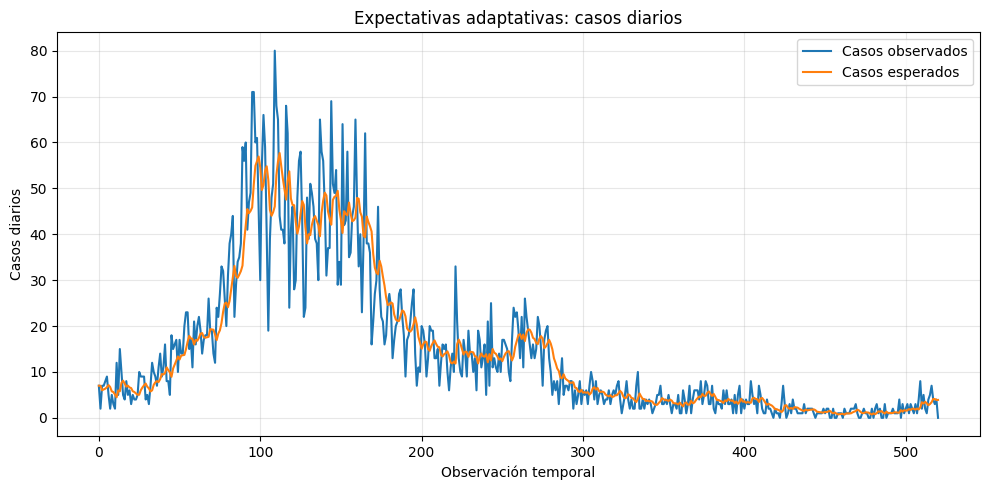

Gráfica guardada en: resultados_etapa_12\expectativas_adaptativas_casos.png


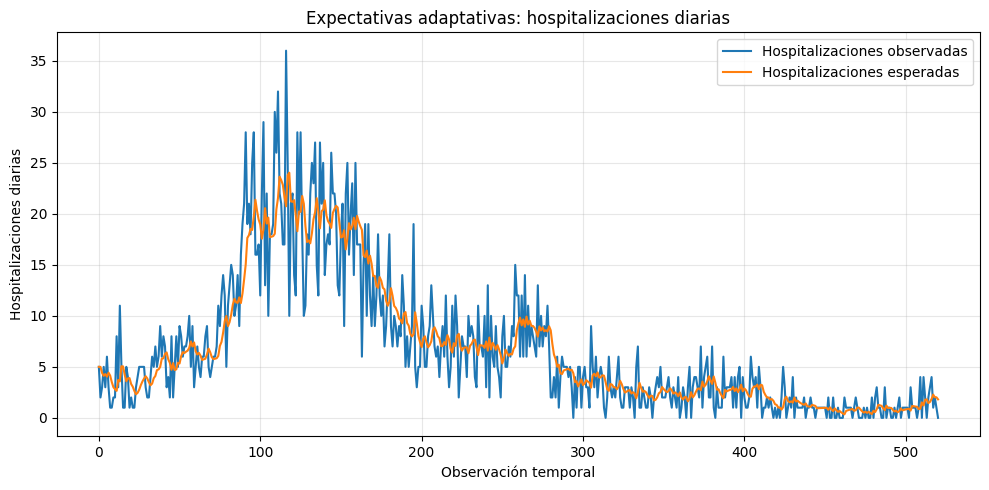

Gráfica guardada en: resultados_etapa_12\expectativas_adaptativas_hospitalizaciones.png


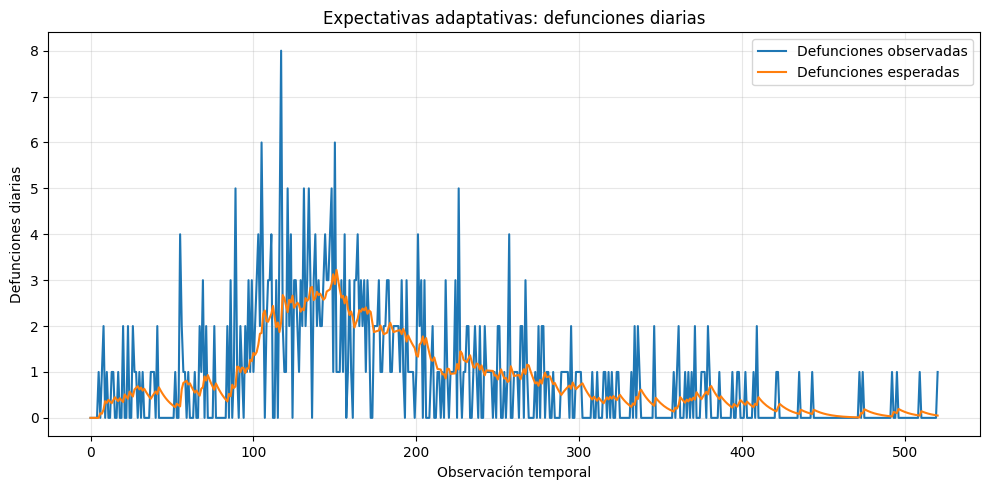

Gráfica guardada en: resultados_etapa_12\expectativas_adaptativas_defunciones.png


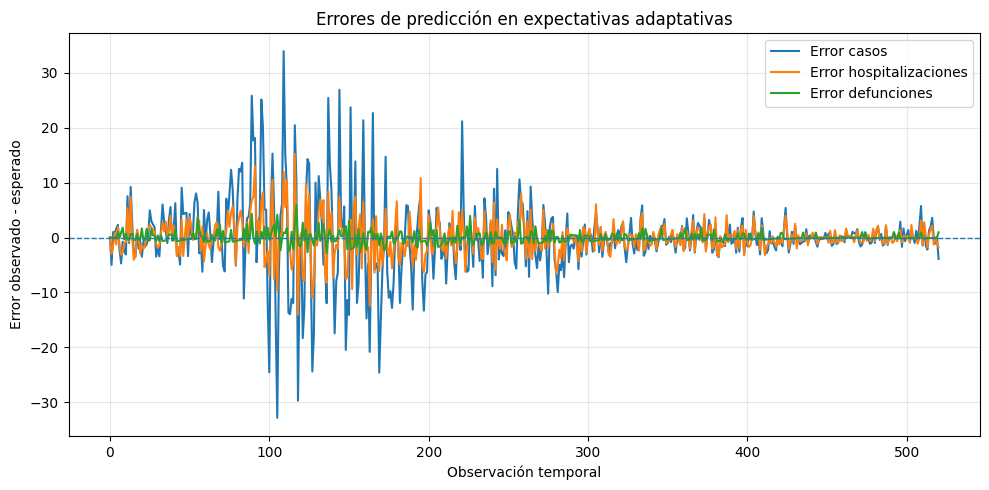

Gráfica guardada en: resultados_etapa_12\errores_expectativas_adaptativas.png


In [38]:
# ------------------------------------------------------------
# 9. Gráfica: casos observados vs esperados
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    df_expectativas_final.index,
    df_expectativas_final["casos_diarios"],
    label="Casos observados"
)

plt.plot(
    df_expectativas_final.index,
    df_expectativas_final["expectativa_casos_diarios"],
    label="Casos esperados"
)

plt.title("Expectativas adaptativas: casos diarios")
plt.xlabel("Observación temporal")
plt.ylabel("Casos diarios")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

ruta_exp_casos = OUT_DIR_12 / "expectativas_adaptativas_casos.png"
plt.savefig(ruta_exp_casos, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_exp_casos}")


# ------------------------------------------------------------
# 10. Gráfica: hospitalizaciones observadas vs esperadas
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    df_expectativas_final.index,
    df_expectativas_final["hospitalizaciones_diarias"],
    label="Hospitalizaciones observadas"
)

plt.plot(
    df_expectativas_final.index,
    df_expectativas_final["expectativa_hospitalizaciones_diarias"],
    label="Hospitalizaciones esperadas"
)

plt.title("Expectativas adaptativas: hospitalizaciones diarias")
plt.xlabel("Observación temporal")
plt.ylabel("Hospitalizaciones diarias")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

ruta_exp_hosp = OUT_DIR_12 / "expectativas_adaptativas_hospitalizaciones.png"
plt.savefig(ruta_exp_hosp, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_exp_hosp}")


# ------------------------------------------------------------
# 11. Gráfica: defunciones observadas vs esperadas
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    df_expectativas_final.index,
    df_expectativas_final["defunciones_diarias"],
    label="Defunciones observadas"
)

plt.plot(
    df_expectativas_final.index,
    df_expectativas_final["expectativa_defunciones_diarias"],
    label="Defunciones esperadas"
)

plt.title("Expectativas adaptativas: defunciones diarias")
plt.xlabel("Observación temporal")
plt.ylabel("Defunciones diarias")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

ruta_exp_def = OUT_DIR_12 / "expectativas_adaptativas_defunciones.png"
plt.savefig(ruta_exp_def, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_exp_def}")


# ------------------------------------------------------------
# 12. Gráfica de errores de predicción
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    df_expectativas_final.index,
    df_expectativas_final["error_casos_diarios"],
    label="Error casos"
)

plt.plot(
    df_expectativas_final.index,
    df_expectativas_final["error_hospitalizaciones_diarias"],
    label="Error hospitalizaciones"
)

plt.plot(
    df_expectativas_final.index,
    df_expectativas_final["error_defunciones_diarias"],
    label="Error defunciones"
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Errores de predicción en expectativas adaptativas")
plt.xlabel("Observación temporal")
plt.ylabel("Error observado - esperado")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

ruta_errores_exp = OUT_DIR_12 / "errores_expectativas_adaptativas.png"
plt.savefig(ruta_errores_exp, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_errores_exp}")

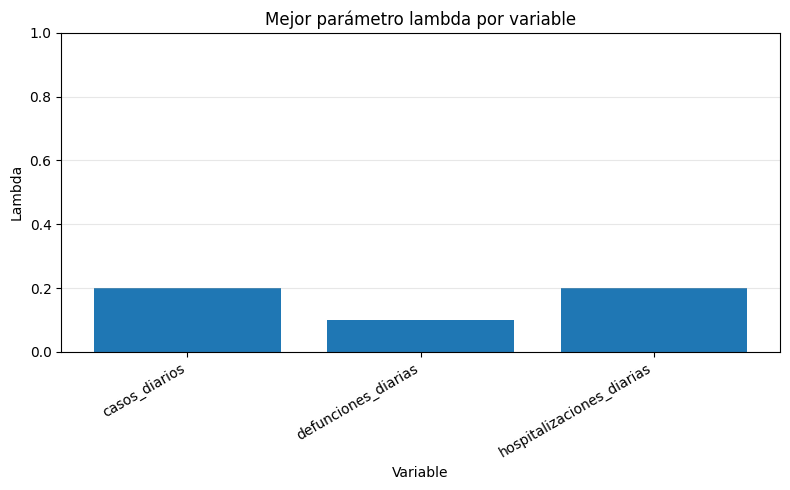

Gráfica guardada en: resultados_etapa_12\mejores_lambdas_expectativas.png
Archivo Excel guardado en: resultados_etapa_12\resultados_expectativas_adaptativas.xlsx
Resumen TXT guardado en: resultados_etapa_12\resumen_expectativas_adaptativas.txt
Resumen para el reporte
---------------------------------------------

Mejores lambdas


,variable,lambda,peso_dato_observado_anterior,peso_expectativa_pasada,MAE,RMSE,MAPE,sesgo_promedio
0,casos_diarios,0.2,0.2,0.8,4.257357,6.842990,46.220874,-0.037203
1,defunciones_diarias,0.1,0.1,0.9,0.686501,0.987048,51.802256,0.002788
2,hospitalizaciones_diarias,0.2,0.2,0.8,2.325098,3.309493,51.488877,-0.034047



Formación de expectativas


,variable,lambda,peso_expectativa_pasada,interpretacion
0,casos_diarios,0.2,0.8,"Para casos_diarios, lambda = 0.20. Esto signif..."
1,defunciones_diarias,0.1,0.9,"Para defunciones_diarias, lambda = 0.10. Esto ..."
2,hospitalizaciones_diarias,0.2,0.8,"Para hospitalizaciones_diarias, lambda = 0.20...."



Coeficientes de modelos con expectativas


,variable_modelada,variable,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup
0,casos_diarios,const,0.233889,0.416415,0.561672,5.745823e-01,-0.584178,1.051956
1,casos_diarios,expectativa_casos_diarios,0.981622,0.019570,50.160694,3.522979e-201,0.943177,1.020068
2,hospitalizaciones_diarias,const,0.142652,0.216432,0.659109,5.101179e-01,-0.282538,0.567842
3,hospitalizaciones_diarias,expectativa_hospitalizaciones_diarias,0.973859,0.023758,40.990773,7.384945e-165,0.927186,1.020533
4,defunciones_diarias,const,0.071357,0.063134,1.130257,2.588900e-01,-0.052672,0.195386
5,defunciones_diarias,expectativa_defunciones_diarias,0.918353,0.054782,16.763669,1.002259e-50,0.810731,1.025975



Métricas de modelos


,variable_modelada,observaciones,r_cuadrada,r_cuadrada_ajustada,estadistico_f,p_valor_f,aic,bic
0,casos_diarios,521,0.829000,0.828671,2516.095223,3.522979e-201,3485.634264,3494.145764
1,hospitalizaciones_diarias,521,0.764010,0.763555,1680.243441,7.384945e-165,2728.325380,2736.836880
2,defunciones_diarias,521,0.351267,0.350017,281.020589,1.002259e-50,1466.720637,1475.232137


In [39]:
# ------------------------------------------------------------
# 13. Gráfica de mejores lambdas
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    mejores_lambdas["variable"],
    mejores_lambdas["lambda"]
)

plt.ylim(0, 1)
plt.title("Mejor parámetro lambda por variable")
plt.xlabel("Variable")
plt.ylabel("Lambda")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

ruta_lambdas = OUT_DIR_12 / "mejores_lambdas_expectativas.png"
plt.savefig(ruta_lambdas, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_lambdas}")


# ------------------------------------------------------------
# 14. Guardar resultados en Excel
# ------------------------------------------------------------

ruta_excel_exp = OUT_DIR_12 / "resultados_expectativas_adaptativas.xlsx"

with pd.ExcelWriter(ruta_excel_exp, engine="openpyxl") as writer:
    resultados_lambdas.to_excel(writer, sheet_name="evaluacion_lambdas", index=False)
    mejores_lambdas.to_excel(writer, sheet_name="mejores_lambdas", index=False)
    formacion_expectativas.to_excel(writer, sheet_name="formacion_expectativas", index=False)
    tabla_coeficientes_exp.to_excel(writer, sheet_name="coeficientes_modelos", index=False)
    metricas_modelos_exp.to_excel(writer, sheet_name="metricas_modelos", index=False)
    df_expectativas_final.to_excel(writer, sheet_name="expectativas_errores", index=False)
    predicciones_exp.to_excel(writer, sheet_name="predicciones_residuos", index=False)

print(f"Archivo Excel guardado en: {ruta_excel_exp}")


# ------------------------------------------------------------
# 15. Guardar resumen en TXT
# ------------------------------------------------------------

ruta_txt_exp = OUT_DIR_12 / "resumen_expectativas_adaptativas.txt"

with open(ruta_txt_exp, "w", encoding="utf-8") as f:
    f.write("ETAPA 12. MODELO DE EXPECTATIVAS ADAPTATIVAS\n")
    f.write("=" * 70 + "\n\n")

    f.write("Fórmula utilizada:\n")
    f.write("E_t = lambda * Y_{t-1} + (1 - lambda) * E_{t-1}\n\n")

    f.write("Mejores lambdas:\n")
    f.write(mejores_lambdas.to_string(index=False))
    f.write("\n\n")

    f.write("Formación de expectativas:\n")
    f.write(formacion_expectativas[["variable", "lambda", "peso_expectativa_pasada", "interpretacion"]].to_string(index=False))
    f.write("\n\n")

    f.write("Coeficientes de modelos:\n")
    f.write(tabla_coeficientes_exp.to_string(index=False))
    f.write("\n\n")

    f.write("Métricas de modelos:\n")
    f.write(metricas_modelos_exp.to_string(index=False))
    f.write("\n\n")

    for variable in variables_expectativas:
        f.write("=" * 70 + "\n")
        f.write(f"Resumen modelo para {variable}:\n")
        f.write(str(modelos_exp[variable].summary()))
        f.write("\n\n")

print(f"Resumen TXT guardado en: {ruta_txt_exp}")


# ------------------------------------------------------------
# 16. Síntesis de resultados para el reporte
# ------------------------------------------------------------

print("Resumen para el reporte")
print("---------------------------------------------")

print("\nMejores lambdas")
display(mejores_lambdas)

print("\nFormación de expectativas")
display(formacion_expectativas[["variable", "lambda", "peso_expectativa_pasada", "interpretacion"]])

print("\nCoeficientes de modelos con expectativas")
display(tabla_coeficientes_exp)

print("\nMétricas de modelos")
display(metricas_modelos_exp)

## **ETAPA 13. SERIES DE TIEMPO**

Rango temporal:
2025-01-01 00:00:00 a 2026-06-05 00:00:00

Primeras observaciones:


,casos_diarios,hospitalizaciones_diarias,defunciones_diarias
fecha,,,
2025-01-01,7.0,5.0,0.0
2025-01-02,2.0,2.0,0.0
2025-01-03,7.0,3.0,0.0
2025-01-04,7.0,5.0,0.0
2025-01-05,8.0,3.0,0.0



Últimas observaciones:


,casos_diarios,hospitalizaciones_diarias,defunciones_diarias
fecha,,,
2026-06-01,7.0,4.0,0.0
2026-06-02,4.0,1.0,0.0
2026-06-03,3.0,2.0,0.0
2026-06-04,4.0,1.0,0.0
2026-06-05,0.0,0.0,1.0


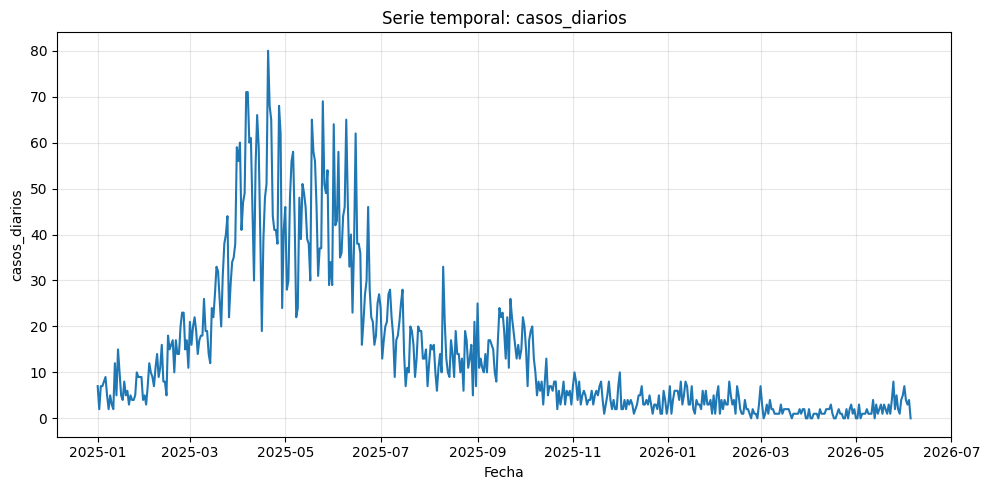

Gráfica guardada en: resultados_etapa_13\serie_temporal_casos_diarios.png


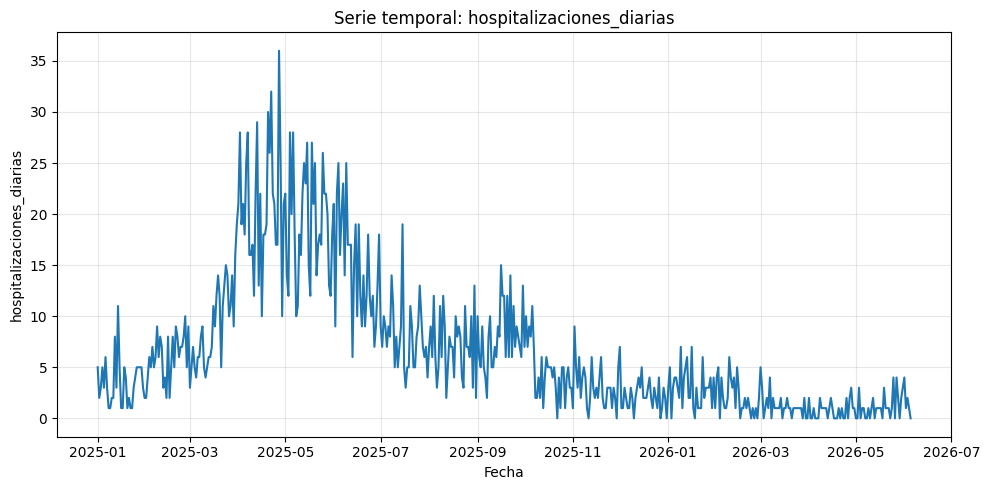

Gráfica guardada en: resultados_etapa_13\serie_temporal_hospitalizaciones_diarias.png


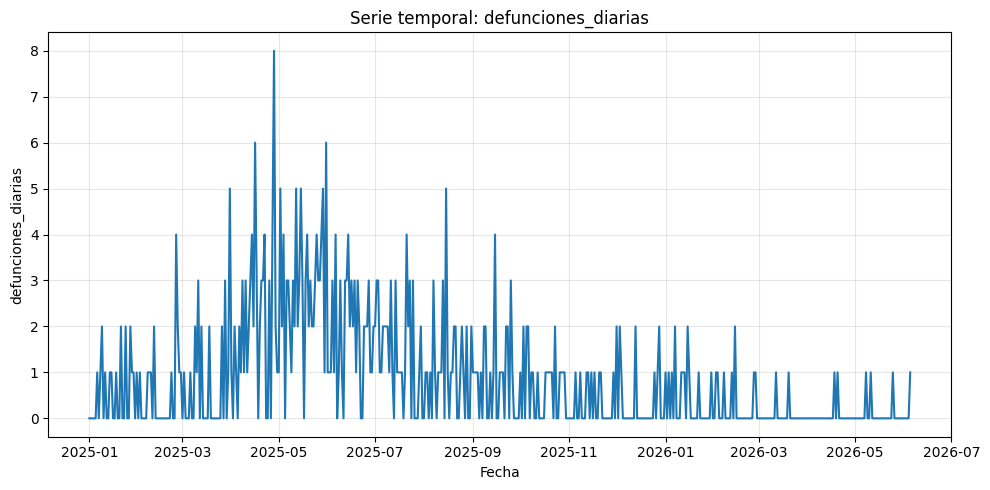

Gráfica guardada en: resultados_etapa_13\serie_temporal_defunciones_diarias.png
Prueba ADF sobre series originales


,serie,estadistico_adf,p_valor,rezagos_usados,observaciones,valor_critico_1%,valor_critico_5%,valor_critico_10%,decision_5
0,casos_diarios,-1.478098,0.544317,18,502,-3.443444,-2.867315,-2.569846,No estacionaria: no se rechaza H0
1,hospitalizaciones_diarias,-1.142149,0.697974,16,504,-3.443392,-2.867292,-2.569833,No estacionaria: no se rechaza H0
2,defunciones_diarias,-1.208672,0.669854,16,504,-3.443392,-2.867292,-2.569833,No estacionaria: no se rechaza H0


In [40]:
# ============================================================
# ETAPA 13. SERIES DE TIEMPO
# ADF, AR, MA, ARMA, ARIMA y pronósticos a 7, 14 y 30 días
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from IPython.display import display

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

# Carpeta de salida para esta etapa
OUT_DIR_13 = Path("resultados_etapa_13")
OUT_DIR_13.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 1. Preparar base temporal
# ------------------------------------------------------------

df_series = df_ts.copy()

if "fecha" in df_series.columns:
    df_series["fecha"] = pd.to_datetime(df_series["fecha"], errors="coerce")
    df_series = df_series.sort_values("fecha")
    df_series = df_series.set_index("fecha")
else:
    df_series = df_series.sort_index()

variables_series = [
    "casos_diarios",
    "hospitalizaciones_diarias",
    "defunciones_diarias"
]

for col in variables_series:
    df_series[col] = pd.to_numeric(df_series[col], errors="coerce")

# Asegurar frecuencia diaria
df_series = df_series.asfreq("D")

# Rellenar posibles huecos con 0 porque son conteos diarios
df_series[variables_series] = df_series[variables_series].fillna(0)

print("Rango temporal:")
print(df_series.index.min(), "a", df_series.index.max())

print("\nPrimeras observaciones:")
display(df_series[variables_series].head())

print("\nÚltimas observaciones:")
display(df_series[variables_series].tail())


# ------------------------------------------------------------
# 2. Gráfica de las tres series temporales
# ------------------------------------------------------------

for variable in variables_series:
    plt.figure(figsize=(10, 5))
    plt.plot(df_series.index, df_series[variable])
    plt.title(f"Serie temporal: {variable}")
    plt.xlabel("Fecha")
    plt.ylabel(variable)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    ruta = OUT_DIR_13 / f"serie_temporal_{variable}.png"
    plt.savefig(ruta, dpi=300)
    plt.show()
    
    print(f"Gráfica guardada en: {ruta}")


# ------------------------------------------------------------
# 3. Función para prueba Dickey-Fuller Aumentada
# ------------------------------------------------------------

def aplicar_adf(serie, nombre_serie):
    """
    Aplica prueba ADF.
    H0: la serie tiene raíz unitaria, es decir, no es estacionaria.
    H1: la serie es estacionaria.

    La función valida que la serie tenga suficientes observaciones y variación.
    """
    serie = pd.Series(serie).dropna()

    if len(serie) < 10 or serie.nunique() < 2:
        return {
            "serie": nombre_serie,
            "estadistico_adf": np.nan,
            "p_valor": np.nan,
            "rezagos_usados": np.nan,
            "observaciones": len(serie),
            "valor_critico_1%": np.nan,
            "valor_critico_5%": np.nan,
            "valor_critico_10%": np.nan,
            "decision_5": "No calculable: serie corta o sin variación suficiente"
        }

    try:
        resultado = adfuller(serie, autolag="AIC")

        tabla = {
            "serie": nombre_serie,
            "estadistico_adf": resultado[0],
            "p_valor": resultado[1],
            "rezagos_usados": resultado[2],
            "observaciones": resultado[3],
            "valor_critico_1%": resultado[4]["1%"],
            "valor_critico_5%": resultado[4]["5%"],
            "valor_critico_10%": resultado[4]["10%"],
            "decision_5": (
                "Estacionaria: se rechaza H0"
                if resultado[1] < 0.05
                else "No estacionaria: no se rechaza H0"
            )
        }
    except Exception as e:
        tabla = {
            "serie": nombre_serie,
            "estadistico_adf": np.nan,
            "p_valor": np.nan,
            "rezagos_usados": np.nan,
            "observaciones": len(serie),
            "valor_critico_1%": np.nan,
            "valor_critico_5%": np.nan,
            "valor_critico_10%": np.nan,
            "decision_5": f"No calculable: {e}"
        }

    return tabla


# ------------------------------------------------------------
# 4. Aplicar ADF a las series originales
# ------------------------------------------------------------

resultados_adf_original = []

for variable in variables_series:
    resultados_adf_original.append(
        aplicar_adf(df_series[variable], variable)
    )

tabla_adf_original = pd.DataFrame(resultados_adf_original)

print("Prueba ADF sobre series originales")
display(tabla_adf_original)

Prueba ADF sobre primeras diferencias


,serie,estadistico_adf,p_valor,rezagos_usados,observaciones,valor_critico_1%,valor_critico_5%,valor_critico_10%,decision_5
0,casos_diarios_diferenciada,-4.703793,8.278297e-05,17,502,-3.443444,-2.867315,-2.569846,Estacionaria: se rechaza H0
1,hospitalizaciones_diarias_diferenciada,-6.763165,2.759200e-09,15,504,-3.443392,-2.867292,-2.569833,Estacionaria: se rechaza H0
2,defunciones_diarias_diferenciada,-10.579731,6.955613e-19,15,504,-3.443392,-2.867292,-2.569833,Estacionaria: se rechaza H0


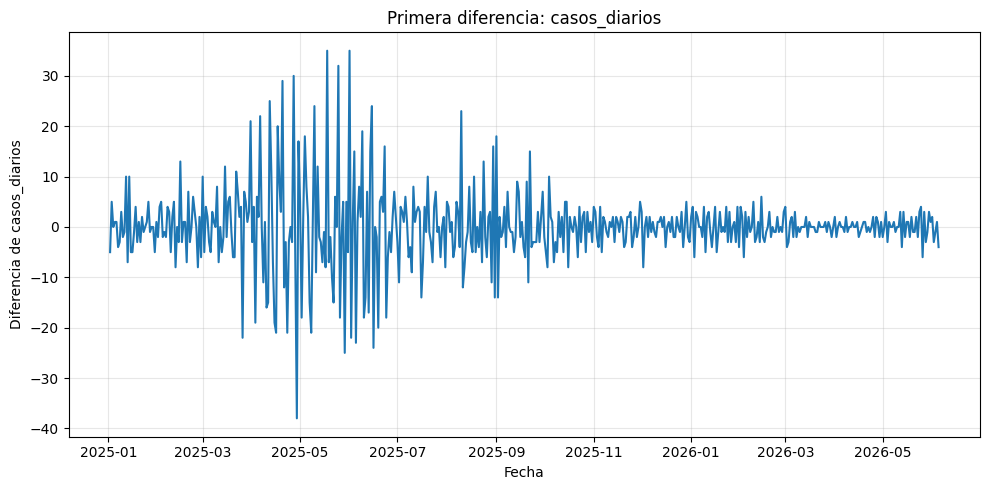

Gráfica guardada en: resultados_etapa_13\serie_diferenciada_casos_diarios.png


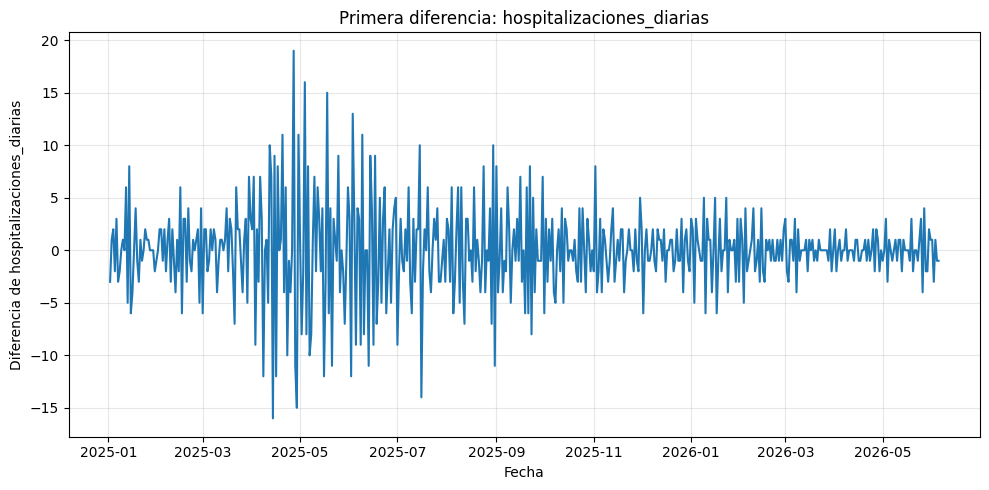

Gráfica guardada en: resultados_etapa_13\serie_diferenciada_hospitalizaciones_diarias.png


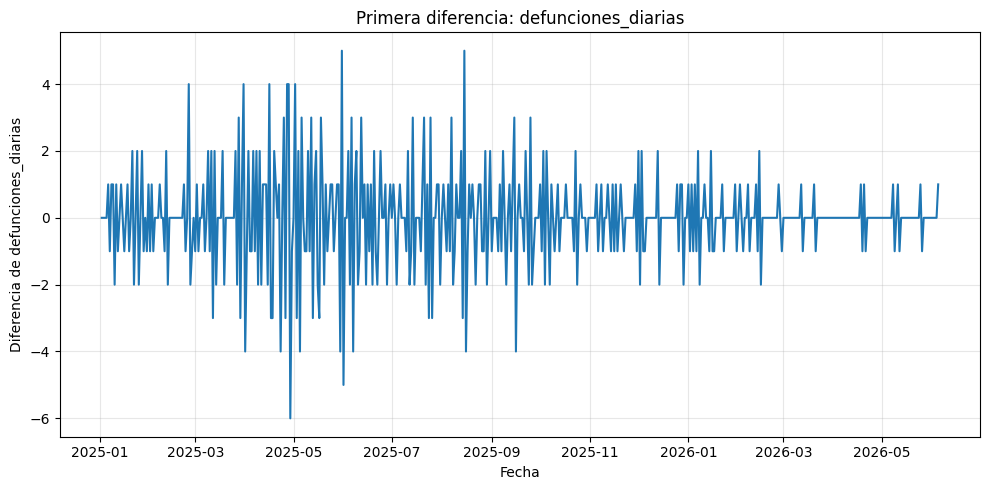

Gráfica guardada en: resultados_etapa_13\serie_diferenciada_defunciones_diarias.png
Serie objetivo: defunciones_diarias


fecha
2025-01-01    0.0
2025-01-02    0.0
2025-01-03    0.0
2025-01-04    0.0
2025-01-05    0.0
Freq: D, Name: defunciones_diarias, dtype: float64

Comparación de modelos AR, MA, ARMA y ARIMA


,modelo,orden,aic,bic,log_likelihood,convergio
0,"ARIMA(1,1,1)","(1, 1, 1)",1466.750399,1479.511885,-730.375199,True
1,"ARMA(1,1)","(1, 0, 1)",1471.391784,1488.414785,-731.695892,True
2,AR(1),"(1, 0, 0)",1619.831947,1632.599197,-806.915973,True
3,MA(1),"(0, 0, 1)",1646.179423,1658.946673,-820.089711,True


Mejor modelo según AIC:
ARIMA(1,1,1)
modelo            ARIMA(1,1,1)
orden                (1, 1, 1)
aic                1466.750399
bic                1479.511885
log_likelihood     -730.375199
convergio                 True
Name: 0, dtype: object

Resumen del mejor modelo:
                                SARIMAX Results                                
Dep. Variable:     defunciones_diarias   No. Observations:                  521
Model:                  ARIMA(1, 1, 1)   Log Likelihood                -730.375
Date:                 Wed, 17 Jun 2026   AIC                           1466.750
Time:                         22:32:07   BIC                           1479.512
Sample:                     01-01-2025   HQIC                          1471.750
                          - 06-05-2026                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------

In [41]:
# ------------------------------------------------------------
# 5. Crear primeras diferencias y aplicar ADF
# ------------------------------------------------------------

df_series_diff = df_series[variables_series].diff().dropna()

resultados_adf_diff = []

for variable in variables_series:
    resultados_adf_diff.append(
        aplicar_adf(df_series_diff[variable], f"{variable}_diferenciada")
    )

tabla_adf_diff = pd.DataFrame(resultados_adf_diff)

print("Prueba ADF sobre primeras diferencias")
display(tabla_adf_diff)


# ------------------------------------------------------------
# 6. Gráficas de series diferenciadas
# ------------------------------------------------------------

for variable in variables_series:
    plt.figure(figsize=(10, 5))
    plt.plot(df_series_diff.index, df_series_diff[variable])
    plt.title(f"Primera diferencia: {variable}")
    plt.xlabel("Fecha")
    plt.ylabel(f"Diferencia de {variable}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    ruta = OUT_DIR_13 / f"serie_diferenciada_{variable}.png"
    plt.savefig(ruta, dpi=300)
    plt.show()
    
    print(f"Gráfica guardada en: {ruta}")


# ------------------------------------------------------------
# 7. Serie principal para modelado
# ------------------------------------------------------------

serie_objetivo = "defunciones_diarias"

y = df_series[serie_objetivo].copy()
y = y.dropna()

print("Serie objetivo:", serie_objetivo)
display(y.head())


# ------------------------------------------------------------
# 8. Función para ajustar modelos ARIMA
# ------------------------------------------------------------

def ajustar_modelo_arima(serie, orden, nombre_modelo):
    """
    Ajusta un modelo ARIMA con el orden indicado.
    AR(p)      = ARIMA(p,0,0)
    MA(q)      = ARIMA(0,0,q)
    ARMA(p,q)  = ARIMA(p,0,q)
    ARIMA(p,d,q)
    """
    try:
        modelo = ARIMA(serie, order=orden).fit()
        
        resultado = {
            "modelo": nombre_modelo,
            "orden": str(orden),
            "aic": modelo.aic,
            "bic": modelo.bic,
            "log_likelihood": modelo.llf,
            "convergio": True,
            "objeto_modelo": modelo
        }
        
    except Exception as e:
        resultado = {
            "modelo": nombre_modelo,
            "orden": str(orden),
            "aic": np.nan,
            "bic": np.nan,
            "log_likelihood": np.nan,
            "convergio": False,
            "error": str(e),
            "objeto_modelo": None
        }
    
    return resultado


# ------------------------------------------------------------
# 9. Ajustar modelos requeridos
# ------------------------------------------------------------

modelos_candidatos = [
    ("AR(1)", (1, 0, 0)),
    ("MA(1)", (0, 0, 1)),
    ("ARMA(1,1)", (1, 0, 1)),
    ("ARIMA(1,1,1)", (1, 1, 1))
]

resultados_modelos = []

for nombre, orden in modelos_candidatos:
    resultados_modelos.append(
        ajustar_modelo_arima(y, orden, nombre)
    )

tabla_modelos = pd.DataFrame([
    {
        "modelo": r["modelo"],
        "orden": r["orden"],
        "aic": r["aic"],
        "bic": r["bic"],
        "log_likelihood": r["log_likelihood"],
        "convergio": r["convergio"]
    }
    for r in resultados_modelos
])

tabla_modelos = tabla_modelos.sort_values("aic").reset_index(drop=True)

print("Comparación de modelos AR, MA, ARMA y ARIMA")
display(tabla_modelos)


# ------------------------------------------------------------
# 10. Seleccionar mejor modelo por AIC
# ------------------------------------------------------------

tabla_modelos_validos = tabla_modelos.dropna(subset=["aic"]).copy()

if tabla_modelos_validos.empty:
    raise RuntimeError("Ningún modelo ARIMA pudo ajustarse correctamente. Revisa la serie y los datos de entrada.")

mejor_fila = tabla_modelos_validos.iloc[0]
mejor_nombre = mejor_fila["modelo"]

mejor_modelo = None

for r in resultados_modelos:
    if r["modelo"] == mejor_nombre:
        mejor_modelo = r["objeto_modelo"]

print("Mejor modelo según AIC:")
print(mejor_nombre)
print(mejor_fila)

print("\nResumen del mejor modelo:")
print(mejor_modelo.summary())

Coeficientes del mejor modelo


,parametro,coeficiente,error_estandar,z,p_valor,IC_95_inf,IC_95_sup
0,ar.L1,-0.072582,0.038020,-1.909060,5.625431e-02,-0.147099,0.001935
1,ma.L1,-0.906002,0.013544,-66.891121,0.000000e+00,-0.932549,-0.879455
2,sigma2,0.968204,0.033888,28.570663,1.555718e-179,0.901784,1.034623


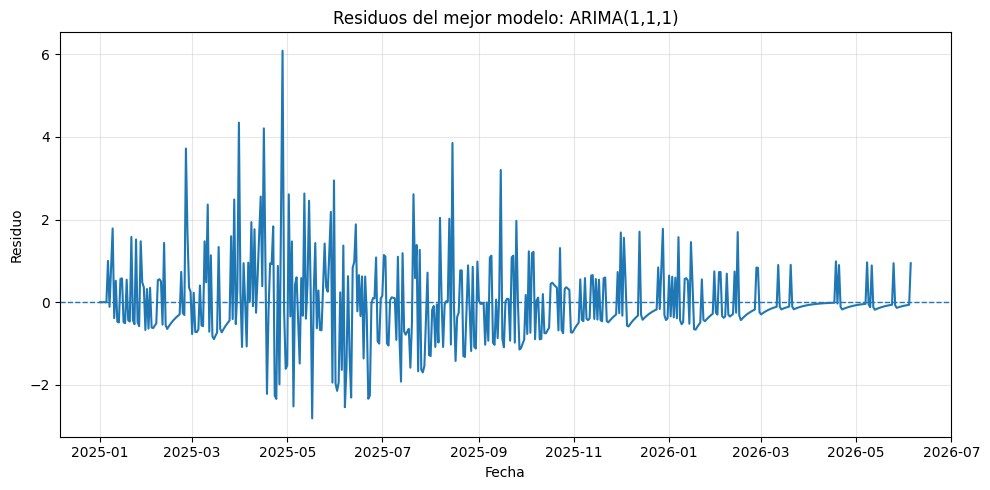

Gráfica guardada en: resultados_etapa_13\residuos_mejor_modelo_arima.png
Pronósticos generados


,fecha,horizonte,modelo,pronostico,IC_95_inf,IC_95_sup,pronostico_ajustado,IC_95_inf_ajustado
0,2026-06-06,7,"ARIMA(1,1,1)",0.072766,-1.855786,2.001319,0.072766,0.0
1,2026-06-07,7,"ARIMA(1,1,1)",0.140066,-1.788928,2.069061,0.140066,0.0
2,2026-06-08,7,"ARIMA(1,1,1)",0.135182,-1.802034,2.072397,0.135182,0.0
3,2026-06-09,7,"ARIMA(1,1,1)",0.135536,-1.808980,2.080052,0.135536,0.0
4,2026-06-10,7,"ARIMA(1,1,1)",0.135510,-1.816341,2.087362,0.135510,0.0


,fecha,horizonte,modelo,pronostico,IC_95_inf,IC_95_sup,pronostico_ajustado,IC_95_inf_ajustado
46,2026-07-01,30,"ARIMA(1,1,1)",0.135512,-1.964392,2.235416,0.135512,0.0
47,2026-07-02,30,"ARIMA(1,1,1)",0.135512,-1.971182,2.242207,0.135512,0.0
48,2026-07-03,30,"ARIMA(1,1,1)",0.135512,-1.977951,2.248975,0.135512,0.0
49,2026-07-04,30,"ARIMA(1,1,1)",0.135512,-1.984698,2.255723,0.135512,0.0
50,2026-07-05,30,"ARIMA(1,1,1)",0.135512,-1.991424,2.262448,0.135512,0.0


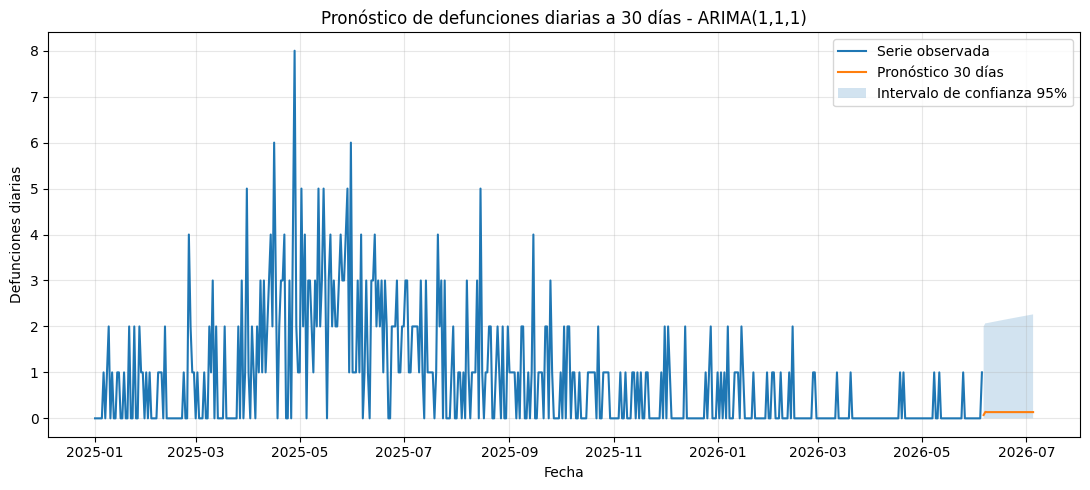

Gráfica guardada en: resultados_etapa_13\pronostico_defunciones_30_dias.png


In [42]:
# ------------------------------------------------------------
# 11. Tabla de coeficientes del mejor modelo
# ------------------------------------------------------------

tabla_coef_mejor_modelo = pd.DataFrame({
    "parametro": mejor_modelo.params.index,
    "coeficiente": mejor_modelo.params.values,
    "error_estandar": mejor_modelo.bse.values,
    "z": mejor_modelo.tvalues.values,
    "p_valor": mejor_modelo.pvalues.values,
    "IC_95_inf": mejor_modelo.conf_int().iloc[:, 0].values,
    "IC_95_sup": mejor_modelo.conf_int().iloc[:, 1].values
})

print("Coeficientes del mejor modelo")
display(tabla_coef_mejor_modelo)


# ------------------------------------------------------------
# 12. Residuos del mejor modelo
# ------------------------------------------------------------

residuos_mejor_modelo = mejor_modelo.resid

df_residuos_arima = pd.DataFrame({
    "fecha": residuos_mejor_modelo.index,
    "residuo": residuos_mejor_modelo.values
})

plt.figure(figsize=(10, 5))
plt.plot(residuos_mejor_modelo.index, residuos_mejor_modelo.values)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title(f"Residuos del mejor modelo: {mejor_nombre}")
plt.xlabel("Fecha")
plt.ylabel("Residuo")
plt.grid(alpha=0.3)
plt.tight_layout()

ruta_residuos_arima = OUT_DIR_13 / "residuos_mejor_modelo_arima.png"
plt.savefig(ruta_residuos_arima, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_residuos_arima}")


# ------------------------------------------------------------
# 13. Función para pronosticar
# ------------------------------------------------------------

def generar_pronostico(modelo, pasos, nombre_modelo):
    """
    Genera pronóstico con intervalos de confianza.
    """
    forecast_res = modelo.get_forecast(steps=pasos)
    pred_mean = forecast_res.predicted_mean
    conf_int = forecast_res.conf_int()
    
    fechas_futuras = pd.date_range(
        start=y.index.max() + pd.Timedelta(days=1),
        periods=pasos,
        freq="D"
    )
    
    pronostico = pd.DataFrame({
        "fecha": fechas_futuras,
        "horizonte": pasos,
        "modelo": nombre_modelo,
        "pronostico": pred_mean.values,
        "IC_95_inf": conf_int.iloc[:, 0].values,
        "IC_95_sup": conf_int.iloc[:, 1].values
    })
    
    # Como son conteos, evitamos pronósticos negativos en la tabla final
    pronostico["pronostico_ajustado"] = pronostico["pronostico"].clip(lower=0)
    pronostico["IC_95_inf_ajustado"] = pronostico["IC_95_inf"].clip(lower=0)
    
    return pronostico


# ------------------------------------------------------------
# 14. Generar pronósticos de 7, 14 y 30 días
# ------------------------------------------------------------

pronostico_7 = generar_pronostico(mejor_modelo, 7, mejor_nombre)
pronostico_14 = generar_pronostico(mejor_modelo, 14, mejor_nombre)
pronostico_30 = generar_pronostico(mejor_modelo, 30, mejor_nombre)

pronosticos_total = pd.concat(
    [pronostico_7, pronostico_14, pronostico_30],
    ignore_index=True
)

print("Pronósticos generados")
display(pronosticos_total.head())
display(pronosticos_total.tail())


# ------------------------------------------------------------
# 15. Gráfica de pronóstico a 30 días
# ------------------------------------------------------------

historial = y.copy()

pron_30 = pronostico_30.copy()

plt.figure(figsize=(11, 5))

plt.plot(
    historial.index,
    historial.values,
    label="Serie observada"
)

plt.plot(
    pron_30["fecha"],
    pron_30["pronostico_ajustado"],
    label="Pronóstico 30 días"
)

plt.fill_between(
    pron_30["fecha"],
    pron_30["IC_95_inf_ajustado"],
    pron_30["IC_95_sup"],
    alpha=0.2,
    label="Intervalo de confianza 95%"
)

plt.title(f"Pronóstico de defunciones diarias a 30 días - {mejor_nombre}")
plt.xlabel("Fecha")
plt.ylabel("Defunciones diarias")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

ruta_pron_30 = OUT_DIR_13 / "pronostico_defunciones_30_dias.png"
plt.savefig(ruta_pron_30, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_pron_30}")

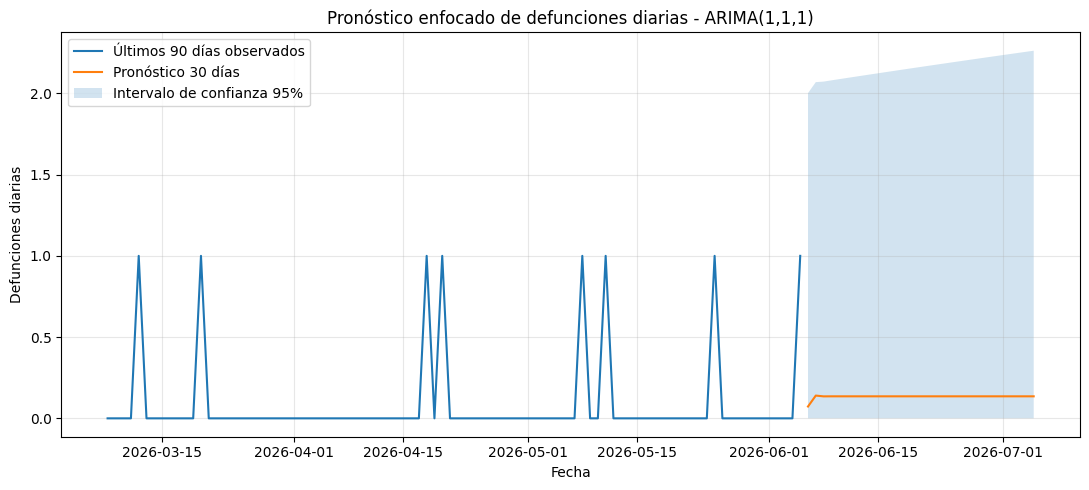

Gráfica guardada en: resultados_etapa_13\pronostico_defunciones_30_dias_zoom.png
Archivo Excel guardado en: resultados_etapa_13\resultados_series_tiempo_arima.xlsx
Resumen TXT guardado en: resultados_etapa_13\resumen_series_tiempo_arima.txt
Resumen para el reporte
---------------------------------------------

ADF series originales


,serie,estadistico_adf,p_valor,rezagos_usados,observaciones,valor_critico_1%,valor_critico_5%,valor_critico_10%,decision_5
0,casos_diarios,-1.478098,0.544317,18,502,-3.443444,-2.867315,-2.569846,No estacionaria: no se rechaza H0
1,hospitalizaciones_diarias,-1.142149,0.697974,16,504,-3.443392,-2.867292,-2.569833,No estacionaria: no se rechaza H0
2,defunciones_diarias,-1.208672,0.669854,16,504,-3.443392,-2.867292,-2.569833,No estacionaria: no se rechaza H0



ADF primeras diferencias


,serie,estadistico_adf,p_valor,rezagos_usados,observaciones,valor_critico_1%,valor_critico_5%,valor_critico_10%,decision_5
0,casos_diarios_diferenciada,-4.703793,8.278297e-05,17,502,-3.443444,-2.867315,-2.569846,Estacionaria: se rechaza H0
1,hospitalizaciones_diarias_diferenciada,-6.763165,2.759200e-09,15,504,-3.443392,-2.867292,-2.569833,Estacionaria: se rechaza H0
2,defunciones_diarias_diferenciada,-10.579731,6.955613e-19,15,504,-3.443392,-2.867292,-2.569833,Estacionaria: se rechaza H0



Comparación de modelos


...

,fecha,horizonte,modelo,pronostico,IC_95_inf,IC_95_sup,pronostico_ajustado,IC_95_inf_ajustado
0,2026-06-06,7,"ARIMA(1,1,1)",0.072766,-1.855786,2.001319,0.072766,0.0
1,2026-06-07,7,"ARIMA(1,1,1)",0.140066,-1.788928,2.069061,0.140066,0.0
2,2026-06-08,7,"ARIMA(1,1,1)",0.135182,-1.802034,2.072397,0.135182,0.0
3,2026-06-09,7,"ARIMA(1,1,1)",0.135536,-1.808980,2.080052,0.135536,0.0
4,2026-06-10,7,"ARIMA(1,1,1)",0.135510,-1.816341,2.087362,0.135510,0.0
5,2026-06-11,7,"ARIMA(1,1,1)",0.135512,-1.823643,2.094668,0.135512,0.0
6,2026-06-12,7,"ARIMA(1,1,1)",0.135512,-1.830920,2.101944,0.135512,0.0



Pronóstico a 14 días


,fecha,horizonte,modelo,pronostico,IC_95_inf,IC_95_sup,pronostico_ajustado,IC_95_inf_ajustado
0,2026-06-06,14,"ARIMA(1,1,1)",0.072766,-1.855786,2.001319,0.072766,0.0
1,2026-06-07,14,"ARIMA(1,1,1)",0.140066,-1.788928,2.069061,0.140066,0.0
2,2026-06-08,14,"ARIMA(1,1,1)",0.135182,-1.802034,2.072397,0.135182,0.0
3,2026-06-09,14,"ARIMA(1,1,1)",0.135536,-1.808980,2.080052,0.135536,0.0
4,2026-06-10,14,"ARIMA(1,1,1)",0.135510,-1.816341,2.087362,0.135510,0.0
5,2026-06-11,14,"ARIMA(1,1,1)",0.135512,-1.823643,2.094668,0.135512,0.0
6,2026-06-12,14,"ARIMA(1,1,1)",0.135512,-1.830920,2.101944,0.135512,0.0
7,2026-06-13,14,"ARIMA(1,1,1)",0.135512,-1.838170,2.109194,0.135512,0.0
8,2026-06-14,14,"ARIMA(1,1,1)",0.135512,-1.845393,2.116417,0.135512,0.0
9,2026-06-15,14,"ARIMA(1,1,1)",0.135512,-1.852590,2.123614,0.135512,0.0



Pronóstico a 30 días


,fecha,horizonte,modelo,pronostico,IC_95_inf,IC_95_sup,pronostico_ajustado,IC_95_inf_ajustado
0,2026-06-06,30,"ARIMA(1,1,1)",0.072766,-1.855786,2.001319,0.072766,0.0
1,2026-06-07,30,"ARIMA(1,1,1)",0.140066,-1.788928,2.069061,0.140066,0.0
2,2026-06-08,30,"ARIMA(1,1,1)",0.135182,-1.802034,2.072397,0.135182,0.0
3,2026-06-09,30,"ARIMA(1,1,1)",0.135536,-1.808980,2.080052,0.135536,0.0
4,2026-06-10,30,"ARIMA(1,1,1)",0.135510,-1.816341,2.087362,0.135510,0.0
5,2026-06-11,30,"ARIMA(1,1,1)",0.135512,-1.823643,2.094668,0.135512,0.0
6,2026-06-12,30,"ARIMA(1,1,1)",0.135512,-1.830920,2.101944,0.135512,0.0
7,2026-06-13,30,"ARIMA(1,1,1)",0.135512,-1.838170,2.109194,0.135512,0.0
8,2026-06-14,30,"ARIMA(1,1,1)",0.135512,-1.845393,2.116417,0.135512,0.0
9,2026-06-15,30,"ARIMA(1,1,1)",0.135512,-1.852590,2.123614,0.135512,0.0


In [43]:
# ------------------------------------------------------------
# 16. Gráfica enfocada: últimos 90 días + pronóstico
# ------------------------------------------------------------

historial_90 = historial.tail(90)

plt.figure(figsize=(11, 5))

plt.plot(
    historial_90.index,
    historial_90.values,
    label="Últimos 90 días observados"
)

plt.plot(
    pron_30["fecha"],
    pron_30["pronostico_ajustado"],
    label="Pronóstico 30 días"
)

plt.fill_between(
    pron_30["fecha"],
    pron_30["IC_95_inf_ajustado"],
    pron_30["IC_95_sup"],
    alpha=0.2,
    label="Intervalo de confianza 95%"
)

plt.title(f"Pronóstico enfocado de defunciones diarias - {mejor_nombre}")
plt.xlabel("Fecha")
plt.ylabel("Defunciones diarias")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

ruta_pron_30_zoom = OUT_DIR_13 / "pronostico_defunciones_30_dias_zoom.png"
plt.savefig(ruta_pron_30_zoom, dpi=300)
plt.show()

print(f"Gráfica guardada en: {ruta_pron_30_zoom}")


# ------------------------------------------------------------
# 17. Guardar resultados en Excel
# ------------------------------------------------------------

ruta_excel_series = OUT_DIR_13 / "resultados_series_tiempo_arima.xlsx"

with pd.ExcelWriter(ruta_excel_series, engine="openpyxl") as writer:
    df_series[variables_series].to_excel(writer, sheet_name="series_temporales")
    tabla_adf_original.to_excel(writer, sheet_name="adf_original", index=False)
    tabla_adf_diff.to_excel(writer, sheet_name="adf_diferenciada", index=False)
    tabla_modelos.to_excel(writer, sheet_name="comparacion_modelos", index=False)
    tabla_coef_mejor_modelo.to_excel(writer, sheet_name="coef_mejor_modelo", index=False)
    df_residuos_arima.to_excel(writer, sheet_name="residuos_mejor_modelo", index=False)
    pronosticos_total.to_excel(writer, sheet_name="pronosticos_7_14_30", index=False)

print(f"Archivo Excel guardado en: {ruta_excel_series}")


# ------------------------------------------------------------
# 18. Guardar resumen en TXT
# ------------------------------------------------------------

ruta_txt_series = OUT_DIR_13 / "resumen_series_tiempo_arima.txt"

with open(ruta_txt_series, "w", encoding="utf-8") as f:
    f.write("ETAPA 13. SERIES DE TIEMPO\n")
    f.write("=" * 70 + "\n\n")
    
    f.write("Series utilizadas:\n")
    f.write(", ".join(variables_series))
    f.write("\n\n")
    
    f.write("Prueba ADF - series originales:\n")
    f.write(tabla_adf_original.to_string(index=False))
    f.write("\n\n")
    
    f.write("Prueba ADF - primeras diferencias:\n")
    f.write(tabla_adf_diff.to_string(index=False))
    f.write("\n\n")
    
    f.write("Comparación AR, MA, ARMA y ARIMA:\n")
    f.write(tabla_modelos.to_string(index=False))
    f.write("\n\n")
    
    f.write(f"Mejor modelo según AIC: {mejor_nombre}\n\n")
    f.write(str(mejor_modelo.summary()))
    f.write("\n\n")
    
    f.write("Pronósticos 7, 14 y 30 días:\n")
    f.write(pronosticos_total.to_string(index=False))

print(f"Resumen TXT guardado en: {ruta_txt_series}")


# ------------------------------------------------------------
# 19. Síntesis de resultados para el reporte
# ------------------------------------------------------------

print("Resumen para el reporte")
print("---------------------------------------------")

print("\nADF series originales")
display(tabla_adf_original)

print("\nADF primeras diferencias")
display(tabla_adf_diff)

print("\nComparación de modelos")
display(tabla_modelos)

print("\nMejor modelo según AIC:")
print(mejor_nombre)

print("\nCoeficientes del mejor modelo")
display(tabla_coef_mejor_modelo)

print("\nPronóstico a 7 días")
display(pronostico_7)

print("\nPronóstico a 14 días")
display(pronostico_14)

print("\nPronóstico a 30 días")
display(pronostico_30)